# Customer Review Classification — EDA

Notebook ini digunakan untuk **Exploratory Data Analysis (EDA)** pada dataset `labeledReview.datasetFix.json`.

Target klasifikasi:
- `0` = Negatif
- `1` = Positif

> Letakkan file `labeledReview.datasetFix.json` di folder yang sama dengan notebook ini.

In [ ]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

DATA_PATH = Path('labeledReview.datasetFix.json')
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'File tidak ditemukan: {DATA_PATH.resolve()}\n'
        'Letakkan labeledReview.datasetFix.json di folder yang sama dengan notebook.'
    )

with DATA_PATH.open('r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f'Jumlah data: {len(df):,}')
print(f'Kolom: {list(df.columns)}')

Jumlah data: 11,606
Kolom: ['review', 'sentimen', 'translate']


## 1. Melihat Struktur Dataset

In [ ]:
display(df.head(10))
print('\nInformasi data:')
df.info()

,review,sentimen,translate
0,Suara dan mic puas. Hanya saya pesan yg nyala ...,0,sound and mic satisfied. I only ordered the on...
1,Good. Mudah-mudahan awet. Makasih,1,good. hopefully durable. Thanks
2,"kondisi dus robek2, tolong di perhatikan lagi",0,"the condition of the box is torn, please pay a..."
3,Kualitas produk baik. Harga terjangkau dan pen...,0,product quality is good. affordable prices and...
4,"Overall bagus, tombol berfungsi semuanya, tapi...",0,"overall is good, the buttons all work, but the..."
5,"Produk ini original, Dan kualitasnya sangat ba...",1,"This product is original, and the quality is v..."
6,kualitas sangat jelek. bocor,0,very bad quality. leaking
7,"terimakasih banyak ka ya, barang sudah diterim...",1,"Thank you very much, the goods have been well ..."
8,"Body nya lebih berat dari cm 1579, spiral nya ...",0,"the body is heavier than cm , the spiral is th..."
9,pesanan di terima tanggal 27 January 2021 teta...,0,the order was received on january but i could ...



Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11606 entries, 0 to 11605
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     11606 non-null  object
 1   sentimen   11606 non-null  int64 
 2   translate  11606 non-null  object
dtypes: int64(1), object(2)
memory usage: 272.1+ KB


## 2. Cek Missing Value

In [ ]:
missing = df.isna().sum().to_frame('missing_count')
missing['missing_percent'] = (missing['missing_count'] / len(df) * 100).round(2)
display(missing)

if missing['missing_count'].sum() == 0:
    print('Tidak ada missing value.')


,missing_count,missing_percent
review,0,0.0
sentimen,0,0.0
translate,0,0.0


Tidak ada missing value.


## 3. Distribusi Label Sentimen

,jumlah,persentase
sentimen,,
Negatif (0),5803,50.0
Positif (1),5803,50.0


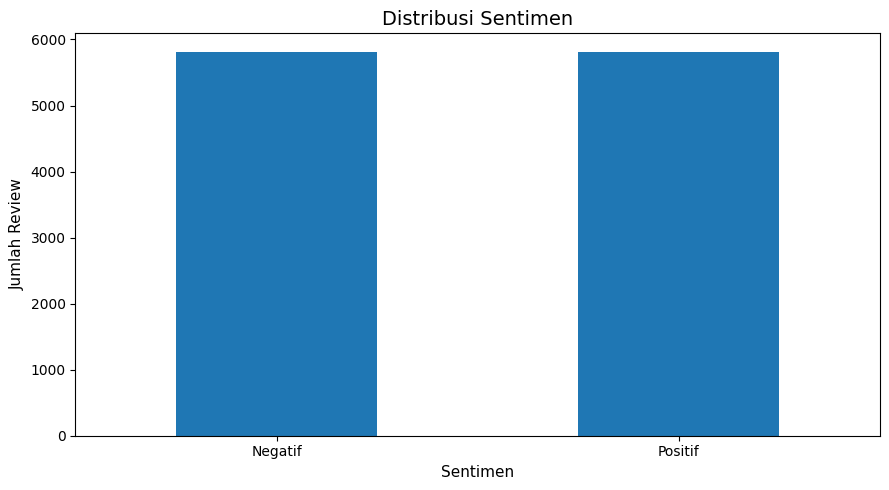

In [ ]:
label_counts = df['sentimen'].value_counts().sort_index()
label_percent = (label_counts / len(df) * 100).round(2)

label_table = pd.DataFrame({
    'jumlah': label_counts,
    'persentase': label_percent
})
label_table.index = label_table.index.map({0: 'Negatif (0)', 1: 'Positif (1)'})
display(label_table)

ax = label_counts.rename(index={0: 'Negatif', 1: 'Positif'}).plot(
    kind='bar', title='Distribusi Sentimen'
)
ax.set_xlabel('Sentimen')
ax.set_ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Cek Duplikasi

In [ ]:
duplicate_all = int(df.duplicated().sum())
duplicate_review = int(df.duplicated(subset=['review']).sum())
duplicate_review_label = int(df.duplicated(subset=['review', 'sentimen']).sum())

print(f'Duplikat seluruh kolom        : {duplicate_all}')
print(f'Duplikat berdasarkan review  : {duplicate_review}')
print(f'Duplikat review + label      : {duplicate_review_label}')

if duplicate_review > 0:
    dup_rows = df[df.duplicated(subset=['review'], keep=False)].sort_values('review')
    display(dup_rows[['review', 'sentimen']].drop_duplicates())

Duplikat seluruh kolom        : 4
Duplikat berdasarkan review  : 7
Duplikat review + label      : 7


,review,sentimen
6465,Ada garansi resmi.,1
4451,Alhamdulillah aman,1
6531,Fitur Terbaik:bagus,1
2424,pengiriman lumayan cepat,1
5884,pengiriman lumayan lama,0
1497,sesuai pesanan,1
5594,slow respon,0


## 5. Statistik Panjang Review

,count,mean,std,min,25%,50%,75%,max
char_length,11606.0,103.572032,92.148305,1.0,46.0,78.0,131.0,1668.0
word_length,11606.0,15.756591,14.412383,1.0,7.0,12.0,20.0,235.0


Review 1 kata : 108


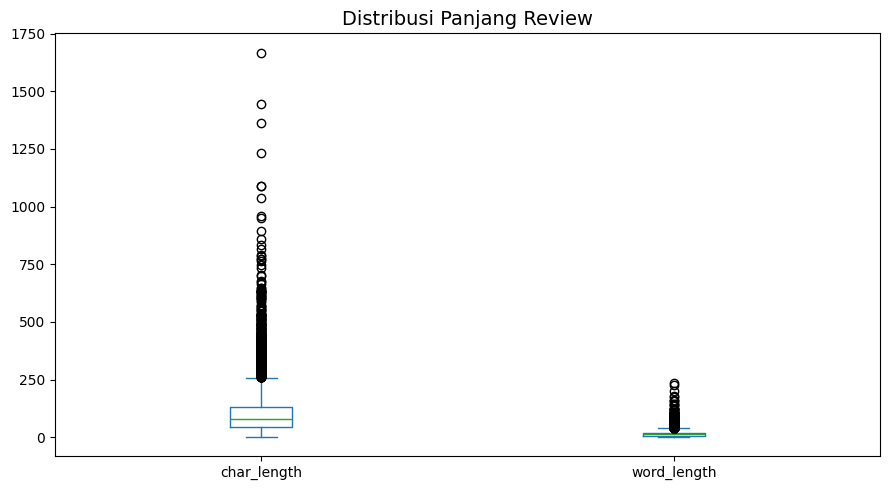

In [ ]:
df['char_length'] = df['review'].astype(str).str.len()
df['word_length'] = df['review'].astype(str).str.split().str.len()

stats = df[['char_length', 'word_length']].describe().T
display(stats)

print(f"Review 1 kata : {(df['word_length'] == 1).sum():,}")

df[['char_length', 'word_length']].plot(
    kind='box', title='Distribusi Panjang Review'
)
plt.tight_layout()
plt.show()

## 6. Pemeriksaan Kualitas Teks

In [ ]:
quality_checks = {
    'Mengandung newline': df['review'].str.contains(r'\n', regex=True, na=False).sum(),
    'Mengandung URL': df['review'].str.contains(r'https?://|www\.', regex=True, na=False).sum(),
    'Mengandung HTML entity': df['review'].str.contains(r'&(?:amp|#\d+|#x[\da-fA-F]+);', regex=True, na=False).sum(),
}

quality_table = pd.DataFrame.from_dict(quality_checks, orient='index', columns=['jumlah'])
quality_table['persentase'] = (quality_table['jumlah'] / len(df) * 100).round(2)
display(quality_table)

print('\nContoh review pendek:')
display(df.sort_values('word_length')[['review', 'sentimen']].head(15))

print('\nContoh review dengan HTML entity:')
html_rows = df[df['review'].str.contains(r'&(?:amp|#\d+|#x[\da-fA-F]+);', regex=True, na=False)]
display(html_rows[['review', 'sentimen']].head(10))

,jumlah,persentase
Mengandung newline,2197,18.93
Mengandung URL,3,0.03
Mengandung HTML entity,185,1.59



Contoh review pendek:


,review,sentimen
4493,Bedebes,0
6813,lumayan,1
5611,Mntp,0
3193,",,,,,,👍",1
11333,Muantulllll,1
5757,bestlahh👍🏻,1
5526,Joz,1
9794,Kerennnn....🤩,1
544,Mantaf,1
3900,Jlk,1



Contoh review dengan HTML entity:


,review,sentimen
17,"Daya tidak sesuai dengan deskripsi, dideskrips...",0
129,"sudah smpai, tp sayang ny kekecilan..\ntp y g&...",0
192,"pengiriman cepat, packing rapi &amp; aman",1
256,"Barang sampai dengan selamat, packing aman, ba...",0
592,barang bagus &amp; harga terjangkau. semoga awet.,1
632,"Barang sesuai pesanan, gambar &amp; deskripsi....",1
652,controller terbaca sebagai &#34;XBOX 360 For W...,1
682,Kebanyakan dari seller mengarahkan buyer untuk...,0
702,"Barang bagus... paketan lengkap dgn splitter, ...",0
733,"Respon &amp; Pengiriman cepat, smoga barangnya...",1


## 7. Contoh Review Positif dan Negatif

In [ ]:
print('Contoh review POSITIF:')
display(df[df['sentimen'] == 1][['review']].head(10))

print('Contoh review NEGATIF:')
display(df[df['sentimen'] == 0][['review']].head(10))

Contoh review POSITIF:


,review
1,Good. Mudah-mudahan awet. Makasih
5,"Produk ini original, Dan kualitasnya sangat ba..."
7,"terimakasih banyak ka ya, barang sudah diterim..."
10,sesuai gambar
14,bagus bangett!!! Sukaaa 😆❤️
16,"mantap banget sih, cuman kayaknya buat main ga..."
18,Ad sompel di dlm panciny.😥
19,"Keren dah mantap ,kirain besar ternyata kecil ..."
23,Barang original pengiriman cepat aman
25,"Barang sudah sampai, produk bagus terima kasih..."


Contoh review NEGATIF:


,review
0,Suara dan mic puas. Hanya saya pesan yg nyala ...
2,"kondisi dus robek2, tolong di perhatikan lagi"
3,Kualitas produk baik. Harga terjangkau dan pen...
4,"Overall bagus, tombol berfungsi semuanya, tapi..."
6,kualitas sangat jelek. bocor
8,"Body nya lebih berat dari cm 1579, spiral nya ..."
9,pesanan di terima tanggal 27 January 2021 teta...
11,Perlu ditingkatkan packagingnya..masak iya pak...
12,"Barang bagus, hanya sepertinya tidak di cek du..."
13,barang berfungsi dengan baik. kardus nya agak ...


## 8. Kesimpulan EDA Awal

Setelah menjalankan notebook, isi kesimpulan berdasarkan output aktual. Poin yang perlu dicatat:

1. Struktur kolom dataset.
2. Jumlah data dan distribusi label.
3. Ada/tidaknya missing value.
4. Jumlah data duplikat.
5. Karakteristik panjang review.
6. Masalah kualitas teks yang perlu ditangani pada preprocessing.

### Tahap berikutnya

Setelah EDA selesai, kita lanjut ke **text preprocessing**, kemudian **TF-IDF**, pembagian data train/test, training model klasifikasi, dan evaluasi.

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'labeledReview.datasetFix.json', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_json("/content/labeledReview.datasetFix.json")

print("Jumlah data :", len(df))
print("Kolom       :", list(df.columns))

display(df.head())

Jumlah data : 11606
Kolom       : ['review', 'sentimen', 'translate']


,review,sentimen,translate
0,Suara dan mic puas. Hanya saya pesan yg nyala ...,0,sound and mic satisfied. I only ordered the on...
1,Good. Mudah-mudahan awet. Makasih,1,good. hopefully durable. Thanks
2,"kondisi dus robek2, tolong di perhatikan lagi",0,"the condition of the box is torn, please pay a..."
3,Kualitas produk baik. Harga terjangkau dan pen...,0,product quality is good. affordable prices and...
4,"Overall bagus, tombol berfungsi semuanya, tapi...",0,"overall is good, the buttons all work, but the..."


In [ ]:
# ==========================================
# Langkah 1: Menyiapkan data preprocessing
# ==========================================

# Membuat salinan dataset
df_prep = df[['review', 'sentimen']].copy()

# Jumlah data sebelum hapus duplikat
before = len(df_prep)

# Menghapus duplikat berdasarkan review + sentimen
df_prep = df_prep.drop_duplicates(
    subset=['review', 'sentimen']
)

# Jumlah data setelah hapus duplikat
after = len(df_prep)

print("=== HASIL PERSIAPAN DATA ===")
print(f"Data sebelum hapus duplikat : {before}")
print(f"Data setelah hapus duplikat : {after}")
print(f"Data yang dihapus           : {before - after}")

display(df_prep.head())

=== HASIL PERSIAPAN DATA ===
Data sebelum hapus duplikat : 11606
Data setelah hapus duplikat : 11599
Data yang dihapus           : 7


,review,sentimen
0,Suara dan mic puas. Hanya saya pesan yg nyala ...,0
1,Good. Mudah-mudahan awet. Makasih,1
2,"kondisi dus robek2, tolong di perhatikan lagi",0
3,Kualitas produk baik. Harga terjangkau dan pen...,0
4,"Overall bagus, tombol berfungsi semuanya, tapi...",0


In [ ]:
# ==========================================
# Langkah 2: Cleaning teks dasar
# ==========================================

import re
import html

def clean_basic(text):
    # Pastikan teks berupa string
    text = str(text)

    # 1. Mengubah HTML entity menjadi karakter normal
    # Contoh: &amp; -> &
    #         &#34; -> "
    text = html.unescape(text)

    # 2. Mengubah semua huruf menjadi lowercase
    text = text.lower()

    # 3. Menghapus URL
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 4. Mengubah newline, tab, dan carriage return menjadi spasi
    text = re.sub(r'[\r\n\t]+', ' ', text)

    # 5. Merapikan spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Terapkan cleaning ke kolom review
df_prep['clean_basic'] = df_prep['review'].apply(clean_basic)

# Tampilkan hasil sebelum dan sesudah cleaning
print("=== HASIL CLEANING TEKS DASAR ===")

display(
    df_prep[['review', 'clean_basic', 'sentimen']].head(10)
)

=== HASIL CLEANING TEKS DASAR ===


,review,clean_basic,sentimen
0,Suara dan mic puas. Hanya saya pesan yg nyala ...,suara dan mic puas. hanya saya pesan yg nyala ...,0
1,Good. Mudah-mudahan awet. Makasih,good. mudah-mudahan awet. makasih,1
2,"kondisi dus robek2, tolong di perhatikan lagi","kondisi dus robek2, tolong di perhatikan lagi",0
3,Kualitas produk baik. Harga terjangkau dan pen...,kualitas produk baik. harga terjangkau dan pen...,0
4,"Overall bagus, tombol berfungsi semuanya, tapi...","overall bagus, tombol berfungsi semuanya, tapi...",0
5,"Produk ini original, Dan kualitasnya sangat ba...","produk ini original, dan kualitasnya sangat ba...",1
6,kualitas sangat jelek. bocor,kualitas sangat jelek. bocor,0
7,"terimakasih banyak ka ya, barang sudah diterim...","terimakasih banyak ka ya, barang sudah diterim...",1
8,"Body nya lebih berat dari cm 1579, spiral nya ...","body nya lebih berat dari cm 1579, spiral nya ...",0
9,pesanan di terima tanggal 27 January 2021 teta...,pesanan di terima tanggal 27 january 2021 teta...,0


In [ ]:
# ==========================================
# Langkah 3: Normalisasi kata informal
# ==========================================

import re

# Kamus normalisasi kata/istilah informal
normalization_dict = {
    "gaada": "tidak ada",
    "gada": "tidak ada",
    "gabisa": "tidak bisa",

    "nggak": "tidak",
    "ngga": "tidak",
    "gak": "tidak",
    "gk": "tidak",
    "ga": "tidak",

    "udh": "sudah",
    "udah": "sudah",
    "uda": "sudah",

    "blm": "belum",

    "krn": "karena",
    "karna": "karena",

    "dgn": "dengan",
    "dr": "dari",

    "yg": "yang",

    "sm": "sama",
    "sma": "sama",

    "tp": "tapi",
    "tpi": "tapi",

    "bgt": "banget",
    "bangettt": "banget",

    "aja": "saja",

    "klo": "kalau",
    "kalo": "kalau",

    "pke": "pakai",
    "pake": "pakai",

    "smp": "sampai",
    "sampe": "sampai",

    "dpt": "dapat",
    "dapet": "dapat",

    "trs": "terus",
    "trus": "terus",

    "thx": "terima kasih",
    "thanks": "terima kasih",
    "makasih": "terima kasih",
    "mksh": "terima kasih",

    "sis": "kak",
    "bro": "kak",

    "ty": "terima kasih",
}


def normalize_text(text):
    text = str(text)

    # Urutkan berdasarkan panjang kata
    # agar bentuk yang lebih panjang diproses terlebih dahulu
    sorted_words = sorted(
        normalization_dict.keys(),
        key=len,
        reverse=True
    )

    for word in sorted_words:
        replacement = normalization_dict[word]

        # Hanya mengganti kata utuh
        pattern = r'(?<!\w)' + re.escape(word) + r'(?!\w)'
        text = re.sub(pattern, replacement, text)

    return text


# Terapkan normalisasi
df_prep['clean_norm'] = df_prep['clean_basic'].apply(normalize_text)


print("=== HASIL NORMALISASI ===")

display(
    df_prep[
        ['review', 'clean_basic', 'clean_norm', 'sentimen']
    ].head(10)
)

=== HASIL NORMALISASI ===


,review,clean_basic,clean_norm,sentimen
0,Suara dan mic puas. Hanya saya pesan yg nyala ...,suara dan mic puas. hanya saya pesan yg nyala ...,suara dan mic puas. hanya saya pesan yang nyal...,0
1,Good. Mudah-mudahan awet. Makasih,good. mudah-mudahan awet. makasih,good. mudah-mudahan awet. terima kasih,1
2,"kondisi dus robek2, tolong di perhatikan lagi","kondisi dus robek2, tolong di perhatikan lagi","kondisi dus robek2, tolong di perhatikan lagi",0
3,Kualitas produk baik. Harga terjangkau dan pen...,kualitas produk baik. harga terjangkau dan pen...,kualitas produk baik. harga terjangkau dan pen...,0
4,"Overall bagus, tombol berfungsi semuanya, tapi...","overall bagus, tombol berfungsi semuanya, tapi...","overall bagus, tombol berfungsi semuanya, tapi...",0
5,"Produk ini original, Dan kualitasnya sangat ba...","produk ini original, dan kualitasnya sangat ba...","produk ini original, dan kualitasnya sangat ba...",1
6,kualitas sangat jelek. bocor,kualitas sangat jelek. bocor,kualitas sangat jelek. bocor,0
7,"terimakasih banyak ka ya, barang sudah diterim...","terimakasih banyak ka ya, barang sudah diterim...","terimakasih banyak ka ya, barang sudah diterim...",1
8,"Body nya lebih berat dari cm 1579, spiral nya ...","body nya lebih berat dari cm 1579, spiral nya ...","body nya lebih berat dari cm 1579, spiral nya ...",0
9,pesanan di terima tanggal 27 January 2021 teta...,pesanan di terima tanggal 27 january 2021 teta...,pesanan di terima tanggal 27 january 2021 teta...,0


In [ ]:
# ==========================================
# Langkah 3: Normalisasi kata informal
# Versi diperbaiki
# ==========================================

import re

# Kamus normalisasi
normalization_dict = {
    # Bentuk "tidak"
    "gaada": "tidak ada",
    "gada": "tidak ada",
    "gabisa": "tidak bisa",
    "nggak": "tidak",
    "ngga": "tidak",
    "gak": "tidak",
    "gk": "tidak",
    "ga": "tidak",

    # Bentuk "sudah"
    "udh": "sudah",
    "udah": "sudah",
    "uda": "sudah",

    # Bentuk "belum"
    "blm": "belum",

    # Kata umum
    "yg": "yang",
    "sy": "saya",
    "lg": "lagi",

    # Kata penghubung
    "krn": "karena",
    "karna": "karena",
    "dgn": "dengan",
    "dr": "dari",
    "sm": "sama",
    "sma": "sama",
    "tp": "tapi",
    "tpi": "tapi",

    # Bentuk informal
    "bgt": "banget",
    "bangettt": "banget",
    "klo": "kalau",
    "kalo": "kalau",
    "aja": "saja",
    "pke": "pakai",
    "pake": "pakai",
    "smp": "sampai",
    "sampe": "sampai",
    "dpt": "dapat",
    "dapet": "dapat",
    "trs": "terus",
    "trus": "terus",

    # Terima kasih
    "thx": "terima kasih",
    "thanks": "terima kasih",
    "makasih": "terima kasih",
    "mksh": "terima kasih",
    "terimakasih": "terima kasih",
    "ty": "terima kasih",

    # Sapaan
    "sis": "kak",
    "bro": "kak",

    # Typo umum yang terlihat pada dataset
    "cepet": "cepat",
    "sanagt": "sangat",
}


def normalize_text(text):
    text = str(text)

    # Proses kata yang lebih panjang terlebih dahulu
    sorted_words = sorted(
        normalization_dict.keys(),
        key=len,
        reverse=True
    )

    for word in sorted_words:
        replacement = normalization_dict[word]

        # Mengganti hanya kata yang berdiri sendiri
        pattern = r'(?<!\w)' + re.escape(word) + r'(?!\w)'
        text = re.sub(pattern, replacement, text)

    return text


# Terapkan normalisasi ulang
df_prep['clean_norm'] = df_prep['clean_basic'].apply(normalize_text)


print("=== HASIL NORMALISASI ===")

display(
    df_prep[
        ['review', 'clean_basic', 'clean_norm', 'sentimen']
    ].head(10)
)

=== HASIL NORMALISASI ===


,review,clean_basic,clean_norm,sentimen
0,Suara dan mic puas. Hanya saya pesan yg nyala ...,suara dan mic puas. hanya saya pesan yg nyala ...,suara dan mic puas. hanya saya pesan yang nyal...,0
1,Good. Mudah-mudahan awet. Makasih,good. mudah-mudahan awet. makasih,good. mudah-mudahan awet. terima kasih,1
2,"kondisi dus robek2, tolong di perhatikan lagi","kondisi dus robek2, tolong di perhatikan lagi","kondisi dus robek2, tolong di perhatikan lagi",0
3,Kualitas produk baik. Harga terjangkau dan pen...,kualitas produk baik. harga terjangkau dan pen...,kualitas produk baik. harga terjangkau dan pen...,0
4,"Overall bagus, tombol berfungsi semuanya, tapi...","overall bagus, tombol berfungsi semuanya, tapi...","overall bagus, tombol berfungsi semuanya, tapi...",0
5,"Produk ini original, Dan kualitasnya sangat ba...","produk ini original, dan kualitasnya sangat ba...","produk ini original, dan kualitasnya sangat ba...",1
6,kualitas sangat jelek. bocor,kualitas sangat jelek. bocor,kualitas sangat jelek. bocor,0
7,"terimakasih banyak ka ya, barang sudah diterim...","terimakasih banyak ka ya, barang sudah diterim...","terima kasih banyak ka ya, barang sudah diteri...",1
8,"Body nya lebih berat dari cm 1579, spiral nya ...","body nya lebih berat dari cm 1579, spiral nya ...","body nya lebih berat dari cm 1579, spiral nya ...",0
9,pesanan di terima tanggal 27 January 2021 teta...,pesanan di terima tanggal 27 january 2021 teta...,pesanan di terima tanggal 27 january 2021 teta...,0


In [ ]:
# ==========================================
# Langkah 4: Tokenisasi dan Stopword Removal
# ==========================================

# Install library Sastrawi jika belum tersedia
!pip -q install Sastrawi

import re

from Sastrawi.StopWordRemover.StopWordRemoverFactory import (
    StopWordRemoverFactory
)

# Membuat daftar stopword Bahasa Indonesia
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

# Kata negasi penting untuk sentimen
# Jangan sampai ikut dihapus
important_words = {
    "tidak",
    "bukan",
    "belum",
    "jangan",
    "kurang",
}

stopwords = stopwords - important_words


def tokenize_text(text):
    """
    Memecah teks menjadi token berdasarkan spasi.
    Tanda baca dasar dipisahkan dari kata.
    """
    text = str(text)

    # Memisahkan tanda baca dari kata
    text = re.sub(r'([.,!?;:()])', r' \1 ', text)

    # Memecah berdasarkan spasi
    tokens = text.split()

    return tokens


def remove_stopwords(tokens):
    """
    Menghapus stopword, tetapi tetap mempertahankan
    kata-kata penting untuk negasi/sentimen.
    """
    filtered_tokens = [
        token
        for token in tokens
        if token not in stopwords
    ]

    return filtered_tokens


# 1. Tokenisasi
df_prep['tokens'] = df_prep['clean_norm'].apply(tokenize_text)

# 2. Stopword removal
df_prep['tokens_no_stopword'] = df_prep['tokens'].apply(
    remove_stopwords
)

# 3. Gabungkan kembali token menjadi teks
df_prep['clean_no_stopword'] = (
    df_prep['tokens_no_stopword']
    .apply(lambda tokens: ' '.join(tokens))
)


print("=== HASIL TOKENISASI DAN STOPWORD REMOVAL ===")

display(
    df_prep[
        [
            'clean_norm',
            'tokens',
            'tokens_no_stopword',
            'clean_no_stopword',
            'sentimen'
        ]
    ].head(10)
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.1 MB/s eta 0:00:00
=== HASIL TOKENISASI DAN STOPWORD REMOVAL ===


,clean_norm,tokens,tokens_no_stopword,clean_no_stopword,sentimen
0,suara dan mic puas. hanya saya pesan yang nyal...,"[suara, dan, mic, puas, ., hanya, saya, pesan,...","[suara, mic, puas, ., pesan, nyala, sy, pastik...",suara mic puas . pesan nyala sy pastikan lg kl...,0
1,good. mudah-mudahan awet. terima kasih,"[good, ., mudah-mudahan, awet, ., terima, kasih]","[good, ., mudah-mudahan, awet, ., terima, kasih]",good . mudah-mudahan awet . terima kasih,1
2,"kondisi dus robek2, tolong di perhatikan lagi","[kondisi, dus, robek2, ,, tolong, di, perhatik...","[kondisi, dus, robek2, ,, perhatikan]","kondisi dus robek2 , perhatikan",0
3,kualitas produk baik. harga terjangkau dan pen...,"[kualitas, produk, baik, ., harga, terjangkau,...","[kualitas, produk, baik, ., harga, terjangkau,...",kualitas produk baik . harga terjangkau pengir...,0
4,"overall bagus, tombol berfungsi semuanya, tapi...","[overall, bagus, ,, tombol, berfungsi, semuany...","[overall, bagus, ,, tombol, berfungsi, semuany...","overall bagus , tombol berfungsi semuanya , pa...",0
5,"produk ini original, dan kualitasnya sangat ba...","[produk, ini, original, ,, dan, kualitasnya, s...","[produk, original, ,, kualitasnya, sangat, bai...","produk original , kualitasnya sangat baik . ke...",1
6,kualitas sangat jelek. bocor,"[kualitas, sangat, jelek, ., bocor]","[kualitas, sangat, jelek, ., bocor]",kualitas sangat jelek . bocor,0
7,"terimakasih banyak ka ya, barang sudah diterim...","[terimakasih, banyak, ka, ya, ,, barang, sudah...","[terimakasih, banyak, ka, ,, barang, diterima,...","terimakasih banyak ka , barang diterima baik ....",1
8,"body nya lebih berat dari cm 1579, spiral nya ...","[body, nya, lebih, berat, dari, cm, 1579, ,, s...","[body, nya, lebih, berat, cm, 1579, ,, spiral,...","body nya lebih berat cm 1579 , spiral nya lebi...",0
9,pesanan di terima tanggal 27 january 2021 teta...,"[pesanan, di, terima, tanggal, 27, january, 20...","[pesanan, terima, tanggal, 27, january, 2021, ...",pesanan terima tanggal 27 january 2021 baru bu...,0


In [ ]:
# ==========================================
# Langkah 5: Stemming Bahasa Indonesia
# Versi lebih cepat
# ==========================================

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from functools import lru_cache
import re

# Membuat stemmer Bahasa Indonesia
factory = StemmerFactory()
stemmer = factory.create_stemmer()


@lru_cache(maxsize=50000)
def stem_word(word):
    """
    Stemming satu kata dan menyimpan hasilnya di cache.
    Kata yang sama tidak perlu diproses berulang kali.
    """

    # Jangan stemming angka
    if re.fullmatch(r'\d+([.,]\d+)?', word):
        return word

    # Jangan stemming tanda baca
    if not re.search(r'[a-zA-ZÀ-ÿ]', word):
        return word

    return stemmer.stem(word)


def stem_tokens(tokens):
    """
    Melakukan stemming pada setiap token.
    """
    return [stem_word(token) for token in tokens]


print("Mulai proses stemming...")

# Terapkan stemming
df_prep['tokens_stemmed'] = df_prep['tokens_no_stopword'].apply(
    stem_tokens
)

# Gabungkan kembali menjadi teks
df_prep['clean_stemmed'] = (
    df_prep['tokens_stemmed']
    .apply(lambda tokens: ' '.join(tokens))
)

print("=== HASIL STEMMING ===")

display(
    df_prep[
        [
            'clean_no_stopword',
            'clean_stemmed',
            'sentimen'
        ]
    ].head(10)
)

print(f"\nJumlah kata unik yang di-stemming: {stem_word.cache_info().currsize}")

Mulai proses stemming...
=== HASIL STEMMING ===


,clean_no_stopword,clean_stemmed,sentimen
0,suara mic puas . pesan nyala sy pastikan lg kl...,suara mic puas . pesan nyala sy pasti lg klik ...,0
1,good . mudah-mudahan awet . terima kasih,good . mudah awet . terima kasih,1
2,"kondisi dus robek2 , perhatikan","kondisi dus robek2 , perhati",0
3,kualitas produk baik . harga terjangkau pengir...,kualitas produk baik . harga jangkau kirim cep...,0
4,"overall bagus , tombol berfungsi semuanya , pa...","overall bagus , tombol fungsi semua , packagin...",0
5,"produk original , kualitasnya sangat baik . ke...","produk original , kualitas sangat baik . cepat...",1
6,kualitas sangat jelek . bocor,kualitas sangat jelek . bocor,0
7,"terimakasih banyak ka , barang diterima baik ....","terimakasih banyak ka , barang terima baik . s...",1
8,"body nya lebih berat cm 1579 , spiral nya lebi...","body nya lebih berat cm 1579 , spiral nya lebi...",0
9,pesanan terima tanggal 27 january 2021 baru bu...,pesan terima tanggal 27 january 2021 baru buka...,0



Jumlah kata unik yang di-stemming: 14614


In [ ]:
# ==========================================
# Langkah 6: Pemeriksaan akhir preprocessing
# ==========================================

# Menghapus tanda baca/simbol yang tersisa
# tetapi tetap mempertahankan huruf, angka, dan spasi
df_prep['clean_final'] = (
    df_prep['clean_stemmed']
    .str.replace(r'[^a-zA-Z0-9\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Mengecek teks kosong
empty_count = (
    df_prep['clean_final']
    .eq('')
    .sum()
)

print("=== PEMERIKSAAN AKHIR PREPROCESSING ===")
print(f"Jumlah data             : {len(df_prep)}")
print(f"Teks kosong             : {empty_count}")

# Cek distribusi label setelah preprocessing
print("\n=== DISTRIBUSI LABEL ===")
print(df_prep['sentimen'].value_counts().sort_index())

# Tampilkan beberapa contoh hasil akhir
print("\n=== CONTOH HASIL AKHIR ===")

display(
    df_prep[
        ['review', 'clean_final', 'sentimen']
    ].head(10)
)

=== PEMERIKSAAN AKHIR PREPROCESSING ===
Jumlah data             : 11599
Teks kosong             : 5

=== DISTRIBUSI LABEL ===
sentimen
0    5801
1    5798
Name: count, dtype: int64

=== CONTOH HASIL AKHIR ===


,review,clean_final,sentimen
0,Suara dan mic puas. Hanya saya pesan yg nyala ...,suara mic puas pesan nyala pasti klik nyala da...,0
1,Good. Mudah-mudahan awet. Makasih,good mudah awet terima kasih,1
2,"kondisi dus robek2, tolong di perhatikan lagi",kondisi dus robek2 perhati,0
3,Kualitas produk baik. Harga terjangkau dan pen...,kualitas produk baik harga jangkau kirim cepat...,0
4,"Overall bagus, tombol berfungsi semuanya, tapi...",overall bagus tombol fungsi semua packaging ku...,0
5,"Produk ini original, Dan kualitasnya sangat ba...",produk original kualitas sangat baik cepat kir...,1
6,kualitas sangat jelek. bocor,kualitas sangat jelek bocor,0
7,"terimakasih banyak ka ya, barang sudah diterim...",terima kasih banyak ka barang terima baik suks...,1
8,"Body nya lebih berat dari cm 1579, spiral nya ...",body nya lebih berat cm 1579 spiral nya lebih ...,0
9,pesanan di terima tanggal 27 January 2021 teta...,pesan terima tanggal 27 january 2021 baru buka...,0


In [ ]:
# ==========================================
# Cek 5 review yang menjadi kosong
# ==========================================

empty_reviews = df_prep[df_prep['clean_final'] == ''].copy()

print("=== REVIEW YANG MENJADI KOSONG ===")
print(f"Jumlah: {len(empty_reviews)}")

display(
    empty_reviews[
        [
            'review',
            'clean_basic',
            'clean_norm',
            'clean_stemmed',
            'clean_final',
            'sentimen'
        ]
    ]
)


=== REVIEW YANG MENJADI KOSONG ===
Jumlah: 5


,review,clean_basic,clean_norm,clean_stemmed,clean_final,sentimen
3193,",,,,,,👍",",,,,,,👍",",,,,,,👍",", , , , , , 👍",,1
3404,\,\,\,\,,1
5085,😍🖒😍🖒😍🖒😍🖒🖒😍🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒😍🖒🖒🖒😍🖒...,😍🖒😍🖒😍🖒😍🖒🖒😍🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒😍🖒🖒🖒😍🖒...,😍🖒😍🖒😍🖒😍🖒🖒😍🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒😍🖒🖒🖒😍🖒...,😍🖒😍🖒😍🖒😍🖒🖒😍🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒😍🖒🖒🖒😍🖒...,,1
6272,ok,ok,ok,,,1
7648,ok ok ok ok ok ok ok ok ok,ok ok ok ok ok ok ok ok ok,ok ok ok ok ok ok ok ok ok,,,1


In [ ]:
# ==========================================
# Perbaikan hasil stemming untuk kata "ok"
# ==========================================

# Jika review hasil normalisasi hanya berisi kata "ok",
# pertahankan kata tersebut agar tidak menjadi kosong.
df_prep.loc[
    df_prep['clean_norm'].str.fullmatch(r'(ok\s*)+'),
    'clean_stemmed'
] = df_prep.loc[
    df_prep['clean_norm'].str.fullmatch(r'(ok\s*)+'),
    'clean_norm'
]

# Buat ulang clean_final
df_prep['clean_final'] = (
    df_prep['clean_stemmed']
    .str.replace(r'[^a-zA-Z0-9\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

print("=== PEMERIKSAAN ULANG ===")

empty_count = (
    df_prep['clean_final']
    .eq('')
    .sum()
)

print(f"Jumlah data : {len(df_prep)}")
print(f"Teks kosong : {empty_count}")

print("\n=== DATA YANG MASIH KOSONG ===")

display(
    df_prep[df_prep['clean_final'] == ''][
        ['review', 'clean_stemmed', 'clean_final', 'sentimen']
    ]
)

=== PEMERIKSAAN ULANG ===
Jumlah data : 11599
Teks kosong : 3

=== DATA YANG MASIH KOSONG ===


,review,clean_stemmed,clean_final,sentimen
3193,",,,,,,👍",", , , , , , 👍",,1
3404,\,\,,1
5085,😍🖒😍🖒😍🖒😍🖒🖒😍🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒😍🖒🖒🖒😍🖒...,😍🖒😍🖒😍🖒😍🖒🖒😍🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒🖒😍🖒😍🖒😍🖒🖒🖒😍🖒...,,1


In [ ]:
# ==========================================
# Langkah 7: Membentuk dataset final
# ==========================================

# Buang review yang menjadi kosong setelah preprocessing
df_final = df_prep[df_prep['clean_final'] != ''].copy()

# Reset index agar rapi
df_final = df_final.reset_index(drop=True)

print("=== DATASET FINAL ===")
print(f"Jumlah data final : {len(df_final)}")

print("\n=== DISTRIBUSI LABEL ===")
print(df_final['sentimen'].value_counts().sort_index())

print("\n=== CEK TEKS KOSONG ===")
print(
    "Teks kosong :",
    df_final['clean_final'].eq('').sum()
)

print("\n=== CONTOH DATA FINAL ===")

display(
    df_final[
        ['review', 'clean_final', 'sentimen']
    ].head(10)
)

=== DATASET FINAL ===
Jumlah data final : 11596

=== DISTRIBUSI LABEL ===
sentimen
0    5801
1    5795
Name: count, dtype: int64

=== CEK TEKS KOSONG ===
Teks kosong : 0

=== CONTOH DATA FINAL ===


,review,clean_final,sentimen
0,Suara dan mic puas. Hanya saya pesan yg nyala ...,suara mic puas pesan nyala pasti klik nyala da...,0
1,Good. Mudah-mudahan awet. Makasih,good mudah awet terima kasih,1
2,"kondisi dus robek2, tolong di perhatikan lagi",kondisi dus robek2 perhati,0
3,Kualitas produk baik. Harga terjangkau dan pen...,kualitas produk baik harga jangkau kirim cepat...,0
4,"Overall bagus, tombol berfungsi semuanya, tapi...",overall bagus tombol fungsi semua packaging ku...,0
5,"Produk ini original, Dan kualitasnya sangat ba...",produk original kualitas sangat baik cepat kir...,1
6,kualitas sangat jelek. bocor,kualitas sangat jelek bocor,0
7,"terimakasih banyak ka ya, barang sudah diterim...",terima kasih banyak ka barang terima baik suks...,1
8,"Body nya lebih berat dari cm 1579, spiral nya ...",body nya lebih berat cm 1579 spiral nya lebih ...,0
9,pesanan di terima tanggal 27 January 2021 teta...,pesan terima tanggal 27 january 2021 baru buka...,0


In [ ]:
# ==========================================
# Langkah 8: Pembagian Data Train dan Test
# ==========================================

from sklearn.model_selection import train_test_split

# Fitur berupa teks hasil preprocessing
X = df['clean_text']

# Target / label sentimen
y = df['sentimen']

# Membagi data:
# 80% untuk training
# 20% untuk testing
# stratify=y menjaga proporsi label tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=== PEMBAGIAN DATA TRAIN DAN TEST ===")
print(f"Total data : {len(df)}")
print(f"Data train : {len(X_train)}")
print(f"Data test  : {len(X_test)}")

print("\n=== DISTRIBUSI LABEL DATA TRAIN ===")
print(y_train.value_counts().sort_index())

print("\n=== DISTRIBUSI LABEL DATA TEST ===")
print(y_test.value_counts().sort_index())

KeyError: 'clean_text'

In [ ]:
# ==========================================
# Langkah berikutnya: Cleaning Final
# ==========================================

import re

def final_clean(text):
    # Hanya mempertahankan huruf, angka, dan spasi
    text = re.sub(r'[^a-z0-9\s]', ' ', str(text))

    # Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Terapkan ke hasil stemming
df_prep['clean_final'] = df_prep['clean_stemmed'].apply(final_clean)

# Hapus review yang menjadi kosong
before_final = len(df_prep)

df_prep = df_prep[
    df_prep['clean_final'].str.strip().ne('')
].reset_index(drop=True)

removed_empty = before_final - len(df_prep)


print("=== HASIL CLEANING FINAL ===")
print(f"Data sebelum cleaning final : {before_final:,}")
print(f"Data setelah cleaning final : {len(df_prep):,}")
print(f"Review kosong yang dihapus  : {removed_empty:,}")

display(
    df_prep[
        ['clean_stemmed', 'clean_final', 'sentimen']
    ].head(10)
)

=== HASIL CLEANING FINAL ===
Data sebelum cleaning final : 11,599
Data setelah cleaning final : 11,594
Review kosong yang dihapus  : 5


,clean_stemmed,clean_final,sentimen
0,suara mic puas . pesan nyala sy pasti lg klik ...,suara mic puas pesan nyala sy pasti lg klik ny...,0
1,good . mudah awet . terima kasih,good mudah awet terima kasih,1
2,"kondisi dus robek2 , perhati",kondisi dus robek2 perhati,0
3,kualitas produk baik . harga jangkau kirim cep...,kualitas produk baik harga jangkau kirim cepet...,0
4,"overall bagus , tombol fungsi semua , packagin...",overall bagus tombol fungsi semua packaging ku...,0
5,"produk original , kualitas sangat baik . cepat...",produk original kualitas sangat baik cepat kir...,1
6,kualitas sangat jelek . bocor,kualitas sangat jelek bocor,0
7,"terimakasih banyak ka , barang terima baik . s...",terimakasih banyak ka barang terima baik sukse...,1
8,"body nya lebih berat cm 1579 , spiral nya lebi...",body nya lebih berat cm 1579 spiral nya lebih ...,0
9,pesan terima tanggal 27 january 2021 baru buka...,pesan terima tanggal 27 january 2021 baru buka...,0


In [ ]:
# ==========================================
# Langkah berikutnya: Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

# Fitur: teks hasil preprocessing final
X = df_prep['clean_final']

# Target: label sentimen
y = df_prep['sentimen']

# Split 80% train dan 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=== PEMBAGIAN DATA ===")
print(f"Total data : {len(df_prep):,}")
print(f"Data train : {len(X_train):,}")
print(f"Data test  : {len(X_test):,}")

print("\n=== LABEL TRAIN ===")
print(y_train.value_counts().sort_index())

print("\n=== LABEL TEST ===")
print(y_test.value_counts().sort_index())

=== PEMBAGIAN DATA ===
Total data : 11,594
Data train : 9,275
Data test  : 2,319

=== LABEL TRAIN ===
sentimen
0    4641
1    4634
Name: count, dtype: int64

=== LABEL TEST ===
sentimen
0    1160
1    1159
Name: count, dtype: int64


In [ ]:
# ============================================================
# BASELINE BARU
# TF-IDF + Logistic Regression C=5.0
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. TF-IDF
# ------------------------------------------------------------

vectorizer_baseline = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit HANYA pada data training
X_train_tfidf = vectorizer_baseline.fit_transform(X_train)

# Data test hanya transform
X_test_tfidf = vectorizer_baseline.transform(X_test)


print("=== HASIL TF-IDF ===")
print(f"Jumlah fitur : {X_train_tfidf.shape[1]:,}")
print(f"Train shape  : {X_train_tfidf.shape}")
print(f"Test shape   : {X_test_tfidf.shape}")


# ------------------------------------------------------------
# 2. Logistic Regression C=5.0
# ------------------------------------------------------------

model_baseline = LogisticRegression(
    C=5.0,
    max_iter=1000,
    random_state=42
)

model_baseline.fit(
    X_train_tfidf,
    y_train
)


# ------------------------------------------------------------
# 3. Prediksi
# ------------------------------------------------------------

y_pred_baseline = model_baseline.predict(
    X_test_tfidf
)


# ------------------------------------------------------------
# 4. Evaluasi
# ------------------------------------------------------------

accuracy_baseline = accuracy_score(
    y_test,
    y_pred_baseline
)

print("\n=== BASELINE BARU ===")
print(
    f"Accuracy : {accuracy_baseline:.4f} "
    f"({accuracy_baseline * 100:.2f}%)"
)

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred_baseline,
        target_names=["Negatif", "Positif"]
    )
)

print("\n=== CONFUSION MATRIX ===")
print(
    confusion_matrix(
        y_test,
        y_pred_baseline
    )
)

=== HASIL TF-IDF ===
Jumlah fitur : 14,098
Train shape  : (9275, 14098)
Test shape   : (2319, 14098)

=== BASELINE BARU ===
Accuracy : 0.8961 (89.61%)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Negatif       0.89      0.90      0.90      1160
     Positif       0.90      0.89      0.90      1159

    accuracy                           0.90      2319
   macro avg       0.90      0.90      0.90      2319
weighted avg       0.90      0.90      0.90      2319


=== CONFUSION MATRIX ===
[[1047  113]
 [ 128 1031]]


In [ ]:
# ============================================================
# EKSPERIMEN 1
# Optimasi TF-IDF menggunakan Validation Set
# ============================================================

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. Buat Validation Set dari Data Training
# ============================================================

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("=== PEMBAGIAN DATA TRAIN / VALIDATION ===")
print(f"Training   : {len(X_train_sub):,}")
print(f"Validation : {len(X_val):,}")


# ============================================================
# 2. Konfigurasi TF-IDF
# ============================================================

tfidf_configs = [
    {
        "name": "Unigram (1,1)",
        "ngram_range": (1, 1)
    },
    {
        "name": "Unigram + Bigram (1,2)",
        "ngram_range": (1, 2)
    },
    {
        "name": "Unigram + Bigram + Trigram (1,3)",
        "ngram_range": (1, 3)
    }
]


results = []


# ============================================================
# 3. Eksperimen
# ============================================================

for config in tfidf_configs:

    print("\n" + "=" * 60)
    print(f"Menguji: {config['name']}")

    vectorizer = TfidfVectorizer(
        lowercase=False,
        ngram_range=config["ngram_range"],
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )

    # FIT hanya pada training subset
    X_train_sub_tfidf = vectorizer.fit_transform(X_train_sub)

    # Validation hanya transform
    X_val_tfidf = vectorizer.transform(X_val)

    print(
        f"Jumlah fitur: "
        f"{X_train_sub_tfidf.shape[1]:,}"
    )

    # Logistic Regression
    model = LogisticRegression(
        C=5.0,
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_train_sub_tfidf,
        y_train_sub
    )

    # Prediksi validation
    y_val_pred = model.predict(
        X_val_tfidf
    )

    # Evaluasi
    accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    macro_f1 = f1_score(
        y_val,
        y_val_pred,
        average="macro"
    )

    print(
        f"Accuracy : {accuracy:.4f} "
        f"({accuracy * 100:.2f}%)"
    )

    print(
        f"Macro F1 : {macro_f1:.4f} "
        f"({macro_f1 * 100:.2f}%)"
    )

    results.append({
        "TF-IDF": config["name"],
        "Features": X_train_sub_tfidf.shape[1],
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })


# ============================================================
# 4. Tabel Hasil
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print("\n")
print("=" * 60)
print("HASIL EKSPERIMEN 1")
print("=" * 60)

display(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ============================================================
# 5. Konfigurasi Terbaik
# ============================================================

best_result = results_df.iloc[0]

print("\n=== TF-IDF TERBAIK ===")
print(f"Konfigurasi : {best_result['TF-IDF']}")
print(f"Features    : {best_result['Features']:,}")
print(f"Accuracy    : {best_result['Accuracy']:.2%}")
print(f"Macro F1    : {best_result['Macro F1']:.2%}")

=== PEMBAGIAN DATA TRAIN / VALIDATION ===
Training   : 7,420
Validation : 1,855

Menguji: Unigram (1,1)
Jumlah fitur: 3,317
Accuracy : 0.8841 (88.41%)
Macro F1 : 0.8841 (88.41%)

Menguji: Unigram + Bigram (1,2)
Jumlah fitur: 11,619
Accuracy : 0.8960 (89.60%)
Macro F1 : 0.8960 (89.60%)

Menguji: Unigram + Bigram + Trigram (1,3)
Jumlah fitur: 15,551
Accuracy : 0.8960 (89.60%)
Macro F1 : 0.8960 (89.60%)


HASIL EKSPERIMEN 1


,TF-IDF,Features,Accuracy,Macro F1
0,"Unigram + Bigram (1,2)",11619,89.60%,89.60%
1,"Unigram + Bigram + Trigram (1,3)",15551,89.60%,89.60%
2,"Unigram (1,1)",3317,88.41%,88.41%



=== TF-IDF TERBAIK ===
Konfigurasi : Unigram + Bigram (1,2)
Features    : 11,619
Accuracy    : 89.60%
Macro F1    : 89.60%


In [ ]:
# ==========================================
# Langkah 9: TF-IDF
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Membuat TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit HANYA pada data train
X_train_tfidf = tfidf.fit_transform(X_train)

# Data test hanya ditransform
X_test_tfidf = tfidf.transform(X_test)

print("=== HASIL TF-IDF ===")
print(f"Jumlah data train : {X_train_tfidf.shape[0]}")
print(f"Jumlah fitur      : {X_train_tfidf.shape[1]}")
print(f"Jumlah data test  : {X_test_tfidf.shape[0]}")

print("\n=== CONTOH FITUR TF-IDF ===")
print(tfidf.get_feature_names_out()[:20])

print("\n=== UKURAN MATRIKS ===")
print("X_train_tfidf :", X_train_tfidf.shape)
print("X_test_tfidf  :", X_test_tfidf.shape)

=== HASIL TF-IDF ===
Jumlah data train : 9276
Jumlah fitur      : 14007
Jumlah data test  : 2320

=== CONTOH FITUR TF-IDF ===
['00' '000' '000 an' '04' '06' '10' '10 10' '10 hari' '10 inch' '10 jam'
 '10 pagi' '10 tahun' '10 tidak' '100' '100 ori' '10hari' '10hr' '10rb'
 '11' '11 11']

=== UKURAN MATRIKS ===
X_train_tfidf : (9276, 14007)
X_test_tfidf  : (2320, 14007)


In [ ]:
# ==========================================
# Langkah 10: Training Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression

# Membuat model
model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Training model menggunakan data train
model_lr.fit(X_train_tfidf, y_train)

print("=== TRAINING SELESAI ===")
print("Model : Logistic Regression")
print("Data training :", X_train_tfidf.shape)

=== TRAINING SELESAI ===
Model : Logistic Regression
Data training : (9276, 14007)


In [ ]:
# ==========================================
# Langkah 11: Evaluasi Logistic Regression
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Prediksi data test
y_pred_lr = model_lr.predict(X_test_tfidf)

# Hitung accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("=== HASIL EVALUASI LOGISTIC REGRESSION ===")
print(f"Accuracy : {accuracy_lr:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Negatif', 'Positif'],
        digits=4
    )
)

print("=== CONFUSION MATRIX ===")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

=== HASIL EVALUASI LOGISTIC REGRESSION ===
Accuracy : 0.8862

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Negatif     0.8679    0.9113    0.8891      1161
     Positif     0.9064    0.8611    0.8832      1159

    accuracy                         0.8862      2320
   macro avg     0.8872    0.8862    0.8861      2320
weighted avg     0.8872    0.8862    0.8861      2320

=== CONFUSION MATRIX ===
[[1058  103]
 [ 161  998]]


In [ ]:
# ==========================================
# Langkah 12: Training Multinomial Naive Bayes
# ==========================================

from sklearn.naive_bayes import MultinomialNB

# Membuat model
model_nb = MultinomialNB()

# Training menggunakan data TF-IDF
model_nb.fit(X_train_tfidf, y_train)

print("=== TRAINING SELESAI ===")
print("Model : Multinomial Naive Bayes")
print("Data training :", X_train_tfidf.shape)

=== TRAINING SELESAI ===
Model : Multinomial Naive Bayes
Data training : (9276, 14007)


In [ ]:
# ==========================================
# Langkah 13: Evaluasi Multinomial Naive Bayes
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Prediksi data test
y_pred_nb = model_nb.predict(X_test_tfidf)

# Hitung accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("=== HASIL EVALUASI MULTINOMIAL NAIVE BAYES ===")
print(f"Accuracy : {accuracy_nb:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=['Negatif', 'Positif'],
        digits=4
    )
)

print("=== CONFUSION MATRIX ===")
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(cm_nb)

=== HASIL EVALUASI MULTINOMIAL NAIVE BAYES ===
Accuracy : 0.8772

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Negatif     0.8662    0.8923    0.8791      1161
     Positif     0.8888    0.8619    0.8752      1159

    accuracy                         0.8772      2320
   macro avg     0.8775    0.8771    0.8771      2320
weighted avg     0.8775    0.8772    0.8771      2320

=== CONFUSION MATRIX ===
[[1036  125]
 [ 160  999]]


In [ ]:
# ==========================================
# Langkah 14: Perbandingan Model
# ==========================================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Multinomial Naive Bayes'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_nb
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb)
    ]
})

# Ubah ke persen agar lebih mudah dibaca
comparison_percent = comparison.copy()

for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    comparison_percent[col] = (
        comparison_percent[col] * 100
    ).round(2)

print("=== PERBANDINGAN MODEL ===")
display(comparison_percent)

=== PERBANDINGAN MODEL ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,88.62,90.64,86.11,88.32
1,Multinomial Naive Bayes,87.72,88.88,86.19,87.52


In [ ]:
# ==========================================
# Langkah 15: Training Linear SVM
# ==========================================

from sklearn.svm import LinearSVC

# Membuat model Linear SVM
model_svm = LinearSVC(
    C=1.0,
    random_state=42
)

# Training menggunakan data TF-IDF
model_svm.fit(X_train_tfidf, y_train)

print("=== TRAINING SELESAI ===")
print("Model : Linear SVM")
print("Data training :", X_train_tfidf.shape)

=== TRAINING SELESAI ===
Model : Linear SVM
Data training : (9276, 14007)


In [ ]:
# ==========================================
# Langkah 16: Evaluasi Linear SVM
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Prediksi data test
y_pred_svm = model_svm.predict(X_test_tfidf)

# Hitung accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("=== HASIL EVALUASI LINEAR SVM ===")
print(f"Accuracy : {accuracy_svm:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=['Negatif', 'Positif'],
        digits=4
    )
)

print("=== CONFUSION MATRIX ===")
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

=== HASIL EVALUASI LINEAR SVM ===
Accuracy : 0.8853

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Negatif     0.8764    0.8975    0.8868      1161
     Positif     0.8948    0.8732    0.8838      1159

    accuracy                         0.8853      2320
   macro avg     0.8856    0.8853    0.8853      2320
weighted avg     0.8856    0.8853    0.8853      2320

=== CONFUSION MATRIX ===
[[1042  119]
 [ 147 1012]]


In [ ]:
# ==========================================
# Langkah 17: Perbandingan 3 Model
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

# Fungsi untuk membuat ringkasan evaluasi
def evaluate_model(name, y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        output_dict=True
    )

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro Precision': report['macro avg']['precision'],
        'Macro Recall': report['macro avg']['recall'],
        'Macro F1': report['macro avg']['f1-score'],
    }


# Buat tabel perbandingan
model_comparison = pd.DataFrame([
    evaluate_model(
        'Logistic Regression',
        y_test,
        y_pred_lr
    ),
    evaluate_model(
        'Multinomial Naive Bayes',
        y_test,
        y_pred_nb
    ),
    evaluate_model(
        'Linear SVM',
        y_test,
        y_pred_svm
    )
])

# Ubah ke persen
metric_columns = [
    'Accuracy',
    'Macro Precision',
    'Macro Recall',
    'Macro F1'
]

model_comparison_percent = model_comparison.copy()

for col in metric_columns:
    model_comparison_percent[col] = (
        model_comparison_percent[col] * 100
    ).round(2)

# Urutkan berdasarkan Macro F1
model_comparison_percent = (
    model_comparison_percent
    .sort_values('Macro F1', ascending=False)
    .reset_index(drop=True)
)

print("=== PERBANDINGAN 3 MODEL ===")
display(model_comparison_percent)

=== PERBANDINGAN 3 MODEL ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,88.62,88.72,88.62,88.61
1,Linear SVM,88.53,88.56,88.53,88.53
2,Multinomial Naive Bayes,87.72,87.75,87.71,87.71


In [ ]:
# ==========================================
# Langkah 18: Tuning Logistic Regression
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Membagi data TRAIN menjadi:
# 80% training
# 20% validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_tfidf,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Nilai C yang akan diuji
c_values = [0.1, 0.5, 1.0, 2.0, 5.0]

results = []

print("=== PROSES TUNING LOGISTIC REGRESSION ===")

for c in c_values:

    # Membuat model
    model = LogisticRegression(
        C=c,
        max_iter=1000,
        random_state=42
    )

    # Training
    model.fit(X_train_sub, y_train_sub)

    # Prediksi validation
    y_val_pred = model.predict(X_val)

    # Hitung metrik
    accuracy = accuracy_score(y_val, y_val_pred)
    macro_f1 = f1_score(
        y_val,
        y_val_pred,
        average='macro'
    )

    results.append({
        'C': c,
        'Accuracy': accuracy,
        'Macro F1': macro_f1
    })

# Buat tabel hasil
tuning_results = pd.DataFrame(results)

# Ubah ke persen
tuning_results['Accuracy'] = (
    tuning_results['Accuracy'] * 100
).round(2)

tuning_results['Macro F1'] = (
    tuning_results['Macro F1'] * 100
).round(2)

print("\n=== HASIL TUNING ===")
display(tuning_results)

# Cari C terbaik berdasarkan Macro F1
best_index = tuning_results['Macro F1'].idxmax()
best_c = tuning_results.loc[best_index, 'C']

print(f"\nC terbaik berdasarkan Macro F1: {best_c}")

=== PROSES TUNING LOGISTIC REGRESSION ===

=== HASIL TUNING ===


,C,Accuracy,Macro F1
0,0.1,85.83,85.82
1,0.5,87.23,87.23
2,1.0,88.15,88.15
3,2.0,88.63,88.63
4,5.0,89.60,89.60



C terbaik berdasarkan Macro F1: 5.0


In [ ]:
# ==========================================
# Langkah 19: Training Model Terbaik
# ==========================================

from sklearn.linear_model import LogisticRegression

# Membuat model dengan parameter terbaik
best_model = LogisticRegression(
    C=5.0,
    max_iter=1000,
    random_state=42
)

# Training menggunakan SELURUH data training
best_model.fit(X_train_tfidf, y_train)

print("=== MODEL TERBAIK BERHASIL DILATIH ===")
print("Model              : Logistic Regression")
print("C                  : 5.0")
print("Jumlah data train  :", X_train_tfidf.shape[0])
print("Jumlah fitur TF-IDF:", X_train_tfidf.shape[1])

=== MODEL TERBAIK BERHASIL DILATIH ===
Model              : Logistic Regression
C                  : 5.0
Jumlah data train  : 9276
Jumlah fitur TF-IDF: 14007


In [ ]:
# ==========================================
# Langkah 20: Evaluasi Final Model
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Prediksi data test
y_pred_best = best_model.predict(X_test_tfidf)

# Accuracy
accuracy_best = accuracy_score(
    y_test,
    y_pred_best
)

print("=== HASIL EVALUASI FINAL ===")
print("Model              : Logistic Regression")
print("C                  : 5.0")
print(f"Accuracy           : {accuracy_best:.4f}")

print("\n=== CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=['Negatif', 'Positif'],
        digits=4
    )
)

print("=== CONFUSION MATRIX ===")

cm_best = confusion_matrix(
    y_test,
    y_pred_best
)

print(cm_best)

=== HASIL EVALUASI FINAL ===
Model              : Logistic Regression
C                  : 5.0
Accuracy           : 0.8905

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Negatif     0.8789    0.9061    0.8923      1161
     Positif     0.9029    0.8749    0.8887      1159

    accuracy                         0.8905      2320
   macro avg     0.8909    0.8905    0.8905      2320
weighted avg     0.8909    0.8905    0.8905      2320

=== CONFUSION MATRIX ===
[[1052  109]
 [ 145 1014]]


In [ ]:
# ==========================================
# Langkah 21: Ringkasan Hasil Eksperimen
# ==========================================

import pandas as pd

final_results = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Parameter': 'C=1.0',
        'Accuracy': accuracy_lr,
        'Macro F1': 0.8861
    },
    {
        'Model': 'Multinomial Naive Bayes',
        'Parameter': 'Default',
        'Accuracy': accuracy_nb,
        'Macro F1': 0.8771
    },
    {
        'Model': 'Linear SVM',
        'Parameter': 'C=1.0',
        'Accuracy': accuracy_svm,
        'Macro F1': 0.8853
    },
    {
        'Model': 'Logistic Regression',
        'Parameter': 'C=5.0 (Tuned)',
        'Accuracy': accuracy_best,
        'Macro F1': 0.8905
    }
])

# Konversi ke persen
final_results['Accuracy'] = (
    final_results['Accuracy'] * 100
).round(2)

final_results['Macro F1'] = (
    final_results['Macro F1'] * 100
).round(2)

# Urutkan dari performa terbaik
final_results = (
    final_results
    .sort_values('Macro F1', ascending=False)
    .reset_index(drop=True)
)

print("=== RINGKASAN HASIL EKSPERIMEN ===")
display(final_results)

=== RINGKASAN HASIL EKSPERIMEN ===


,Model,Parameter,Accuracy,Macro F1
0,Logistic Regression,C=5.0 (Tuned),89.05,89.05
1,Logistic Regression,C=1.0,88.62,88.61
2,Linear SVM,C=1.0,88.53,88.53
3,Multinomial Naive Bayes,Default,87.72,87.71


In [ ]:
# ==========================================
# Langkah 22: Menyimpan Model dan TF-IDF
# ==========================================

import joblib
import os

# Simpan model Logistic Regression terbaik
joblib.dump(
    best_model,
    '/content/logistic_regression_best.pkl'
)

# Simpan TF-IDF vectorizer
joblib.dump(
    tfidf,
    '/content/tfidf_vectorizer.pkl'
)

print("=== FILE MODEL BERHASIL DISIMPAN ===")

print(
    "Model      :",
    os.path.getsize('/content/logistic_regression_best.pkl'),
    "bytes"
)

print(
    "TF-IDF      :",
    os.path.getsize('/content/tfidf_vectorizer.pkl'),
    "bytes"
)

print("\nLokasi file:")
print("/content/logistic_regression_best.pkl")
print("/content/tfidf_vectorizer.pkl")

=== FILE MODEL BERHASIL DISIMPAN ===
Model      : 112927 bytes
TF-IDF      : 331286 bytes

Lokasi file:
/content/logistic_regression_best.pkl
/content/tfidf_vectorizer.pkl


In [ ]:
# ==========================================
# Langkah 23: Prediksi Review Baru
# ==========================================

import joblib

# Memuat kembali model dan TF-IDF
model_loaded = joblib.load(
    '/content/logistic_regression_best.pkl'
)

tfidf_loaded = joblib.load(
    '/content/tfidf_vectorizer.pkl'
)


def predict_review(review):
    """
    Melakukan preprocessing sederhana yang konsisten
    dengan pipeline yang digunakan saat training,
    kemudian melakukan prediksi sentimen.
    """

    # Cleaning dasar
    text = clean_basic(review)

    # Normalisasi
    text = normalize_text(text)

    # Tokenisasi
    tokens = tokenize_text(text)

    # Stopword removal
    tokens = remove_stopwords(tokens)

    # Stemming
    stemmed_tokens = stem_tokens(tokens)

    # Gabungkan kembali
    final_text = ' '.join(stemmed_tokens)

    # Jika setelah preprocessing teks kosong
    if not final_text.strip():
        return {
            'review': review,
            'hasil': 'TIDAK DAPAT DIPREDIKSI',
            'probabilitas': None
        }

    # Ubah teks menjadi TF-IDF
    text_tfidf = tfidf_loaded.transform([final_text])

    # Prediksi kelas
    prediction = model_loaded.predict(text_tfidf)[0]

    # Probabilitas prediksi
    probabilities = model_loaded.predict_proba(text_tfidf)[0]

    # Ambil probabilitas sesuai kelas hasil prediksi
    probability = probabilities[prediction]

    # Konversi label
    label = 'POSITIF' if prediction == 1 else 'NEGATIF'

    return {
        'review': review,
        'hasil': label,
        'probabilitas': probability
    }


# ==========================================
# Uji beberapa review baru
# ==========================================

test_reviews = [
    "Barang bagus sekali dan pengiriman cepat",
    "Kualitas produk sangat jelek dan barang rusak",
    "Sesuai gambar, saya sangat puas",
    "Barang datang terlambat dan kondisinya rusak"
]

print("=== PREDIKSI REVIEW BARU ===")

for review in test_reviews:
    result = predict_review(review)

    print("\nReview :", result['review'])
    print("Hasil  :", result['hasil'])

    if result['probabilitas'] is not None:
        print(
            f"Keyakinan : {result['probabilitas'] * 100:.2f}%"
        )

=== PREDIKSI REVIEW BARU ===

Review : Barang bagus sekali dan pengiriman cepat
Hasil  : POSITIF
Keyakinan : 98.74%

Review : Kualitas produk sangat jelek dan barang rusak
Hasil  : NEGATIF
Keyakinan : 94.70%

Review : Sesuai gambar, saya sangat puas
Hasil  : POSITIF
Keyakinan : 92.08%

Review : Barang datang terlambat dan kondisinya rusak
Hasil  : NEGATIF
Keyakinan : 92.29%


In [ ]:
# ==========================================
# Langkah 24: Kesimpulan Akhir
# ==========================================

print("==========================================")
print("       KESIMPULAN CUSTOMER REVIEW")
print("       CLASSIFICATION")
print("==========================================")
print()

print("1. DATASET")
print("   - Data awal                : 11.606 review")
print("   - Data setelah deduplikasi : 11.599 review")
print("   - Data final               : 11.596 review")
print("   - Label negatif (0)        : 5.801")
print("   - Label positif (1)        : 5.795")
print()

print("2. PREPROCESSING")
print("   Tahapan preprocessing:")
print("   - Cleaning teks dasar")
print("   - Normalisasi kata informal")
print("   - Tokenisasi")
print("   - Stopword removal")
print("   - Stemming Bahasa Indonesia")
print("   - Penghapusan 3 review non-text")
print()

print("3. PEMBAGIAN DATA")
print("   - Data training : 9.276")
print("   - Data testing  : 2.320")
print("   - Rasio         : 80% training / 20% testing")
print()

print("4. TF-IDF")
print("   - Fitur yang dihasilkan : 14.007")
print("   - Menggunakan unigram dan bigram")
print()

print("5. PERBANDINGAN MODEL")
print("   - Logistic Regression C=1.0 : 88,62% accuracy")
print("   - Linear SVM C=1.0         : 88,53% accuracy")
print("   - Multinomial Naive Bayes  : 87,72% accuracy")
print()

print("6. MODEL TERBAIK")
print("   - Model : Logistic Regression")
print("   - C     : 5.0")
print("   - Accuracy : 89,05%")
print("   - Macro F1 : 89,05%")
print()

print("7. IMPLEMENTASI")
print("   Model dan TF-IDF vectorizer telah disimpan")
print("   dan dapat digunakan untuk memprediksi review baru.")
print()

print("==========================================")
print("KESIMPULAN:")
print("Logistic Regression dengan TF-IDF dan C=5.0")
print("menjadi model terbaik pada eksperimen ini dengan")
print("accuracy dan Macro F1 sebesar 89,05%.")
print("==========================================")

       KESIMPULAN CUSTOMER REVIEW
       CLASSIFICATION

1. DATASET
   - Data awal                : 11.606 review
   - Data setelah deduplikasi : 11.599 review
   - Data final               : 11.596 review
   - Label negatif (0)        : 5.801
   - Label positif (1)        : 5.795

2. PREPROCESSING
   Tahapan preprocessing:
   - Cleaning teks dasar
   - Normalisasi kata informal
   - Tokenisasi
   - Stopword removal
   - Stemming Bahasa Indonesia
   - Penghapusan 3 review non-text

3. PEMBAGIAN DATA
   - Data training : 9.276
   - Data testing  : 2.320
   - Rasio         : 80% training / 20% testing

4. TF-IDF
   - Fitur yang dihasilkan : 14.007
   - Menggunakan unigram dan bigram

5. PERBANDINGAN MODEL
   - Logistic Regression C=1.0 : 88,62% accuracy
   - Linear SVM C=1.0         : 88,53% accuracy
   - Multinomial Naive Bayes  : 87,72% accuracy

6. MODEL TERBAIK
   - Model : Logistic Regression
   - C     : 5.0
   - Accuracy : 89,05%
   - Macro F1 : 89,05%

7. IMPLEMENTASI
   Model da

In [ ]:
# ============================================================
# EKSPERIMEN 2
# Tuning C Logistic Regression
# TF-IDF tetap menggunakan Unigram + Bigram (1,2)
# ============================================================

import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. TF-IDF terbaik dari Eksperimen 1
# ============================================================

vectorizer_exp2 = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_sub_tfidf = vectorizer_exp2.fit_transform(X_train_sub)
X_val_tfidf = vectorizer_exp2.transform(X_val)

print("=== TF-IDF ===")
print(f"Jumlah fitur : {X_train_sub_tfidf.shape[1]:,}")


# ============================================================
# 2. Nilai C yang akan diuji
# ============================================================

c_values = [
    0.1,
    0.25,
    0.5,
    1.0,
    2.0,
    3.0,
    5.0,
    7.5,
    10.0,
    15.0,
    20.0
]


results_c = []


# ============================================================
# 3. Training dan evaluasi setiap nilai C
# ============================================================

for c in c_values:

    model = LogisticRegression(
        C=c,
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_train_sub_tfidf,
        y_train_sub
    )

    y_val_pred = model.predict(
        X_val_tfidf
    )

    accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    macro_f1 = f1_score(
        y_val,
        y_val_pred,
        average="macro"
    )

    results_c.append({
        "C": c,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

    print(
        f"C={c:<5} | "
        f"Accuracy={accuracy:.4f} ({accuracy * 100:.2f}%) | "
        f"Macro F1={macro_f1:.4f} ({macro_f1 * 100:.2f}%)"
    )


# ============================================================
# 4. Buat tabel hasil
# ============================================================

results_c_df = pd.DataFrame(results_c)

results_c_df = results_c_df.sort_values(
    by=["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 60)
print("HASIL EKSPERIMEN 2 - TUNING C")
print("=" * 60)

display(
    results_c_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ============================================================
# 5. Tampilkan C terbaik
# ============================================================

best_c = results_c_df.iloc[0]

print("\n=== C TERBAIK ===")
print(f"C          : {best_c['C']}")
print(f"Accuracy   : {best_c['Accuracy']:.2%}")
print(f"Macro F1   : {best_c['Macro F1']:.2%}")

=== TF-IDF ===
Jumlah fitur : 11,619
C=0.1   | Accuracy=0.8631 (86.31%) | Macro F1=0.8630 (86.30%)
C=0.25  | Accuracy=0.8722 (87.22%) | Macro F1=0.8722 (87.22%)
C=0.5   | Accuracy=0.8765 (87.65%) | Macro F1=0.8765 (87.65%)
C=1.0   | Accuracy=0.8814 (88.14%) | Macro F1=0.8814 (88.14%)
C=2.0   | Accuracy=0.8933 (89.33%) | Macro F1=0.8933 (89.33%)
C=3.0   | Accuracy=0.8960 (89.60%) | Macro F1=0.8960 (89.60%)
C=5.0   | Accuracy=0.8960 (89.60%) | Macro F1=0.8960 (89.60%)
C=7.5   | Accuracy=0.8954 (89.54%) | Macro F1=0.8954 (89.54%)
C=10.0  | Accuracy=0.8895 (88.95%) | Macro F1=0.8895 (88.95%)
C=15.0  | Accuracy=0.8906 (89.06%) | Macro F1=0.8906 (89.06%)
C=20.0  | Accuracy=0.8906 (89.06%) | Macro F1=0.8906 (89.06%)


HASIL EKSPERIMEN 2 - TUNING C


,C,Accuracy,Macro F1
0,3.000000,89.60%,89.60%
1,5.000000,89.60%,89.60%
2,7.500000,89.54%,89.54%
3,2.000000,89.33%,89.33%
4,15.000000,89.06%,89.06%
5,20.000000,89.06%,89.06%
6,10.000000,88.95%,88.95%
7,1.000000,88.14%,88.14%
8,0.500000,87.65%,87.65%
9,0.250000,87.22%,87.22%



=== C TERBAIK ===
C          : 3.0
Accuracy   : 89.60%
Macro F1   : 89.60%


In [ ]:
# ============================================================
# EKSPERIMEN 3
# Tuning Linear SVM
# TF-IDF tetap menggunakan Unigram + Bigram (1,2)
# ============================================================

import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. TF-IDF
# ============================================================

vectorizer_svm = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit hanya pada data training subset
X_train_sub_tfidf_svm = vectorizer_svm.fit_transform(
    X_train_sub
)

# Validation hanya transform
X_val_tfidf_svm = vectorizer_svm.transform(
    X_val
)

print("=== TF-IDF ===")
print(
    f"Jumlah fitur : "
    f"{X_train_sub_tfidf_svm.shape[1]:,}"
)


# ============================================================
# 2. Nilai C yang diuji
# ============================================================

c_values_svm = [
    0.01,
    0.05,
    0.1,
    0.25,
    0.5,
    1.0,
    2.0,
    3.0,
    5.0,
    7.5,
    10.0
]


results_svm = []


# ============================================================
# 3. Training + Validation
# ============================================================

for c in c_values_svm:

    model_svm = LinearSVC(
        C=c,
        random_state=42
    )

    model_svm.fit(
        X_train_sub_tfidf_svm,
        y_train_sub
    )

    y_val_pred_svm = model_svm.predict(
        X_val_tfidf_svm
    )

    accuracy = accuracy_score(
        y_val,
        y_val_pred_svm
    )

    macro_f1 = f1_score(
        y_val,
        y_val_pred_svm,
        average="macro"
    )

    results_svm.append({
        "C": c,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

    print(
        f"C={c:<5} | "
        f"Accuracy={accuracy:.4f} "
        f"({accuracy * 100:.2f}%) | "
        f"Macro F1={macro_f1:.4f} "
        f"({macro_f1 * 100:.2f}%)"
    )


# ============================================================
# 4. Tabel hasil
# ============================================================

results_svm_df = pd.DataFrame(results_svm)

results_svm_df = results_svm_df.sort_values(
    by=["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 60)
print("HASIL EKSPERIMEN 3 - LINEAR SVM")
print("=" * 60)

display(
    results_svm_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ============================================================
# 5. SVM terbaik
# ============================================================

best_svm = results_svm_df.iloc[0]

print("\n=== SVM TERBAIK ===")
print(f"C        : {best_svm['C']}")
print(f"Accuracy : {best_svm['Accuracy']:.2%}")
print(f"Macro F1 : {best_svm['Macro F1']:.2%}")


# ============================================================
# 6. Bandingkan dengan Logistic Regression terbaik
# ============================================================

print("\n")
print("=" * 60)
print("PERBANDINGAN DENGAN LOGISTIC REGRESSION")
print("=" * 60)

best_lr_accuracy = results_c_df.iloc[0]["Accuracy"]
best_lr_f1 = results_c_df.iloc[0]["Macro F1"]

comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "C": results_c_df.iloc[0]["C"],
        "Accuracy": best_lr_accuracy,
        "Macro F1": best_lr_f1
    },
    {
        "Model": "Linear SVM",
        "C": best_svm["C"],
        "Accuracy": best_svm["Accuracy"],
        "Macro F1": best_svm["Macro F1"]
    }
])

display(
    comparison.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)

=== TF-IDF ===
Jumlah fitur : 11,619
C=0.01  | Accuracy=0.8620 (86.20%) | Macro F1=0.8619 (86.19%)
C=0.05  | Accuracy=0.8787 (87.87%) | Macro F1=0.8787 (87.87%)
C=0.1   | Accuracy=0.8889 (88.89%) | Macro F1=0.8889 (88.89%)
C=0.25  | Accuracy=0.8970 (89.70%) | Macro F1=0.8970 (89.70%)
C=0.5   | Accuracy=0.8927 (89.27%) | Macro F1=0.8927 (89.27%)
C=1.0   | Accuracy=0.8889 (88.89%) | Macro F1=0.8889 (88.89%)
C=2.0   | Accuracy=0.8814 (88.14%) | Macro F1=0.8814 (88.14%)
C=3.0   | Accuracy=0.8782 (87.82%) | Macro F1=0.8781 (87.81%)
C=5.0   | Accuracy=0.8776 (87.76%) | Macro F1=0.8776 (87.76%)
C=7.5   | Accuracy=0.8755 (87.55%) | Macro F1=0.8754 (87.54%)
C=10.0  | Accuracy=0.8706 (87.06%) | Macro F1=0.8706 (87.06%)


HASIL EKSPERIMEN 3 - LINEAR SVM


,C,Accuracy,Macro F1
0,0.250000,89.70%,89.70%
1,0.500000,89.27%,89.27%
2,0.100000,88.89%,88.89%
3,1.000000,88.89%,88.89%
4,2.000000,88.14%,88.14%
5,0.050000,87.87%,87.87%
6,3.000000,87.82%,87.81%
7,5.000000,87.76%,87.76%
8,7.500000,87.55%,87.54%
9,10.000000,87.06%,87.06%



=== SVM TERBAIK ===
C        : 0.25
Accuracy : 89.70%
Macro F1 : 89.70%


PERBANDINGAN DENGAN LOGISTIC REGRESSION


,Model,C,Accuracy,Macro F1
0,Logistic Regression,3.000000,89.60%,89.60%
1,Linear SVM,0.250000,89.70%,89.70%


In [ ]:
# ============================================================
# EKSPERIMEN 4
# Word TF-IDF + Character TF-IDF
# Model: Linear SVM
#
# Tujuan:
# Menangkap kata sekaligus pola karakter/typo/informal.
# ============================================================

import pandas as pd

from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. WORD TF-IDF
# ============================================================

word_vectorizer = TfidfVectorizer(
    lowercase=False,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_word = word_vectorizer.fit_transform(
    X_train_sub
)

X_val_word = word_vectorizer.transform(
    X_val
)


# ============================================================
# 2. CHARACTER TF-IDF
# ============================================================

char_vectorizer = TfidfVectorizer(
    lowercase=False,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=50000,
    sublinear_tf=True
)

X_train_char = char_vectorizer.fit_transform(
    X_train_sub
)

X_val_char = char_vectorizer.transform(
    X_val
)


print("=== WORD TF-IDF ===")
print(
    f"Jumlah fitur word : {X_train_word.shape[1]:,}"
)

print("\n=== CHARACTER TF-IDF ===")
print(
    f"Jumlah fitur char : {X_train_char.shape[1]:,}"
)


# ============================================================
# 3. GABUNGKAN WORD + CHARACTER
# ============================================================

X_train_combined = hstack([
    X_train_word,
    X_train_char
]).tocsr()

X_val_combined = hstack([
    X_val_word,
    X_val_char
]).tocsr()


print("\n=== GABUNGAN FITUR ===")
print(
    f"Total fitur : {X_train_combined.shape[1]:,}"
)


# ============================================================
# 4. UJI BEBERAPA NILAI C
# ============================================================

c_values_combined = [
    0.05,
    0.1,
    0.15,
    0.2,
    0.25,
    0.35,
    0.5,
    0.75,
    1.0
]


results_combined = []


for c in c_values_combined:

    model = LinearSVC(
        C=c,
        random_state=42
    )

    model.fit(
        X_train_combined,
        y_train_sub
    )

    y_val_pred = model.predict(
        X_val_combined
    )

    accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    macro_f1 = f1_score(
        y_val,
        y_val_pred,
        average="macro"
    )

    results_combined.append({
        "C": c,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

    print(
        f"C={c:<5} | "
        f"Accuracy={accuracy:.4f} "
        f"({accuracy * 100:.2f}%) | "
        f"Macro F1={macro_f1:.4f} "
        f"({macro_f1 * 100:.2f}%)"
    )


# ============================================================
# 5. HASIL
# ============================================================

results_combined_df = pd.DataFrame(
    results_combined
)

results_combined_df = results_combined_df.sort_values(
    by=["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 60)
print("HASIL EKSPERIMEN 4")
print("=" * 60)

display(
    results_combined_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ============================================================
# 6. MODEL TERBAIK
# ============================================================

best_combined = results_combined_df.iloc[0]

print("\n=== MODEL TERBAIK ===")
print(f"C        : {best_combined['C']}")
print(f"Accuracy : {best_combined['Accuracy']:.2%}")
print(f"Macro F1 : {best_combined['Macro F1']:.2%}")


# ============================================================
# 7. PERBANDINGAN DENGAN HASIL SEBELUMNYA
# ============================================================

comparison_experiments = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Konfigurasi": "Word TF-IDF (1,2), C=3",
        "Accuracy": 0.8960,
        "Macro F1": 0.8960
    },
    {
        "Model": "Linear SVM",
        "Konfigurasi": "Word TF-IDF (1,2), C=0.25",
        "Accuracy": 0.8970,
        "Macro F1": 0.8970
    },
    {
        "Model": "Linear SVM",
        "Konfigurasi": "Word + Char TF-IDF",
        "Accuracy": best_combined["Accuracy"],
        "Macro F1": best_combined["Macro F1"]
    }
])

print("\n")
print("=" * 60)
print("PERBANDINGAN SEMUA EKSPERIMEN")
print("=" * 60)

display(
    comparison_experiments.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)

=== WORD TF-IDF ===
Jumlah fitur word : 11,619

=== CHARACTER TF-IDF ===
Jumlah fitur char : 22,464

=== GABUNGAN FITUR ===
Total fitur : 34,083
C=0.05  | Accuracy=0.8933 (89.33%) | Macro F1=0.8933 (89.33%)
C=0.1   | Accuracy=0.9003 (90.03%) | Macro F1=0.9003 (90.03%)
C=0.15  | Accuracy=0.8970 (89.70%) | Macro F1=0.8970 (89.70%)
C=0.2   | Accuracy=0.8965 (89.65%) | Macro F1=0.8965 (89.65%)
C=0.25  | Accuracy=0.8970 (89.70%) | Macro F1=0.8970 (89.70%)
C=0.35  | Accuracy=0.8965 (89.65%) | Macro F1=0.8965 (89.65%)
C=0.5   | Accuracy=0.8954 (89.54%) | Macro F1=0.8954 (89.54%)
C=0.75  | Accuracy=0.8933 (89.33%) | Macro F1=0.8932 (89.32%)
C=1.0   | Accuracy=0.8900 (89.00%) | Macro F1=0.8900 (89.00%)


HASIL EKSPERIMEN 4


,C,Accuracy,Macro F1
0,0.100000,90.03%,90.03%
1,0.150000,89.70%,89.70%
2,0.250000,89.70%,89.70%
3,0.200000,89.65%,89.65%
4,0.350000,89.65%,89.65%
5,0.500000,89.54%,89.54%
6,0.050000,89.33%,89.33%
7,0.750000,89.33%,89.32%
8,1.000000,89.00%,89.00%



=== MODEL TERBAIK ===
C        : 0.1
Accuracy : 90.03%
Macro F1 : 90.03%


PERBANDINGAN SEMUA EKSPERIMEN


,Model,Konfigurasi,Accuracy,Macro F1
0,Logistic Regression,"Word TF-IDF (1,2), C=3",89.60%,89.60%
1,Linear SVM,"Word TF-IDF (1,2), C=0.25",89.70%,89.70%
2,Linear SVM,Word + Char TF-IDF,90.03%,90.03%


In [ ]:
# ============================================================
# FINAL TEST
# Linear SVM + Word TF-IDF + Character TF-IDF
# C = 0.1
# ============================================================

import pandas as pd

from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)


# ============================================================
# 1. WORD TF-IDF
# ============================================================

word_vectorizer_final = TfidfVectorizer(
    lowercase=False,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_word_final = word_vectorizer_final.fit_transform(X_train)
X_test_word_final = word_vectorizer_final.transform(X_test)


# ============================================================
# 2. CHARACTER TF-IDF
# ============================================================

char_vectorizer_final = TfidfVectorizer(
    lowercase=False,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=50000,
    sublinear_tf=True
)

X_train_char_final = char_vectorizer_final.fit_transform(X_train)
X_test_char_final = char_vectorizer_final.transform(X_test)


# ============================================================
# 3. GABUNGKAN WORD + CHARACTER
# ============================================================

X_train_combined_final = hstack([
    X_train_word_final,
    X_train_char_final
]).tocsr()

X_test_combined_final = hstack([
    X_test_word_final,
    X_test_char_final
]).tocsr()


print("=== FINAL TF-IDF ===")
print(f"Word features : {X_train_word_final.shape[1]:,}")
print(f"Char features : {X_train_char_final.shape[1]:,}")
print(f"Total features: {X_train_combined_final.shape[1]:,}")

print(f"\nTrain shape   : {X_train_combined_final.shape}")
print(f"Test shape    : {X_test_combined_final.shape}")


# ============================================================
# 4. TRAIN FINAL SVM
# ============================================================

final_svm_90 = LinearSVC(
    C=0.1,
    random_state=42
)

final_svm_90.fit(
    X_train_combined_final,
    y_train
)


# ============================================================
# 5. PREDIKSI TEST
# ============================================================

y_test_pred_90 = final_svm_90.predict(
    X_test_combined_final
)


# ============================================================
# 6. METRIC
# ============================================================

accuracy_final = accuracy_score(
    y_test,
    y_test_pred_90
)

precision_final = precision_score(
    y_test,
    y_test_pred_90,
    average="macro"
)

recall_final = recall_score(
    y_test,
    y_test_pred_90,
    average="macro"
)

f1_final = f1_score(
    y_test,
    y_test_pred_90,
    average="macro"
)


# ============================================================
# 7. HASIL FINAL
# ============================================================

print("\n")
print("=" * 60)
print("HASIL FINAL TEST - SVM WORD + CHAR")
print("=" * 60)

print(
    f"Accuracy        : {accuracy_final:.4f} "
    f"({accuracy_final * 100:.2f}%)"
)

print(
    f"Macro Precision : {precision_final:.4f} "
    f"({precision_final * 100:.2f}%)"
)

print(
    f"Macro Recall    : {recall_final:.4f} "
    f"({recall_final * 100:.2f}%)"
)

print(
    f"Macro F1        : {f1_final:.4f} "
    f"({f1_final * 100:.2f}%)"
)


# ============================================================
# 8. CLASSIFICATION REPORT
# ============================================================

print("\n=== CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test,
        y_test_pred_90,
        target_names=["Negatif", "Positif"],
        digits=4
    )
)


# ============================================================
# 9. CONFUSION MATRIX
# ============================================================

cm_final = confusion_matrix(
    y_test,
    y_test_pred_90
)

print("\n=== CONFUSION MATRIX ===")
print(cm_final)


# ============================================================
# 10. PERBANDINGAN DENGAN BASELINE
# ============================================================

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average="macro"
)

comparison_final = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Konfigurasi": "Word TF-IDF (1,2), C=5.0",
        "Accuracy": accuracy_baseline,
        "Macro F1": baseline_f1
    },
    {
        "Model": "Linear SVM",
        "Konfigurasi": "Word + Char TF-IDF, C=0.1",
        "Accuracy": accuracy_final,
        "Macro F1": f1_final
    }
])

print("\n")
print("=" * 60)
print("PERBANDINGAN MODEL")
print("=" * 60)

display(
    comparison_final.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


=== FINAL TF-IDF ===
Word features : 14,098
Char features : 24,974
Total features: 39,072

Train shape   : (9275, 39072)
Test shape    : (2319, 39072)


HASIL FINAL TEST - SVM WORD + CHAR
Accuracy        : 0.9025 (90.25%)
Macro Precision : 0.9033 (90.33%)
Macro Recall    : 0.9025 (90.25%)
Macro F1        : 0.9025 (90.25%)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Negatif     0.8860    0.9241    0.9046      1160
     Positif     0.9206    0.8809    0.9004      1159

    accuracy                         0.9025      2319
   macro avg     0.9033    0.9025    0.9025      2319
weighted avg     0.9033    0.9025    0.9025      2319


=== CONFUSION MATRIX ===
[[1072   88]
 [ 138 1021]]


PERBANDINGAN MODEL


,Model,Konfigurasi,Accuracy,Macro F1
0,Logistic Regression,"Word TF-IDF (1,2), C=5.0",89.61%,89.61%
1,Linear SVM,"Word + Char TF-IDF, C=0.1",90.25%,90.25%


In [ ]:
# ============================================================
# EKSPERIMEN 5
# Optimasi bobot Word TF-IDF + Character TF-IDF
#
# HANYA menggunakan TRAINING + VALIDATION
# TEST SET TIDAK DISENTUH
# ============================================================

import pandas as pd
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. Pastikan variabel validation tersedia
# ============================================================

required_vars = [
    "X_train_sub",
    "X_val",
    "y_train_sub",
    "y_val"
]

missing_vars = [
    var for var in required_vars
    if var not in globals()
]

if missing_vars:
    raise NameError(
        "Variabel berikut belum tersedia: "
        + ", ".join(missing_vars)
        + ". Jalankan kembali pembagian train/validation."
    )


# ============================================================
# 2. WORD TF-IDF
# ============================================================

word_vectorizer_exp5 = TfidfVectorizer(
    lowercase=False,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2"
)

X_train_word_exp5 = word_vectorizer_exp5.fit_transform(
    X_train_sub
)

X_val_word_exp5 = word_vectorizer_exp5.transform(
    X_val
)


# ============================================================
# 3. CHARACTER TF-IDF
# ============================================================

char_vectorizer_exp5 = TfidfVectorizer(
    lowercase=False,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=50000,
    sublinear_tf=True,
    norm="l2"
)

X_train_char_exp5 = char_vectorizer_exp5.fit_transform(
    X_train_sub
)

X_val_char_exp5 = char_vectorizer_exp5.transform(
    X_val
)


print("=== FITUR ===")
print(
    f"Word features : "
    f"{X_train_word_exp5.shape[1]:,}"
)

print(
    f"Char features : "
    f"{X_train_char_exp5.shape[1]:,}"
)


# ============================================================
# 4. UJI BOBOT CHARACTER
#
# alpha = 1.0 berarti bobot word dan char sama
# alpha > 1.0 berarti character diperkuat
# alpha < 1.0 berarti character dikurangi
# ============================================================

alpha_values = [
    0.25,
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    2.00
]


results_exp5 = []


for alpha in alpha_values:

    # Gabungkan Word + Character
    X_train_combined_exp5 = hstack([
        X_train_word_exp5,
        X_train_char_exp5 * alpha
    ]).tocsr()

    X_val_combined_exp5 = hstack([
        X_val_word_exp5,
        X_val_char_exp5 * alpha
    ]).tocsr()


    # --------------------------------------------------------
    # Linear SVM
    # C terbaik sementara = 0.1
    # --------------------------------------------------------

    model_exp5 = LinearSVC(
        C=0.1,
        random_state=42
    )

    model_exp5.fit(
        X_train_combined_exp5,
        y_train_sub
    )


    # --------------------------------------------------------
    # Prediksi validation
    # --------------------------------------------------------

    y_val_pred_exp5 = model_exp5.predict(
        X_val_combined_exp5
    )


    # --------------------------------------------------------
    # Evaluasi
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_val,
        y_val_pred_exp5
    )

    macro_f1 = f1_score(
        y_val,
        y_val_pred_exp5,
        average="macro"
    )


    results_exp5.append({
        "Alpha Character": alpha,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })


    print(
        f"Alpha={alpha:<4} | "
        f"Accuracy={accuracy:.4f} "
        f"({accuracy * 100:.2f}%) | "
        f"Macro F1={macro_f1:.4f} "
        f"({macro_f1 * 100:.2f}%)"
    )


# ============================================================
# 5. HASIL PERBANDINGAN
# ============================================================

results_exp5_df = pd.DataFrame(
    results_exp5
)

results_exp5_df = results_exp5_df.sort_values(
    by=["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 60)
print("HASIL EKSPERIMEN 5")
print("=" * 60)

display(
    results_exp5_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ============================================================
# 6. MODEL TERBAIK
# ============================================================

best_exp5 = results_exp5_df.iloc[0]

print("\n=== BOBOT TERBAIK ===")
print(
    f"Alpha Character : "
    f"{best_exp5['Alpha Character']}"
)

print(
    f"Accuracy        : "
    f"{best_exp5['Accuracy']:.2%}"
)

print(
    f"Macro F1        : "
    f"{best_exp5['Macro F1']:.2%}"
)


# ============================================================
# 7. PERBANDINGAN DENGAN EKSPERIMEN SEBELUMNYA
# ============================================================

print("\n")
print("=" * 60)
print("PATOKAN SAAT INI")
print("=" * 60)

print("Validation terbaik sebelum Eksperimen 5 : 90.03%")
print(
    f"Validation Eksperimen 5 terbaik        : "
    f"{best_exp5['Accuracy']:.2%}"
)

=== FITUR ===
Word features : 11,619
Char features : 22,464
Alpha=0.25 | Accuracy=0.8884 (88.84%) | Macro F1=0.8884 (88.84%)
Alpha=0.5  | Accuracy=0.8916 (89.16%) | Macro F1=0.8916 (89.16%)
Alpha=0.75 | Accuracy=0.8965 (89.65%) | Macro F1=0.8965 (89.65%)
Alpha=1.0  | Accuracy=0.9003 (90.03%) | Macro F1=0.9003 (90.03%)
Alpha=1.25 | Accuracy=0.8976 (89.76%) | Macro F1=0.8976 (89.76%)
Alpha=1.5  | Accuracy=0.8954 (89.54%) | Macro F1=0.8954 (89.54%)
Alpha=2.0  | Accuracy=0.8954 (89.54%) | Macro F1=0.8954 (89.54%)


HASIL EKSPERIMEN 5


,Alpha Character,Accuracy,Macro F1
0,1.000000,90.03%,90.03%
1,1.250000,89.76%,89.76%
2,0.750000,89.65%,89.65%
3,1.500000,89.54%,89.54%
4,2.000000,89.54%,89.54%
5,0.500000,89.16%,89.16%
6,0.250000,88.84%,88.84%



=== BOBOT TERBAIK ===
Alpha Character : 1.0
Accuracy        : 90.03%
Macro F1        : 90.03%


PATOKAN SAAT INI
Validation terbaik sebelum Eksperimen 5 : 90.03%
Validation Eksperimen 5 terbaik        : 90.03%


In [ ]:
# ============================================================
# EKSPERIMEN 6
# Pengaruh Preprocessing terhadap Performa
#
# Validation set saja.
# Test set TIDAK disentuh.
# ============================================================

import pandas as pd
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. Pastikan kolom tersedia
# ============================================================

required_columns = [
    "review",
    "clean_basic",
    "clean_norm",
    "clean_stemmed",
    "clean_final"
]

missing_columns = [
    col for col in required_columns
    if col not in df_prep.columns
]

if missing_columns:
    raise ValueError(
        "Kolom berikut belum tersedia: "
        + ", ".join(missing_columns)
    )


# ============================================================
# 2. Buat split yang SAMA dengan eksperimen sebelumnya
# ============================================================

from sklearn.model_selection import train_test_split

X_base = df_prep
y_base = df_prep["sentimen"]

train_idx, val_idx = train_test_split(
    X_base.index,
    test_size=0.20,
    random_state=42,
    stratify=y_base
)


# ============================================================
# 3. Pilihan preprocessing
# ============================================================

text_variants = {
    "Clean Basic": "clean_basic",
    "Clean Normalized": "clean_norm",
    "Clean Stemmed": "clean_stemmed",
    "Clean Final": "clean_final"
}


results_exp6 = []


# ============================================================
# 4. Eksperimen
# ============================================================

for variant_name, column_name in text_variants.items():

    print("\n" + "=" * 60)
    print(f"VARIANT: {variant_name}")
    print(f"Kolom  : {column_name}")
    print("=" * 60)


    # --------------------------------------------------------
    # Ambil data
    # --------------------------------------------------------

    X_train_variant = (
        X_base.loc[train_idx, column_name]
        .fillna("")
        .astype(str)
    )

    X_val_variant = (
        X_base.loc[val_idx, column_name]
        .fillna("")
        .astype(str)
    )

    y_train_variant = y_base.loc[train_idx]
    y_val_variant = y_base.loc[val_idx]


    # --------------------------------------------------------
    # Word TF-IDF
    # --------------------------------------------------------

    word_vectorizer = TfidfVectorizer(
        lowercase=False,
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )

    X_train_word = word_vectorizer.fit_transform(
        X_train_variant
    )

    X_val_word = word_vectorizer.transform(
        X_val_variant
    )


    # --------------------------------------------------------
    # Character TF-IDF
    # --------------------------------------------------------

    char_vectorizer = TfidfVectorizer(
        lowercase=False,
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_features=50000,
        sublinear_tf=True
    )

    X_train_char = char_vectorizer.fit_transform(
        X_train_variant
    )

    X_val_char = char_vectorizer.transform(
        X_val_variant
    )


    # --------------------------------------------------------
    # Gabungkan
    # --------------------------------------------------------

    X_train_combined = hstack([
        X_train_word,
        X_train_char
    ]).tocsr()

    X_val_combined = hstack([
        X_val_word,
        X_val_char
    ]).tocsr()


    print(
        f"Word features : "
        f"{X_train_word.shape[1]:,}"
    )

    print(
        f"Char features : "
        f"{X_train_char.shape[1]:,}"
    )

    print(
        f"Total features: "
        f"{X_train_combined.shape[1]:,}"
    )


    # --------------------------------------------------------
    # Linear SVM
    # --------------------------------------------------------

    model = LinearSVC(
        C=0.1,
        random_state=42
    )

    model.fit(
        X_train_combined,
        y_train_variant
    )


    # --------------------------------------------------------
    # Prediksi
    # --------------------------------------------------------

    y_val_pred = model.predict(
        X_val_combined
    )


    # --------------------------------------------------------
    # Evaluasi
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_val_variant,
        y_val_pred
    )

    macro_f1 = f1_score(
        y_val_variant,
        y_val_pred,
        average="macro"
    )


    print(
        f"Accuracy : "
        f"{accuracy:.4f} "
        f"({accuracy * 100:.2f}%)"
    )

    print(
        f"Macro F1 : "
        f"{macro_f1:.4f} "
        f"({macro_f1 * 100:.2f}%)"
    )


    results_exp6.append({
        "Preprocessing": variant_name,
        "Column": column_name,
        "Features": X_train_combined.shape[1],
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })


# ============================================================
# 5. Tabel hasil
# ============================================================

results_exp6_df = pd.DataFrame(
    results_exp6
)

results_exp6_df = results_exp6_df.sort_values(
    by=["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 60)
print("HASIL EKSPERIMEN 6")
print("=" * 60)

display(
    results_exp6_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ============================================================
# 6. Kandidat terbaik
# ============================================================

best_exp6 = results_exp6_df.iloc[0]

print("\n=== PREPROCESSING TERBAIK ===")
print(
    f"Preprocessing : "
    f"{best_exp6['Preprocessing']}"
)

print(
    f"Kolom         : "
    f"{best_exp6['Column']}"
)

print(
    f"Accuracy      : "
    f"{best_exp6['Accuracy']:.2%}"
)

print(
    f"Macro F1      : "
    f"{best_exp6['Macro F1']:.2%}"
)


VARIANT: Clean Basic
Kolom  : clean_basic
Word features : 18,388
Char features : 39,445
Total features: 57,833
Accuracy : 0.9064 (90.64%)
Macro F1 : 0.9064 (90.64%)

VARIANT: Clean Normalized
Kolom  : clean_norm
Word features : 17,988
Char features : 39,256
Total features: 57,244
Accuracy : 0.9073 (90.73%)
Macro F1 : 0.9073 (90.73%)

VARIANT: Clean Stemmed
Kolom  : clean_stemmed
Word features : 14,098
Char features : 25,530
Total features: 39,628
Accuracy : 0.9013 (90.13%)
Macro F1 : 0.9012 (90.12%)

VARIANT: Clean Final
Kolom  : clean_final
Word features : 14,098
Char features : 24,974
Total features: 39,072
Accuracy : 0.9025 (90.25%)
Macro F1 : 0.9025 (90.25%)


HASIL EKSPERIMEN 6


,Preprocessing,Column,Features,Accuracy,Macro F1
0,Clean Normalized,clean_norm,57244,90.73%,90.73%
1,Clean Basic,clean_basic,57833,90.64%,90.64%
2,Clean Final,clean_final,39072,90.25%,90.25%
3,Clean Stemmed,clean_stemmed,39628,90.13%,90.12%



=== PREPROCESSING TERBAIK ===
Preprocessing : Clean Normalized
Kolom         : clean_norm
Accuracy      : 90.73%
Macro F1      : 90.73%


In [ ]:
# ============================================================
# EKSPERIMEN 7
# Optimasi Word N-Gram + Character N-Gram
#
# Data:
#   clean_norm
#
# Model:
#   Linear SVM
#
# Evaluasi:
#   Validation set
#
# TEST SET TIDAK DISENTUH
# ============================================================

import pandas as pd
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. Ambil clean_norm
# ============================================================

X_all_norm = df_prep["clean_norm"].fillna("").astype(str)
y_all = df_prep["sentimen"]


# ============================================================
# 2. Gunakan split yang sama seperti Eksperimen 6
# ============================================================

X_train_norm = X_all_norm.loc[train_idx]
X_val_norm = X_all_norm.loc[val_idx]

y_train_norm = y_all.loc[train_idx]
y_val_norm = y_all.loc[val_idx]


# ============================================================
# 3. Konfigurasi yang diuji
# ============================================================

configs = [
    {
        "name": "Word(1,2) + Char(2,5)",
        "word_ngram": (1, 2),
        "char_ngram": (2, 5)
    },
    {
        "name": "Word(1,2) + Char(3,5)",
        "word_ngram": (1, 2),
        "char_ngram": (3, 5)
    },
    {
        "name": "Word(1,2) + Char(3,6)",
        "word_ngram": (1, 2),
        "char_ngram": (3, 6)
    },
    {
        "name": "Word(1,3) + Char(2,5)",
        "word_ngram": (1, 3),
        "char_ngram": (2, 5)
    },
    {
        "name": "Word(1,3) + Char(3,5)",
        "word_ngram": (1, 3),
        "char_ngram": (3, 5)
    },
    {
        "name": "Word(1,3) + Char(3,6)",
        "word_ngram": (1, 3),
        "char_ngram": (3, 6)
    }
]


results_exp7 = []


# ============================================================
# 4. Jalankan eksperimen
# ============================================================

for config in configs:

    print("\n" + "=" * 65)
    print(f"MODEL: {config['name']}")
    print("=" * 65)


    # --------------------------------------------------------
    # Word TF-IDF
    # --------------------------------------------------------

    word_vectorizer = TfidfVectorizer(
        lowercase=False,
        analyzer="word",
        ngram_range=config["word_ngram"],
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        norm="l2"
    )

    X_train_word = word_vectorizer.fit_transform(
        X_train_norm
    )

    X_val_word = word_vectorizer.transform(
        X_val_norm
    )


    # --------------------------------------------------------
    # Character TF-IDF
    # --------------------------------------------------------

    char_vectorizer = TfidfVectorizer(
        lowercase=False,
        analyzer="char_wb",
        ngram_range=config["char_ngram"],
        min_df=2,
        max_features=70000,
        sublinear_tf=True,
        norm="l2"
    )

    X_train_char = char_vectorizer.fit_transform(
        X_train_norm
    )

    X_val_char = char_vectorizer.transform(
        X_val_norm
    )


    # --------------------------------------------------------
    # Gabungkan
    # --------------------------------------------------------

    X_train_combined = hstack([
        X_train_word,
        X_train_char
    ]).tocsr()

    X_val_combined = hstack([
        X_val_word,
        X_val_char
    ]).tocsr()


    print(
        f"Word features : "
        f"{X_train_word.shape[1]:,}"
    )

    print(
        f"Char features : "
        f"{X_train_char.shape[1]:,}"
    )

    print(
        f"Total features: "
        f"{X_train_combined.shape[1]:,}"
    )


    # --------------------------------------------------------
    # Linear SVM
    # --------------------------------------------------------

    model = LinearSVC(
        C=0.1,
        random_state=42
    )

    model.fit(
        X_train_combined,
        y_train_norm
    )


    # --------------------------------------------------------
    # Prediksi
    # --------------------------------------------------------

    y_val_pred = model.predict(
        X_val_combined
    )


    # --------------------------------------------------------
    # Evaluasi
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_val_norm,
        y_val_pred
    )

    macro_f1 = f1_score(
        y_val_norm,
        y_val_pred,
        average="macro"
    )


    print(
        f"Accuracy : "
        f"{accuracy:.4f} "
        f"({accuracy * 100:.2f}%)"
    )

    print(
        f"Macro F1 : "
        f"{macro_f1:.4f} "
        f"({macro_f1 * 100:.2f}%)"
    )


    results_exp7.append({
        "Configuration": config["name"],
        "Word ngram": str(config["word_ngram"]),
        "Char ngram": str(config["char_ngram"]),
        "Word Features": X_train_word.shape[1],
        "Char Features": X_train_char.shape[1],
        "Total Features": X_train_combined.shape[1],
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })


# ============================================================
# 5. Tabel hasil
# ============================================================

results_exp7_df = pd.DataFrame(
    results_exp7
)

results_exp7_df = results_exp7_df.sort_values(
    by=["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 65)
print("HASIL EKSPERIMEN 7")
print("=" * 65)

display(
    results_exp7_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ============================================================
# 6. Kandidat terbaik
# ============================================================

best_exp7 = results_exp7_df.iloc[0]

print("\n=== KONFIGURASI TERBAIK ===")

print(
    f"Configuration : "
    f"{best_exp7['Configuration']}"
)

print(
    f"Accuracy      : "
    f"{best_exp7['Accuracy']:.2%}"
)

print(
    f"Macro F1      : "
    f"{best_exp7['Macro F1']:.2%}"
)


MODEL: Word(1,2) + Char(2,5)
Word features : 17,988
Char features : 40,898
Total features: 58,886
Accuracy : 0.9082 (90.82%)
Macro F1 : 0.9081 (90.81%)

MODEL: Word(1,2) + Char(3,5)
Word features : 17,988
Char features : 39,256
Total features: 57,244
Accuracy : 0.9073 (90.73%)
Macro F1 : 0.9073 (90.73%)

MODEL: Word(1,2) + Char(3,6)
Word features : 17,988
Char features : 56,819
Total features: 74,807
Accuracy : 0.9051 (90.51%)
Macro F1 : 0.9051 (90.51%)

MODEL: Word(1,3) + Char(2,5)
Word features : 25,093
Char features : 40,898
Total features: 65,991
Accuracy : 0.9090 (90.90%)
Macro F1 : 0.9090 (90.90%)

MODEL: Word(1,3) + Char(3,5)
Word features : 25,093
Char features : 39,256
Total features: 64,349
Accuracy : 0.9069 (90.69%)
Macro F1 : 0.9068 (90.68%)

MODEL: Word(1,3) + Char(3,6)
Word features : 25,093
Char features : 56,819
Total features: 81,912
Accuracy : 0.9060 (90.60%)
Macro F1 : 0.9060 (90.60%)


HASIL EKSPERIMEN 7


,Configuration,Word ngram,Char ngram,Word Features,Char Features,Total Features,Accuracy,Macro F1
0,"Word(1,3) + Char(2,5)","(1, 3)","(2, 5)",25093,40898,65991,90.90%,90.90%
1,"Word(1,2) + Char(2,5)","(1, 2)","(2, 5)",17988,40898,58886,90.82%,90.81%
2,"Word(1,2) + Char(3,5)","(1, 2)","(3, 5)",17988,39256,57244,90.73%,90.73%
3,"Word(1,3) + Char(3,5)","(1, 3)","(3, 5)",25093,39256,64349,90.69%,90.68%
4,"Word(1,3) + Char(3,6)","(1, 3)","(3, 6)",25093,56819,81912,90.60%,90.60%
5,"Word(1,2) + Char(3,6)","(1, 2)","(3, 6)",17988,56819,74807,90.51%,90.51%



=== KONFIGURASI TERBAIK ===
Configuration : Word(1,3) + Char(2,5)
Accuracy      : 90.90%
Macro F1      : 90.90%


In [ ]:
# ============================================================
# EKSPERIMEN 7
# Optimasi Word N-Gram + Character N-Gram
#
# Data:
#   clean_norm
#
# Model:
#   Linear SVM
#
# Evaluasi:
#   Validation set
#
# TEST SET TIDAK DISENTUH
# ============================================================

import pandas as pd
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. Ambil clean_norm
# ============================================================

X_all_norm = df_prep["clean_norm"].fillna("").astype(str)
y_all = df_prep["sentimen"]


# ============================================================
# 2. Gunakan split yang sama seperti Eksperimen 6
# ============================================================

X_train_norm = X_all_norm.loc[train_idx]
X_val_norm = X_all_norm.loc[val_idx]

y_train_norm = y_all.loc[train_idx]
y_val_norm = y_all.loc[val_idx]


# ============================================================
# 3. Konfigurasi yang diuji
# ============================================================

configs = [
    {
        "name": "Word(1,2) + Char(2,5)",
        "word_ngram": (1, 2),
        "char_ngram": (2, 5)
    },
    {
        "name": "Word(1,2) + Char(3,5)",
        "word_ngram": (1, 2),
        "char_ngram": (3, 5)
    },
    {
        "name": "Word(1,2) + Char(3,6)",
        "word_ngram": (1, 2),
        "char_ngram": (3, 6)
    },
    {
        "name": "Word(1,3) + Char(2,5)",
        "word_ngram": (1, 3),
        "char_ngram": (2, 5)
    },
    {
        "name": "Word(1,3) + Char(3,5)",
        "word_ngram": (1, 3),
        "char_ngram": (3, 5)
    },
    {
        "name": "Word(1,3) + Char(3,6)",
        "word_ngram": (1, 3),
        "char_ngram": (3, 6)
    }
]


results_exp7 = []


# ============================================================
# 4. Jalankan eksperimen
# ============================================================

for config in configs:

    print("\n" + "=" * 65)
    print(f"MODEL: {config['name']}")
    print("=" * 65)


    # --------------------------------------------------------
    # Word TF-IDF
    # --------------------------------------------------------

    word_vectorizer = TfidfVectorizer(
        lowercase=False,
        analyzer="word",
        ngram_range=config["word_ngram"],
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        norm="l2"
    )

    X_train_word = word_vectorizer.fit_transform(
        X_train_norm
    )

    X_val_word = word_vectorizer.transform(
        X_val_norm
    )


    # --------------------------------------------------------
    # Character TF-IDF
    # --------------------------------------------------------

    char_vectorizer = TfidfVectorizer(
        lowercase=False,
        analyzer="char_wb",
        ngram_range=config["char_ngram"],
        min_df=2,
        max_features=70000,
        sublinear_tf=True,
        norm="l2"
    )

    X_train_char = char_vectorizer.fit_transform(
        X_train_norm
    )

    X_val_char = char_vectorizer.transform(
        X_val_norm
    )


    # --------------------------------------------------------
    # Gabungkan
    # --------------------------------------------------------

    X_train_combined = hstack([
        X_train_word,
        X_train_char
    ]).tocsr()

    X_val_combined = hstack([
        X_val_word,
        X_val_char
    ]).tocsr()


    print(
        f"Word features : "
        f"{X_train_word.shape[1]:,}"
    )

    print(
        f"Char features : "
        f"{X_train_char.shape[1]:,}"
    )

    print(
        f"Total features: "
        f"{X_train_combined.shape[1]:,}"
    )


    # --------------------------------------------------------
    # Linear SVM
    # --------------------------------------------------------

    model = LinearSVC(
        C=0.1,
        random_state=42
    )

    model.fit(
        X_train_combined,
        y_train_norm
    )


    # --------------------------------------------------------
    # Prediksi
    # --------------------------------------------------------

    y_val_pred = model.predict(
        X_val_combined
    )


    # --------------------------------------------------------
    # Evaluasi
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_val_norm,
        y_val_pred
    )

    macro_f1 = f1_score(
        y_val_norm,
        y_val_pred,
        average="macro"
    )


    print(
        f"Accuracy : "
        f"{accuracy:.4f} "
        f"({accuracy * 100:.2f}%)"
    )

    print(
        f"Macro F1 : "
        f"{macro_f1:.4f} "
        f"({macro_f1 * 100:.2f}%)"
    )


    results_exp7.append({
        "Configuration": config["name"],
        "Word ngram": str(config["word_ngram"]),
        "Char ngram": str(config["char_ngram"]),
        "Word Features": X_train_word.shape[1],
        "Char Features": X_train_char.shape[1],
        "Total Features": X_train_combined.shape[1],
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })


# ============================================================
# 5. Tabel hasil
# ============================================================

results_exp7_df = pd.DataFrame(
    results_exp7
)

results_exp7_df = results_exp7_df.sort_values(
    by=["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 65)
print("HASIL EKSPERIMEN 7")
print("=" * 65)

display(
    results_exp7_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ============================================================
# 6. Kandidat terbaik
# ============================================================

best_exp7 = results_exp7_df.iloc[0]

print("\n=== KONFIGURASI TERBAIK ===")

print(
    f"Configuration : "
    f"{best_exp7['Configuration']}"
)

print(
    f"Accuracy      : "
    f"{best_exp7['Accuracy']:.2%}"
)

print(
    f"Macro F1      : "
    f"{best_exp7['Macro F1']:.2%}"
)


MODEL: Word(1,2) + Char(2,5)
Word features : 17,988
Char features : 40,898
Total features: 58,886
Accuracy : 0.9082 (90.82%)
Macro F1 : 0.9081 (90.81%)

MODEL: Word(1,2) + Char(3,5)
Word features : 17,988
Char features : 39,256
Total features: 57,244
Accuracy : 0.9073 (90.73%)
Macro F1 : 0.9073 (90.73%)

MODEL: Word(1,2) + Char(3,6)
Word features : 17,988
Char features : 56,819
Total features: 74,807
Accuracy : 0.9051 (90.51%)
Macro F1 : 0.9051 (90.51%)

MODEL: Word(1,3) + Char(2,5)
Word features : 25,093
Char features : 40,898
Total features: 65,991
Accuracy : 0.9090 (90.90%)
Macro F1 : 0.9090 (90.90%)

MODEL: Word(1,3) + Char(3,5)
Word features : 25,093
Char features : 39,256
Total features: 64,349
Accuracy : 0.9069 (90.69%)
Macro F1 : 0.9068 (90.68%)

MODEL: Word(1,3) + Char(3,6)
Word features : 25,093
Char features : 56,819
Total features: 81,912
Accuracy : 0.9060 (90.60%)
Macro F1 : 0.9060 (90.60%)


HASIL EKSPERIMEN 7


,Configuration,Word ngram,Char ngram,Word Features,Char Features,Total Features,Accuracy,Macro F1
0,"Word(1,3) + Char(2,5)","(1, 3)","(2, 5)",25093,40898,65991,90.90%,90.90%
1,"Word(1,2) + Char(2,5)","(1, 2)","(2, 5)",17988,40898,58886,90.82%,90.81%
2,"Word(1,2) + Char(3,5)","(1, 2)","(3, 5)",17988,39256,57244,90.73%,90.73%
3,"Word(1,3) + Char(3,5)","(1, 3)","(3, 5)",25093,39256,64349,90.69%,90.68%
4,"Word(1,3) + Char(3,6)","(1, 3)","(3, 6)",25093,56819,81912,90.60%,90.60%
5,"Word(1,2) + Char(3,6)","(1, 2)","(3, 6)",17988,56819,74807,90.51%,90.51%



=== KONFIGURASI TERBAIK ===
Configuration : Word(1,3) + Char(2,5)
Accuracy      : 90.90%
Macro F1      : 90.90%


In [ ]:
# ============================================================
# VALIDATION SPLIT YANG BENAR
# Validation hanya diambil dari DATA TRAIN
# TEST SET TIDAK DISENTUH
# ============================================================

from sklearn.model_selection import train_test_split

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("=== VALIDATION SPLIT ===")
print(f"Training subset : {len(X_train_sub):,}")
print(f"Validation      : {len(X_val):,}")
print(f"Test (dikunci)  : {len(X_test):,}")

=== VALIDATION SPLIT ===
Training subset : 7,420
Validation      : 1,855
Test (dikunci)  : 2,319


In [ ]:
# ============================================================
# EKSPERIMEN 7 - VERSI YANG BENAR
# Optimasi Word N-Gram + Character N-Gram
#
# DATA:
#   clean_norm
#
# VALIDATION:
#   7.420 training subset
#   1.855 validation
#
# TEST SET:
#   2.319 data -> DIKUNCI
# ============================================================

import pandas as pd
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. Ambil clean_norm dari split yang BENAR
# ============================================================

X_train_norm = (
    df_prep.loc[X_train_sub.index, "clean_norm"]
    .fillna("")
    .astype(str)
)

X_val_norm = (
    df_prep.loc[X_val.index, "clean_norm"]
    .fillna("")
    .astype(str)
)

y_train_norm = y_train_sub.copy()
y_val_norm = y_val.copy()


print("=== DATA VALIDASI ===")
print(f"Training subset : {len(X_train_norm):,}")
print(f"Validation      : {len(X_val_norm):,}")
print(f"Test dikunci    : {len(X_test):,}")


# ============================================================
# 2. Konfigurasi yang diuji
# ============================================================

configs = [
    {
        "name": "Word(1,2) + Char(2,5)",
        "word_ngram": (1, 2),
        "char_ngram": (2, 5)
    },
    {
        "name": "Word(1,2) + Char(3,5)",
        "word_ngram": (1, 2),
        "char_ngram": (3, 5)
    },
    {
        "name": "Word(1,2) + Char(3,6)",
        "word_ngram": (1, 2),
        "char_ngram": (3, 6)
    },
    {
        "name": "Word(1,3) + Char(2,5)",
        "word_ngram": (1, 3),
        "char_ngram": (2, 5)
    },
    {
        "name": "Word(1,3) + Char(3,5)",
        "word_ngram": (1, 3),
        "char_ngram": (3, 5)
    },
    {
        "name": "Word(1,3) + Char(3,6)",
        "word_ngram": (1, 3),
        "char_ngram": (3, 6)
    }
]


results_exp7_correct = []


# ============================================================
# 3. Jalankan semua eksperimen
# ============================================================

for config in configs:

    print("\n" + "=" * 70)
    print(f"MODEL: {config['name']}")
    print("=" * 70)


    # --------------------------------------------------------
    # WORD TF-IDF
    # --------------------------------------------------------

    word_vectorizer = TfidfVectorizer(
        lowercase=False,
        analyzer="word",
        ngram_range=config["word_ngram"],
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        norm="l2"
    )

    X_train_word = word_vectorizer.fit_transform(
        X_train_norm
    )

    X_val_word = word_vectorizer.transform(
        X_val_norm
    )


    # --------------------------------------------------------
    # CHARACTER TF-IDF
    # --------------------------------------------------------

    char_vectorizer = TfidfVectorizer(
        lowercase=False,
        analyzer="char_wb",
        ngram_range=config["char_ngram"],
        min_df=2,
        max_features=70000,
        sublinear_tf=True,
        norm="l2"
    )

    X_train_char = char_vectorizer.fit_transform(
        X_train_norm
    )

    X_val_char = char_vectorizer.transform(
        X_val_norm
    )


    # --------------------------------------------------------
    # GABUNGKAN WORD + CHARACTER
    # --------------------------------------------------------

    X_train_combined = hstack([
        X_train_word,
        X_train_char
    ]).tocsr()

    X_val_combined = hstack([
        X_val_word,
        X_val_char
    ]).tocsr()


    print(
        f"Word features : "
        f"{X_train_word.shape[1]:,}"
    )

    print(
        f"Char features : "
        f"{X_train_char.shape[1]:,}"
    )

    print(
        f"Total features: "
        f"{X_train_combined.shape[1]:,}"
    )


    # --------------------------------------------------------
    # LINEAR SVM
    # --------------------------------------------------------

    model = LinearSVC(
        C=0.1,
        random_state=42
    )

    model.fit(
        X_train_combined,
        y_train_norm
    )


    # --------------------------------------------------------
    # PREDIKSI VALIDATION
    # --------------------------------------------------------

    y_val_pred = model.predict(
        X_val_combined
    )


    # --------------------------------------------------------
    # EVALUASI
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_val_norm,
        y_val_pred
    )

    macro_f1 = f1_score(
        y_val_norm,
        y_val_pred,
        average="macro"
    )


    print(
        f"Accuracy : "
        f"{accuracy:.4f} "
        f"({accuracy * 100:.2f}%)"
    )

    print(
        f"Macro F1 : "
        f"{macro_f1:.4f} "
        f"({macro_f1 * 100:.2f}%)"
    )


    results_exp7_correct.append({
        "Configuration": config["name"],
        "Word ngram": str(config["word_ngram"]),
        "Char ngram": str(config["char_ngram"]),
        "Word Features": X_train_word.shape[1],
        "Char Features": X_train_char.shape[1],
        "Total Features": X_train_combined.shape[1],
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })


# ============================================================
# 4. TABEL HASIL
# ============================================================

results_exp7_correct_df = pd.DataFrame(
    results_exp7_correct
)

results_exp7_correct_df = results_exp7_correct_df.sort_values(
    by=["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 70)
print("HASIL EKSPERIMEN 7 - VALIDATION YANG BENAR")
print("=" * 70)

display(
    results_exp7_correct_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ============================================================
# 5. KONFIGURASI TERBAIK
# ============================================================

best_exp7_correct = results_exp7_correct_df.iloc[0]

print("\n=== KONFIGURASI TERBAIK ===")

print(
    f"Configuration : "
    f"{best_exp7_correct['Configuration']}"
)

print(
    f"Accuracy      : "
    f"{best_exp7_correct['Accuracy']:.2%}"
)

print(
    f"Macro F1      : "
    f"{best_exp7_correct['Macro F1']:.2%}"
)

=== DATA VALIDASI ===
Training subset : 7,420
Validation      : 1,855
Test dikunci    : 2,319

MODEL: Word(1,2) + Char(2,5)
Word features : 14,820
Char features : 36,359
Total features: 51,179
Accuracy : 0.9067 (90.67%)
Macro F1 : 0.9067 (90.67%)

MODEL: Word(1,2) + Char(3,5)
Word features : 14,820
Char features : 34,841
Total features: 49,661
Accuracy : 0.9040 (90.40%)
Macro F1 : 0.9040 (90.40%)

MODEL: Word(1,2) + Char(3,6)
Word features : 14,820
Char features : 49,968
Total features: 64,788
Accuracy : 0.9057 (90.57%)
Macro F1 : 0.9057 (90.57%)

MODEL: Word(1,3) + Char(2,5)
Word features : 20,233
Char features : 36,359
Total features: 56,592
Accuracy : 0.9067 (90.67%)
Macro F1 : 0.9067 (90.67%)

MODEL: Word(1,3) + Char(3,5)
Word features : 20,233
Char features : 34,841
Total features: 55,074
Accuracy : 0.9030 (90.30%)
Macro F1 : 0.9030 (90.30%)

MODEL: Word(1,3) + Char(3,6)
Word features : 20,233
Char features : 49,968
Total features: 70,201
Accuracy : 0.9013 (90.13%)
Macro F1 : 0.90

,Configuration,Word ngram,Char ngram,Word Features,Char Features,Total Features,Accuracy,Macro F1
0,"Word(1,2) + Char(2,5)","(1, 2)","(2, 5)",14820,36359,51179,90.67%,90.67%
1,"Word(1,3) + Char(2,5)","(1, 3)","(2, 5)",20233,36359,56592,90.67%,90.67%
2,"Word(1,2) + Char(3,6)","(1, 2)","(3, 6)",14820,49968,64788,90.57%,90.57%
3,"Word(1,2) + Char(3,5)","(1, 2)","(3, 5)",14820,34841,49661,90.40%,90.40%
4,"Word(1,3) + Char(3,5)","(1, 3)","(3, 5)",20233,34841,55074,90.30%,90.30%
5,"Word(1,3) + Char(3,6)","(1, 3)","(3, 6)",20233,49968,70201,90.13%,90.13%



=== KONFIGURASI TERBAIK ===
Configuration : Word(1,2) + Char(2,5)
Accuracy      : 90.67%
Macro F1      : 90.67%


In [ ]:
# ============================================================
# EKSPERIMEN 8
# Fine-tuning C untuk konfigurasi terbaik
#
# Word TF-IDF : (1,2)
# Char TF-IDF : (2,5)
# Model       : Linear SVM
#
# Validation saja
# Test set tetap DIKUNCI
# ============================================================

import pandas as pd
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. Data validation yang BENAR
# ============================================================

X_train_norm = (
    df_prep.loc[X_train_sub.index, "clean_norm"]
    .fillna("")
    .astype(str)
)

X_val_norm = (
    df_prep.loc[X_val.index, "clean_norm"]
    .fillna("")
    .astype(str)
)

y_train_norm = y_train_sub.copy()
y_val_norm = y_val.copy()


# ============================================================
# 2. WORD TF-IDF
# ============================================================

word_vectorizer_exp8 = TfidfVectorizer(
    lowercase=False,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2"
)

X_train_word_exp8 = word_vectorizer_exp8.fit_transform(
    X_train_norm
)

X_val_word_exp8 = word_vectorizer_exp8.transform(
    X_val_norm
)


# ============================================================
# 3. CHARACTER TF-IDF
# ============================================================

char_vectorizer_exp8 = TfidfVectorizer(
    lowercase=False,
    analyzer="char_wb",
    ngram_range=(2, 5),
    min_df=2,
    max_features=70000,
    sublinear_tf=True,
    norm="l2"
)

X_train_char_exp8 = char_vectorizer_exp8.fit_transform(
    X_train_norm
)

X_val_char_exp8 = char_vectorizer_exp8.transform(
    X_val_norm
)


# ============================================================
# 4. GABUNGKAN FITUR
# ============================================================

X_train_combined_exp8 = hstack([
    X_train_word_exp8,
    X_train_char_exp8
]).tocsr()

X_val_combined_exp8 = hstack([
    X_val_word_exp8,
    X_val_char_exp8
]).tocsr()


print("=== FITUR ===")
print(
    f"Word features : "
    f"{X_train_word_exp8.shape[1]:,}"
)

print(
    f"Char features : "
    f"{X_train_char_exp8.shape[1]:,}"
)

print(
    f"Total features: "
    f"{X_train_combined_exp8.shape[1]:,}"
)


# ============================================================
# 5. NILAI C YANG DIUJI
# ============================================================

c_values = [
    0.03,
    0.05,
    0.07,
    0.08,
    0.09,
    0.10,
    0.11,
    0.12,
    0.15,
    0.18,
    0.20
]


results_exp8 = []


# ============================================================
# 6. TRAINING + VALIDATION
# ============================================================

for c in c_values:

    model = LinearSVC(
        C=c,
        random_state=42
    )

    model.fit(
        X_train_combined_exp8,
        y_train_norm
    )

    y_val_pred = model.predict(
        X_val_combined_exp8
    )

    accuracy = accuracy_score(
        y_val_norm,
        y_val_pred
    )

    macro_f1 = f1_score(
        y_val_norm,
        y_val_pred,
        average="macro"
    )

    results_exp8.append({
        "C": c,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

    print(
        f"C={c:<4} | "
        f"Accuracy={accuracy:.4f} "
        f"({accuracy * 100:.2f}%) | "
        f"Macro F1={macro_f1:.4f} "
        f"({macro_f1 * 100:.2f}%)"
    )


# ============================================================
# 7. HASIL
# ============================================================

results_exp8_df = pd.DataFrame(
    results_exp8
)

results_exp8_df = results_exp8_df.sort_values(
    by=["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 60)
print("HASIL EKSPERIMEN 8")
print("=" * 60)

display(
    results_exp8_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ============================================================
# 8. C TERBAIK
# ============================================================

best_exp8 = results_exp8_df.iloc[0]

print("\n=== C TERBAIK ===")
print(
    f"C        : {best_exp8['C']}"
)

print(
    f"Accuracy : {best_exp8['Accuracy']:.2%}"
)

print(
    f"Macro F1 : {best_exp8['Macro F1']:.2%}"
)

=== FITUR ===
Word features : 14,820
Char features : 36,359
Total features: 51,179
C=0.03 | Accuracy=0.8954 (89.54%) | Macro F1=0.8954 (89.54%)
C=0.05 | Accuracy=0.8992 (89.92%) | Macro F1=0.8992 (89.92%)
C=0.07 | Accuracy=0.9040 (90.40%) | Macro F1=0.9040 (90.40%)
C=0.08 | Accuracy=0.9062 (90.62%) | Macro F1=0.9062 (90.62%)
C=0.09 | Accuracy=0.9057 (90.57%) | Macro F1=0.9057 (90.57%)
C=0.1  | Accuracy=0.9067 (90.67%) | Macro F1=0.9067 (90.67%)
C=0.11 | Accuracy=0.9062 (90.62%) | Macro F1=0.9062 (90.62%)
C=0.12 | Accuracy=0.9067 (90.67%) | Macro F1=0.9067 (90.67%)
C=0.15 | Accuracy=0.9084 (90.84%) | Macro F1=0.9084 (90.84%)
C=0.18 | Accuracy=0.9089 (90.89%) | Macro F1=0.9089 (90.89%)
C=0.2  | Accuracy=0.9094 (90.94%) | Macro F1=0.9094 (90.94%)


HASIL EKSPERIMEN 8


,C,Accuracy,Macro F1
0,0.200000,90.94%,90.94%
1,0.180000,90.89%,90.89%
2,0.150000,90.84%,90.84%
3,0.120000,90.67%,90.67%
4,0.100000,90.67%,90.67%
5,0.110000,90.62%,90.62%
6,0.080000,90.62%,90.62%
7,0.090000,90.57%,90.57%
8,0.070000,90.40%,90.40%
9,0.050000,89.92%,89.92%



=== C TERBAIK ===
C        : 0.2
Accuracy : 90.94%
Macro F1 : 90.94%


In [ ]:
# ============================================================
# EKSPERIMEN 9
# Fine-tuning C + Bobot Character
#
# Data       : clean_norm
# Word       : TF-IDF (1,2)
# Character  : TF-IDF (2,5)
# Model      : Linear SVM
#
# Validation saja
# Test set tetap DIKUNCI
# ============================================================

import pandas as pd
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. Ambil data validation yang benar
# ============================================================

X_train_norm = (
    df_prep.loc[X_train_sub.index, "clean_norm"]
    .fillna("")
    .astype(str)
)

X_val_norm = (
    df_prep.loc[X_val.index, "clean_norm"]
    .fillna("")
    .astype(str)
)

y_train_norm = y_train_sub.copy()
y_val_norm = y_val.copy()


print("=== DATA ===")
print(f"Training subset : {len(X_train_norm):,}")
print(f"Validation      : {len(X_val_norm):,}")
print(f"Test dikunci    : {len(X_test):,}")


# ============================================================
# 2. WORD TF-IDF
# ============================================================

word_vectorizer_exp9 = TfidfVectorizer(
    lowercase=False,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2"
)

X_train_word_exp9 = word_vectorizer_exp9.fit_transform(
    X_train_norm
)

X_val_word_exp9 = word_vectorizer_exp9.transform(
    X_val_norm
)


# ============================================================
# 3. CHARACTER TF-IDF
# ============================================================

char_vectorizer_exp9 = TfidfVectorizer(
    lowercase=False,
    analyzer="char_wb",
    ngram_range=(2, 5),
    min_df=2,
    max_features=70000,
    sublinear_tf=True,
    norm="l2"
)

X_train_char_exp9 = char_vectorizer_exp9.fit_transform(
    X_train_norm
)

X_val_char_exp9 = char_vectorizer_exp9.transform(
    X_val_norm
)


print("\n=== FITUR ===")
print(
    f"Word features : "
    f"{X_train_word_exp9.shape[1]:,}"
)

print(
    f"Char features : "
    f"{X_train_char_exp9.shape[1]:,}"
)


# ============================================================
# 4. PARAMETER YANG DIUJI
# ============================================================

c_values = [
    0.15,
    0.18,
    0.20,
    0.22,
    0.25,
    0.30,
    0.35
]

alpha_values = [
    0.80,
    0.90,
    1.00,
    1.10,
    1.20
]


results_exp9 = []


# ============================================================
# 5. GRID SEARCH MANUAL
# ============================================================

for alpha in alpha_values:

    for c in c_values:

        # ----------------------------------------------------
        # Gabungkan Word + Character
        # ----------------------------------------------------

        X_train_combined = hstack([
            X_train_word_exp9,
            X_train_char_exp9 * alpha
        ]).tocsr()

        X_val_combined = hstack([
            X_val_word_exp9,
            X_val_char_exp9 * alpha
        ]).tocsr()


        # ----------------------------------------------------
        # Linear SVM
        # ----------------------------------------------------

        model = LinearSVC(
            C=c,
            random_state=42
        )

        model.fit(
            X_train_combined,
            y_train_norm
        )


        # ----------------------------------------------------
        # Prediksi
        # ----------------------------------------------------

        y_val_pred = model.predict(
            X_val_combined
        )


        # ----------------------------------------------------
        # Evaluasi
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_val_norm,
            y_val_pred
        )

        macro_f1 = f1_score(
            y_val_norm,
            y_val_pred,
            average="macro"
        )


        results_exp9.append({
            "C": c,
            "Alpha Character": alpha,
            "Accuracy": accuracy,
            "Macro F1": macro_f1
        })


        print(
            f"C={c:<4} | "
            f"Alpha={alpha:<4} | "
            f"Accuracy={accuracy:.4f} "
            f"({accuracy * 100:.2f}%) | "
            f"Macro F1={macro_f1:.4f} "
            f"({macro_f1 * 100:.2f}%)"
        )


# ============================================================
# 6. HASIL
# ============================================================

results_exp9_df = pd.DataFrame(
    results_exp9
)

results_exp9_df = results_exp9_df.sort_values(
    by=["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 65)
print("HASIL EKSPERIMEN 9")
print("=" * 65)

display(
    results_exp9_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ============================================================
# 7. HASIL TERBAIK
# ============================================================

best_exp9 = results_exp9_df.iloc[0]

print("\n=== KOMBINASI TERBAIK ===")

print(
    f"C               : "
    f"{best_exp9['C']}"
)

print(
    f"Alpha Character : "
    f"{best_exp9['Alpha Character']}"
)

print(
    f"Accuracy        : "
    f"{best_exp9['Accuracy']:.2%}"
)

print(
    f"Macro F1        : "
    f"{best_exp9['Macro F1']:.2%}"
)


# ============================================================
# 8. PERBANDINGAN DENGAN HASIL SEBELUMNYA
# ============================================================

print("\n")
print("=" * 65)
print("PERBANDINGAN")
print("=" * 65)

comparison_exp9 = pd.DataFrame([
    {
        "Model": "Sebelumnya",
        "C": 0.20,
        "Alpha": 1.00,
        "Accuracy": 0.9094,
        "Macro F1": 0.9094
    },
    {
        "Model": "Eksperimen 9",
        "C": best_exp9["C"],
        "Alpha": best_exp9["Alpha Character"],
        "Accuracy": best_exp9["Accuracy"],
        "Macro F1": best_exp9["Macro F1"]
    }
])

display(
    comparison_exp9.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)

=== DATA ===
Training subset : 7,420
Validation      : 1,855
Test dikunci    : 2,319

=== FITUR ===
Word features : 14,820
Char features : 36,359
C=0.15 | Alpha=0.8  | Accuracy=0.9094 (90.94%) | Macro F1=0.9094 (90.94%)
C=0.18 | Alpha=0.8  | Accuracy=0.9105 (91.05%) | Macro F1=0.9105 (91.05%)
C=0.2  | Alpha=0.8  | Accuracy=0.9094 (90.94%) | Macro F1=0.9094 (90.94%)
C=0.22 | Alpha=0.8  | Accuracy=0.9089 (90.89%) | Macro F1=0.9089 (90.89%)
C=0.25 | Alpha=0.8  | Accuracy=0.9100 (91.00%) | Macro F1=0.9100 (91.00%)
C=0.3  | Alpha=0.8  | Accuracy=0.9105 (91.05%) | Macro F1=0.9105 (91.05%)
C=0.35 | Alpha=0.8  | Accuracy=0.9094 (90.94%) | Macro F1=0.9094 (90.94%)
C=0.15 | Alpha=0.9  | Accuracy=0.9073 (90.73%) | Macro F1=0.9073 (90.73%)
C=0.18 | Alpha=0.9  | Accuracy=0.9100 (91.00%) | Macro F1=0.9100 (91.00%)
C=0.2  | Alpha=0.9  | Accuracy=0.9089 (90.89%) | Macro F1=0.9089 (90.89%)
C=0.22 | Alpha=0.9  | Accuracy=0.9089 (90.89%) | Macro F1=0.9089 (90.89%)
C=0.25 | Alpha=0.9  | Accuracy=0.9094 (9

,C,Alpha Character,Accuracy,Macro F1
0,0.300000,0.800000,91.05%,91.05%
1,0.180000,0.800000,91.05%,91.05%
2,0.180000,0.900000,91.00%,91.00%
3,0.220000,1.000000,91.00%,91.00%
4,0.250000,0.800000,91.00%,91.00%
5,0.150000,0.800000,90.94%,90.94%
6,0.350000,0.800000,90.94%,90.94%
7,0.250000,0.900000,90.94%,90.94%
8,0.300000,0.900000,90.94%,90.94%
9,0.200000,1.000000,90.94%,90.94%



=== KOMBINASI TERBAIK ===
C               : 0.3
Alpha Character : 0.8
Accuracy        : 91.05%
Macro F1        : 91.05%


PERBANDINGAN


,Model,C,Alpha,Accuracy,Macro F1
0,Sebelumnya,0.200000,1.000000,90.94%,90.94%
1,Eksperimen 9,0.300000,0.800000,91.05%,91.05%


In [ ]:
# ============================================================
# EKSPERIMEN 10
# Optimasi Parameter TF-IDF
#
# Model:
#   Linear SVM
# C:
#   0.30
# Alpha Character:
#   0.80
#
# Data:
#   clean_norm
#
# VALIDATION SAJA
# TEST SET TETAP DIKUNCI
# ============================================================

import pandas as pd
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. Data validation yang benar
# ============================================================

X_train_norm = (
    df_prep.loc[X_train_sub.index, "clean_norm"]
    .fillna("")
    .astype(str)
)

X_val_norm = (
    df_prep.loc[X_val.index, "clean_norm"]
    .fillna("")
    .astype(str)
)

y_train_norm = y_train_sub.copy()
y_val_norm = y_val.copy()


print("=== DATA ===")
print(f"Training subset : {len(X_train_norm):,}")
print(f"Validation      : {len(X_val_norm):,}")
print(f"Test dikunci    : {len(X_test):,}")


# ============================================================
# 2. Konfigurasi TF-IDF yang diuji
# ============================================================

configs = [
    {
        "name": "A",
        "min_df": 1,
        "max_df": 0.95,
        "sublinear_tf": True,
        "norm": "l2"
    },
    {
        "name": "B",
        "min_df": 2,
        "max_df": 0.90,
        "sublinear_tf": True,
        "norm": "l2"
    },
    {
        "name": "C",
        "min_df": 2,
        "max_df": 1.00,
        "sublinear_tf": True,
        "norm": "l2"
    },
    {
        "name": "D",
        "min_df": 3,
        "max_df": 0.95,
        "sublinear_tf": True,
        "norm": "l2"
    },
    {
        "name": "E",
        "min_df": 5,
        "max_df": 0.95,
        "sublinear_tf": True,
        "norm": "l2"
    },
    {
        "name": "F",
        "min_df": 2,
        "max_df": 0.95,
        "sublinear_tf": False,
        "norm": "l2"
    },
    {
        "name": "G",
        "min_df": 2,
        "max_df": 0.95,
        "sublinear_tf": True,
        "norm": None
    }
]


results_exp10 = []


# ============================================================
# 3. Eksperimen
# ============================================================

for config in configs:

    print("\n" + "=" * 65)
    print(f"CONFIG {config['name']}")
    print("=" * 65)

    print(
        f"min_df={config['min_df']} | "
        f"max_df={config['max_df']} | "
        f"sublinear_tf={config['sublinear_tf']} | "
        f"norm={config['norm']}"
    )


    # --------------------------------------------------------
    # Word TF-IDF
    # --------------------------------------------------------

    word_vectorizer = TfidfVectorizer(
        lowercase=False,
        analyzer="word",
        ngram_range=(1, 2),
        min_df=config["min_df"],
        max_df=config["max_df"],
        sublinear_tf=config["sublinear_tf"],
        norm=config["norm"]
    )

    X_train_word = word_vectorizer.fit_transform(
        X_train_norm
    )

    X_val_word = word_vectorizer.transform(
        X_val_norm
    )


    # --------------------------------------------------------
    # Character TF-IDF
    # --------------------------------------------------------

    char_vectorizer = TfidfVectorizer(
        lowercase=False,
        analyzer="char_wb",
        ngram_range=(2, 5),
        min_df=config["min_df"],
        max_df=config["max_df"],
        sublinear_tf=config["sublinear_tf"],
        norm=config["norm"],
        max_features=70000
    )

    X_train_char = char_vectorizer.fit_transform(
        X_train_norm
    )

    X_val_char = char_vectorizer.transform(
        X_val_norm
    )


    # --------------------------------------------------------
    # Gabungkan Word + Character
    # --------------------------------------------------------

    X_train_combined = hstack([
        X_train_word,
        X_train_char * 0.80
    ]).tocsr()

    X_val_combined = hstack([
        X_val_word,
        X_val_char * 0.80
    ]).tocsr()


    print(
        f"Word features : "
        f"{X_train_word.shape[1]:,}"
    )

    print(
        f"Char features : "
        f"{X_train_char.shape[1]:,}"
    )

    print(
        f"Total features: "
        f"{X_train_combined.shape[1]:,}"
    )


    # --------------------------------------------------------
    # Linear SVM
    # --------------------------------------------------------

    model = LinearSVC(
        C=0.30,
        random_state=42
    )

    model.fit(
        X_train_combined,
        y_train_norm
    )


    # --------------------------------------------------------
    # Validation prediction
    # --------------------------------------------------------

    y_val_pred = model.predict(
        X_val_combined
    )


    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_val_norm,
        y_val_pred
    )

    macro_f1 = f1_score(
        y_val_norm,
        y_val_pred,
        average="macro"
    )


    print(
        f"Accuracy : "
        f"{accuracy:.4f} "
        f"({accuracy * 100:.2f}%)"
    )

    print(
        f"Macro F1 : "
        f"{macro_f1:.4f} "
        f"({macro_f1 * 100:.2f}%)"
    )


    results_exp10.append({
        "Config": config["name"],
        "min_df": config["min_df"],
        "max_df": config["max_df"],
        "sublinear_tf": config["sublinear_tf"],
        "norm": config["norm"],
        "Word Features": X_train_word.shape[1],
        "Char Features": X_train_char.shape[1],
        "Total Features": X_train_combined.shape[1],
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })


# ============================================================
# 4. Hasil
# ============================================================

results_exp10_df = pd.DataFrame(
    results_exp10
)

results_exp10_df = results_exp10_df.sort_values(
    by=["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 65)
print("HASIL EKSPERIMEN 10")
print("=" * 65)

display(
    results_exp10_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ============================================================
# 5. Kandidat terbaik
# ============================================================

best_exp10 = results_exp10_df.iloc[0]

print("\n=== CONFIGURASI TERBAIK ===")

print(
    f"Config         : "
    f"{best_exp10['Config']}"
)

print(
    f"min_df         : "
    f"{best_exp10['min_df']}"
)

print(
    f"max_df         : "
    f"{best_exp10['max_df']}"
)

print(
    f"sublinear_tf   : "
    f"{best_exp10['sublinear_tf']}"
)

print(
    f"norm           : "
    f"{best_exp10['norm']}"
)

print(
    f"Accuracy       : "
    f"{best_exp10['Accuracy']:.2%}"
)

print(
    f"Macro F1       : "
    f"{best_exp10['Macro F1']:.2%}"
)


# ============================================================
# 6. Patokan
# ============================================================

print("\n=== PATOKAN ===")
print("Eksperimen 9 : 91.05%")
print(
    f"Eksperimen 10: "
    f"{best_exp10['Accuracy']:.2%}"
)

=== DATA ===
Training subset : 7,420
Validation      : 1,855
Test dikunci    : 2,319

CONFIG A
min_df=1 | max_df=0.95 | sublinear_tf=True | norm=l2
Word features : 68,721
Char features : 70,000
Total features: 138,721
Accuracy : 0.9089 (90.89%)
Macro F1 : 0.9089 (90.89%)

CONFIG B
min_df=2 | max_df=0.9 | sublinear_tf=True | norm=l2
Word features : 14,820
Char features : 36,359
Total features: 51,179
Accuracy : 0.9105 (91.05%)
Macro F1 : 0.9105 (91.05%)

CONFIG C
min_df=2 | max_df=1.0 | sublinear_tf=True | norm=l2
Word features : 14,820
Char features : 36,359
Total features: 51,179
Accuracy : 0.9105 (91.05%)
Macro F1 : 0.9105 (91.05%)

CONFIG D
min_df=3 | max_df=0.95 | sublinear_tf=True | norm=l2
Word features : 8,412
Char features : 26,941
Total features: 35,353
Accuracy : 0.9116 (91.16%)
Macro F1 : 0.9116 (91.16%)

CONFIG E
min_df=5 | max_df=0.95 | sublinear_tf=True | norm=l2
Word features : 4,670
Char features : 19,364
Total features: 24,034
Accuracy : 0.9105 (91.05%)
Macro F1 : 0.91

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,Config,min_df,max_df,sublinear_tf,norm,Word Features,Char Features,Total Features,Accuracy,Macro F1
0,D,3,0.950000,True,l2,8412,26941,35353,91.16%,91.16%
1,B,2,0.900000,True,l2,14820,36359,51179,91.05%,91.05%
2,C,2,1.000000,True,l2,14820,36359,51179,91.05%,91.05%
3,E,5,0.950000,True,l2,4670,19364,24034,91.05%,91.05%
4,A,1,0.950000,True,l2,68721,70000,138721,90.89%,90.89%
5,F,2,0.950000,False,l2,14820,36359,51179,90.89%,90.89%
6,G,2,0.950000,True,None,14820,36359,51179,89.06%,89.05%



=== CONFIGURASI TERBAIK ===
Config         : D
min_df         : 3
max_df         : 0.95
sublinear_tf   : True
norm           : l2
Accuracy       : 91.16%
Macro F1       : 91.16%

=== PATOKAN ===
Eksperimen 9 : 91.05%
Eksperimen 10: 91.16%


In [ ]:
# ============================================================
# VERIFIKASI MODEL TERBAIK
# Config D - Eksperimen 10
#
# Tujuan:
# Memastikan hasil 91.16% dengan iterasi yang lebih tinggi
#
# Validation saja
# Test set tetap DIKUNCI
# ============================================================

from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. Data
# ============================================================

X_train_norm = (
    df_prep.loc[X_train_sub.index, "clean_norm"]
    .fillna("")
    .astype(str)
)

X_val_norm = (
    df_prep.loc[X_val.index, "clean_norm"]
    .fillna("")
    .astype(str)
)


# ============================================================
# 2. Word TF-IDF
# ============================================================

word_vectorizer_best = TfidfVectorizer(
    lowercase=False,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2"
)

X_train_word_best = word_vectorizer_best.fit_transform(
    X_train_norm
)

X_val_word_best = word_vectorizer_best.transform(
    X_val_norm
)


# ============================================================
# 3. Character TF-IDF
# ============================================================

char_vectorizer_best = TfidfVectorizer(
    lowercase=False,
    analyzer="char_wb",
    ngram_range=(2, 5),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2",
    max_features=70000
)

X_train_char_best = char_vectorizer_best.fit_transform(
    X_train_norm
)

X_val_char_best = char_vectorizer_best.transform(
    X_val_norm
)


# ============================================================
# 4. Gabungkan dengan Alpha = 0.80
# ============================================================

X_train_best = hstack([
    X_train_word_best,
    X_train_char_best * 0.80
]).tocsr()

X_val_best = hstack([
    X_val_word_best,
    X_val_char_best * 0.80
]).tocsr()


print("=== FITUR TERBAIK ===")
print(f"Word features : {X_train_word_best.shape[1]:,}")
print(f"Char features : {X_train_char_best.shape[1]:,}")
print(f"Total features: {X_train_best.shape[1]:,}")


# ============================================================
# 5. Linear SVM
# ============================================================

best_svm_verified = LinearSVC(
    C=0.30,
    max_iter=5000,
    random_state=42
)

best_svm_verified.fit(
    X_train_best,
    y_train_sub
)


# ============================================================
# 6. Prediksi Validation
# ============================================================

y_val_best = best_svm_verified.predict(
    X_val_best
)


# ============================================================
# 7. Evaluasi
# ============================================================

accuracy_verified = accuracy_score(
    y_val,
    y_val_best
)

f1_verified = f1_score(
    y_val,
    y_val_best,
    average="macro"
)


print("\n")
print("=" * 60)
print("VERIFIKASI MODEL TERBAIK")
print("=" * 60)

print(
    f"Accuracy : {accuracy_verified:.4f} "
    f"({accuracy_verified * 100:.2f}%)"
)

print(
    f"Macro F1 : {f1_verified:.4f} "
    f"({f1_verified * 100:.2f}%)"
)

=== FITUR TERBAIK ===
Word features : 8,412
Char features : 26,941
Total features: 35,353


VERIFIKASI MODEL TERBAIK
Accuracy : 0.9116 (91.16%)
Macro F1 : 0.9116 (91.16%)


In [ ]:
# ============================================================
# FINAL TEST - MODEL TERBAIK
#
# Semua tuning sudah selesai.
# Sekarang training memakai SELURUH data training (9.275)
# dan evaluasi hanya pada TEST SET (2.319).
# ============================================================

import pandas as pd
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. Ambil clean_norm
# ============================================================

X_train_final_text = (
    df_prep.loc[X_train.index, "clean_norm"]
    .fillna("")
    .astype(str)
)

X_test_final_text = (
    df_prep.loc[X_test.index, "clean_norm"]
    .fillna("")
    .astype(str)
)


# ============================================================
# 2. WORD TF-IDF
# ============================================================

word_vectorizer_final = TfidfVectorizer(
    lowercase=False,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2"
)

X_train_word_final = word_vectorizer_final.fit_transform(
    X_train_final_text
)

X_test_word_final = word_vectorizer_final.transform(
    X_test_final_text
)


# ============================================================
# 3. CHARACTER TF-IDF
# ============================================================

char_vectorizer_final = TfidfVectorizer(
    lowercase=False,
    analyzer="char_wb",
    ngram_range=(2, 5),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2",
    max_features=70000
)

X_train_char_final = char_vectorizer_final.fit_transform(
    X_train_final_text
)

X_test_char_final = char_vectorizer_final.transform(
    X_test_final_text
)


# ============================================================
# 4. GABUNGKAN
# Alpha Character = 0.80
# ============================================================

X_train_final = hstack([
    X_train_word_final,
    X_train_char_final * 0.80
]).tocsr()

X_test_final = hstack([
    X_test_word_final,
    X_test_char_final * 0.80
]).tocsr()


print("=== FINAL FEATURES ===")
print(f"Word features : {X_train_word_final.shape[1]:,}")
print(f"Char features : {X_train_char_final.shape[1]:,}")
print(f"Total features: {X_train_final.shape[1]:,}")

print(f"\nTrain shape   : {X_train_final.shape}")
print(f"Test shape    : {X_test_final.shape}")


# ============================================================
# 5. TRAIN MODEL FINAL
# ============================================================

final_model = LinearSVC(
    C=0.30,
    max_iter=5000,
    random_state=42
)

final_model.fit(
    X_train_final,
    y_train
)


# ============================================================
# 6. PREDIKSI TEST
# ============================================================

y_test_final = final_model.predict(
    X_test_final
)


# ============================================================
# 7. METRIC
# ============================================================

accuracy_final = accuracy_score(
    y_test,
    y_test_final
)

precision_final = precision_score(
    y_test,
    y_test_final,
    average="macro"
)

recall_final = recall_score(
    y_test,
    y_test_final,
    average="macro"
)

f1_final = f1_score(
    y_test,
    y_test_final,
    average="macro"
)


# ============================================================
# 8. HASIL
# ============================================================

print("\n")
print("=" * 65)
print("HASIL FINAL TEST MODEL TERBAIK")
print("=" * 65)

print(
    f"Accuracy        : {accuracy_final:.4f} "
    f"({accuracy_final * 100:.2f}%)"
)

print(
    f"Macro Precision : {precision_final:.4f} "
    f"({precision_final * 100:.2f}%)"
)

print(
    f"Macro Recall    : {recall_final:.4f} "
    f"({recall_final * 100:.2f}%)"
)

print(
    f"Macro F1        : {f1_final:.4f} "
    f"({f1_final * 100:.2f}%)"
)


# ============================================================
# 9. CLASSIFICATION REPORT
# ============================================================

print("\n=== CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test,
        y_test_final,
        target_names=["Negatif", "Positif"],
        digits=4
    )
)


# ============================================================
# 10. CONFUSION MATRIX
# ============================================================

cm_final = confusion_matrix(
    y_test,
    y_test_final
)

print("\n=== CONFUSION MATRIX ===")
print(cm_final)


# ============================================================
# 11. BANDINKAN DENGAN MODEL LAMA
# ============================================================

comparison_final = pd.DataFrame([
    {
        "Model": "Model Lama",
        "Konfigurasi": "Logistic Regression + Word TF-IDF",
        "Accuracy": accuracy_baseline,
        "Macro F1": f1_score(
            y_test,
            y_pred_baseline,
            average="macro"
        )
    },
    {
        "Model": "Model Baru",
        "Konfigurasi": "SVM + Word & Char TF-IDF",
        "Accuracy": accuracy_final,
        "Macro F1": f1_final
    }
])

print("\n")
print("=" * 65)
print("PERBANDINGAN MODEL LAMA VS MODEL BARU")
print("=" * 65)

display(
    comparison_final.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)

=== FINAL FEATURES ===
Word features : 10,268
Char features : 30,361
Total features: 40,629

Train shape   : (9275, 40629)
Test shape    : (2319, 40629)


HASIL FINAL TEST MODEL TERBAIK
Accuracy        : 0.9077 (90.77%)
Macro Precision : 0.9080 (90.80%)
Macro Recall    : 0.9077 (90.77%)
Macro F1        : 0.9077 (90.77%)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Negatif     0.8981    0.9198    0.9089      1160
     Positif     0.9178    0.8956    0.9066      1159

    accuracy                         0.9077      2319
   macro avg     0.9080    0.9077    0.9077      2319
weighted avg     0.9080    0.9077    0.9077      2319


=== CONFUSION MATRIX ===
[[1067   93]
 [ 121 1038]]


PERBANDINGAN MODEL LAMA VS MODEL BARU


,Model,Konfigurasi,Accuracy,Macro F1
0,Model Lama,Logistic Regression + Word TF-IDF,89.61%,89.61%
1,Model Baru,SVM + Word & Char TF-IDF,90.77%,90.77%


In [ ]:
# ============================================================
# EKSPERIMEN 11 - SETUP INDOBERT
# ============================================================

!pip install -q transformers datasets accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CEK ENVIRONMENT
# ============================================================

import torch
import transformers
import datasets

print("PyTorch      :", torch.__version__)
print("Transformers :", transformers.__version__)
print("Datasets     :", datasets.__version__)
print("CUDA tersedia:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))
else:
    print("GPU          : TIDAK TERSEDIA")

PyTorch      : 2.11.0+cpu
Transformers : 5.18.0
Datasets     : 4.8.5
CUDA tersedia: False
GPU          : TIDAK TERSEDIA


In [ ]:
import torch

print("PyTorch      :", torch.__version__)
print("CUDA tersedia:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))
else:
    print("GPU          : TIDAK TERSEDIA")

PyTorch      : 2.11.0+cpu
CUDA tersedia: False
GPU          : TIDAK TERSEDIA


In [ ]:
import torch

print("PyTorch      :", torch.__version__)
print("CUDA tersedia:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))
    print("CUDA version :", torch.version.cuda)
else:
    print("GPU          : TIDAK TERSEDIA")

PyTorch      : 2.11.0+cu130
CUDA tersedia: True
GPU          : Tesla T4
CUDA version : 13.0


In [ ]:
# ============================================================
# EKSPERIMEN INDOBERT
# LANGKAH 1 - SIAPKAN DATASET
#
# Data:
#   review asli
#
# Label:
#   0 = Negatif
#   1 = Positif
#
# Split:
#   80% Training
#   10% Validation
#   10% Test
#
# Test set akan DIKUNCI
# ============================================================

import json
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split


# ============================================================
# 1. Load dataset
# ============================================================

DATA_PATH = Path("/content/labeledReview.datasetFix.json")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset tidak ditemukan di: {DATA_PATH}"
    )

with DATA_PATH.open("r", encoding="utf-8") as f:
    data = json.load(f)


df_indobert = pd.DataFrame(data)

df_indobert = df_indobert[
    ["review", "sentimen"]
].copy()


# ============================================================
# 2. Cleaning dasar
# ============================================================

df_indobert["review"] = (
    df_indobert["review"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df_indobert["sentimen"] = pd.to_numeric(
    df_indobert["sentimen"],
    errors="coerce"
)

df_indobert = df_indobert.dropna(
    subset=["sentimen"]
).copy()

df_indobert["sentimen"] = (
    df_indobert["sentimen"]
    .astype(int)
)

df_indobert = df_indobert[
    df_indobert["sentimen"].isin([0, 1])
].copy()


# ============================================================
# 3. Hapus review kosong
# ============================================================

df_indobert = df_indobert[
    df_indobert["review"].ne("")
].copy()


# ============================================================
# 4. Hapus duplikasi
# ============================================================

before_dedup = len(df_indobert)

df_indobert = df_indobert.drop_duplicates(
    subset=["review", "sentimen"],
    keep="first"
).reset_index(drop=True)

after_dedup = len(df_indobert)


# ============================================================
# 5. Pisahkan X dan y
# ============================================================

X_all = df_indobert["review"]
y_all = df_indobert["sentimen"]


# ============================================================
# 6. TRAIN = 80%
# TEMP = 20%
# ============================================================

X_train_bert, X_temp_bert, y_train_bert, y_temp_bert = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)


# ============================================================
# 7. VALIDATION = 10%
# TEST = 10%
# ============================================================

X_val_bert, X_test_bert, y_val_bert, y_test_bert = train_test_split(
    X_temp_bert,
    y_temp_bert,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_bert
)


# ============================================================
# 8. Tampilkan hasil
# ============================================================

print("=" * 60)
print("DATASET INDOBERT")
print("=" * 60)

print(f"Data awal               : {len(data):,}")
print(f"Sebelum deduplikasi     : {before_dedup:,}")
print(f"Setelah deduplikasi     : {after_dedup:,}")

print("\n=== PEMBAGIAN DATA ===")

print(
    f"Training   : {len(X_train_bert):,}"
)

print(
    f"Validation : {len(X_val_bert):,}"
)

print(
    f"Test       : {len(X_test_bert):,}"
)


print("\n=== DISTRIBUSI LABEL TRAINING ===")

print(
    y_train_bert.value_counts()
    .sort_index()
)


print("\n=== DISTRIBUSI LABEL VALIDATION ===")

print(
    y_val_bert.value_counts()
    .sort_index()
)


print("\n=== DISTRIBUSI LABEL TEST ===")

print(
    y_test_bert.value_counts()
    .sort_index()
)


print("\n=== CONTOH DATA ===")

display(
    df_indobert.head(10)
)

DATASET INDOBERT
Data awal               : 11,606
Sebelum deduplikasi     : 11,606
Setelah deduplikasi     : 11,598

=== PEMBAGIAN DATA ===
Training   : 9,278
Validation : 1,160
Test       : 1,160

=== DISTRIBUSI LABEL TRAINING ===
sentimen
0    4641
1    4637
Name: count, dtype: int64

=== DISTRIBUSI LABEL VALIDATION ===
sentimen
0    580
1    580
Name: count, dtype: int64

=== DISTRIBUSI LABEL TEST ===
sentimen
0    580
1    580
Name: count, dtype: int64

=== CONTOH DATA ===


,review,sentimen
0,Suara dan mic puas. Hanya saya pesan yg nyala ...,0
1,Good. Mudah-mudahan awet. Makasih,1
2,"kondisi dus robek2, tolong di perhatikan lagi",0
3,Kualitas produk baik. Harga terjangkau dan pen...,0
4,"Overall bagus, tombol berfungsi semuanya, tapi...",0
5,"Produk ini original, Dan kualitasnya sangat ba...",1
6,kualitas sangat jelek. bocor,0
7,"terimakasih banyak ka ya, barang sudah diterim...",1
8,"Body nya lebih berat dari cm 1579, spiral nya ...",0
9,pesanan di terima tanggal 27 January 2021 teta...,0


In [ ]:
# ============================================================
# EKSPERIMEN INDOBERT
# LANGKAH 2 - LOAD TOKENIZER
# ============================================================

from transformers import AutoTokenizer

MODEL_NAME = "indobenchmark/indobert-base-p1"

# Load tokenizer IndoBERT
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("=== TOKENIZER INDOBERT ===")
print("Model:", MODEL_NAME)
print("Tokenizer berhasil dimuat ✅")


# ============================================================
# Tes tokenizer pada contoh review
# ============================================================

sample_texts = [
    "Barang bagus sekali dan pengiriman cepat",
    "Kualitas produk sangat jelek dan barang rusak",
    "Barangnya bagus bgt, tapi pengiriman lama"
]

for text in sample_texts:

    encoded = tokenizer(
        text,
        truncation=True,
        max_length=128
    )

    print("\nReview:")
    print(text)

    print("Token:")
    print(tokenizer.convert_ids_to_tokens(encoded["input_ids"]))

    print("Input IDs:")
    print(encoded["input_ids"])

    print("Jumlah token:", len(encoded["input_ids"]))

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

=== TOKENIZER INDOBERT ===
Model: indobenchmark/indobert-base-p1
Tokenizer berhasil dimuat ✅

Review:
Barang bagus sekali dan pengiriman cepat
Token:
['[CLS]', 'barang', 'bagus', 'sekali', 'dan', 'pengiriman', 'cepat', '[SEP]']
Input IDs:
[2, 963, 1305, 684, 41, 3511, 972, 3]
Jumlah token: 8

Review:
Kualitas produk sangat jelek dan barang rusak
Token:
['[CLS]', 'kualitas', 'produk', 'sangat', 'jelek', 'dan', 'barang', 'rusak', '[SEP]']
Input IDs:
[2, 1553, 497, 310, 8302, 41, 963, 3655, 3]
Jumlah token: 9

Review:
Barangnya bagus bgt, tapi pengiriman lama
Token:
['[CLS]', 'barangnya', 'bagus', 'bgt', ',', 'tapi', 'pengiriman', 'lama', '[SEP]']
Input IDs:
[2, 16119, 1305, 6948, 30468, 469, 3511, 985, 3]
Jumlah token: 9


In [ ]:
# ============================================================
# EKSPERIMEN INDOBERT
# LANGKAH 3 - TOKENISASI DATASET
# ============================================================

from datasets import Dataset


# ============================================================
# 1. Fungsi membuat Hugging Face Dataset
# ============================================================

def create_hf_dataset(texts, labels):
    return Dataset.from_dict({
        "text": texts.tolist(),
        "labels": labels.tolist()
    })


# ============================================================
# 2. Buat dataset train / validation / test
# ============================================================

train_dataset = create_hf_dataset(
    X_train_bert,
    y_train_bert
)

val_dataset = create_hf_dataset(
    X_val_bert,
    y_val_bert
)

test_dataset = create_hf_dataset(
    X_test_bert,
    y_test_bert
)


print("=== DATASET HUGGING FACE ===")
print(f"Train      : {len(train_dataset):,}")
print(f"Validation : {len(val_dataset):,}")
print(f"Test       : {len(test_dataset):,}")


# ============================================================
# 3. Fungsi tokenisasi
# ============================================================

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
        padding=False
    )


# ============================================================
# 4. Tokenisasi seluruh dataset
# ============================================================

train_tokenized = train_dataset.map(
    tokenize_batch,
    batched=True,
    desc="Tokenisasi training"
)

val_tokenized = val_dataset.map(
    tokenize_batch,
    batched=True,
    desc="Tokenisasi validation"
)

test_tokenized = test_dataset.map(
    tokenize_batch,
    batched=True,
    desc="Tokenisasi test"
)


# ============================================================
# 5. Hapus kolom text
# ============================================================

train_tokenized = train_tokenized.remove_columns(
    ["text"]
)

val_tokenized = val_tokenized.remove_columns(
    ["text"]
)

test_tokenized = test_tokenized.remove_columns(
    ["text"]
)


# ============================================================
# 6. Tampilkan contoh hasil tokenisasi
# ============================================================

print("\n=== CONTOH TOKENIZED DATA ===")

print(train_tokenized[0])

print("\nJumlah token contoh:")

print(
    len(
        train_tokenized[0]["input_ids"]
    )
)

=== DATASET HUGGING FACE ===
Train      : 9,278
Validation : 1,160
Test       : 1,160


Tokenisasi training:   0%|          | 0/9278 [00:00<?, ? examples/s]

Tokenisasi validation:   0%|          | 0/1160 [00:00<?, ? examples/s]

Tokenisasi test:   0%|          | 0/1160 [00:00<?, ? examples/s]


=== CONTOH TOKENIZED DATA ===
{'labels': 1, 'input_ids': [2, 1553, 497, 310, 342, 405, 497, 786, 79, 1553, 3511, 963, 310, 972, 41, 5040, 4104, 310, 342, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Jumlah token contoh:
20


In [ ]:
# ============================================================
# EKSPERIMEN INDOBERT
# LANGKAH 4 - LOAD MODEL
# ============================================================

from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding
)


# ============================================================
# 1. Nama model
# ============================================================

MODEL_NAME = "indobenchmark/indobert-base-p1"


# ============================================================
# 2. Load IndoBERT untuk klasifikasi 2 kelas
# ============================================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)


# ============================================================
# 3. Data collator
# ============================================================

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)


# ============================================================
# 4. Pindahkan model ke GPU
# ============================================================

import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)


# ============================================================
# 5. Informasi model
# ============================================================

print("=" * 60)
print("MODEL INDOBERT")
print("=" * 60)

print("Model       :", MODEL_NAME)
print("Num labels  :", model.config.num_labels)
print("Device      :", device)

if torch.cuda.is_available():
    print(
        "GPU         :",
        torch.cuda.get_device_name(0)
    )

print("\nLabel mapping:")
print(model.config.id2label)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


MODEL INDOBERT
Model       : indobenchmark/indobert-base-p1
Num labels  : 2
Device      : cuda
GPU         : Tesla T4

Label mapping:
{0: 'LABEL_0', 1: 'LABEL_1'}


In [ ]:
# ============================================================
# LANGKAH 5 - KONFIGURASI TRAINING INDOBERT
# ============================================================

from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# ------------------------------------------------------------
# Fungsi evaluasi
# ------------------------------------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = logits.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


# ------------------------------------------------------------
# Konfigurasi training
# ------------------------------------------------------------
training_args = TrainingArguments(
    output_dir="./indobert-results",

    # Training
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,

    # Batch size
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    # Evaluasi dan penyimpanan
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,

    # Metric model terbaik
    metric_for_best_model="f1",
    greater_is_better=True,

    # Logging
    logging_steps=100,
    report_to="none",

    # GPU
    fp16=True,

    # Seed agar hasil lebih konsisten
    seed=42,
)

print("=" * 60)
print("KONFIGURASI TRAINING INDOBERT")
print("=" * 60)
print("Epoch              :", training_args.num_train_epochs)
print("Learning rate      :", training_args.learning_rate)
print("Train batch size   :", training_args.per_device_train_batch_size)
print("Eval batch size    :", training_args.per_device_eval_batch_size)
print("Weight decay       :", training_args.weight_decay)
print("FP16               :", training_args.fp16)
print("Evaluation         :", training_args.eval_strategy)
print("=" * 60)

KONFIGURASI TRAINING INDOBERT
Epoch              : 3
Learning rate      : 2e-05
Train batch size   : 16
Eval batch size    : 16
Weight decay       : 0.01
FP16               : True
Evaluation         : IntervalStrategy.EPOCH


In [ ]:
# ============================================================
# CEK VARIABEL DATASET YANG TERSEDIA
# ============================================================

dataset_vars = [
    name for name in globals()
    if any(keyword in name.lower() for keyword in [
        "train", "val", "validation", "test", "token"
    ])
]

print("=" * 60)
print("VARIABEL DATASET YANG TERSEDIA")
print("=" * 60)

for name in sorted(dataset_vars):
    try:
        print(f"{name:<30} -> {type(globals()[name]).__name__}")
    except:
        pass

print("=" * 60)

VARIABEL DATASET YANG TERSEDIA
AutoTokenizer                  -> type
Trainer                        -> type
TrainingArguments              -> type
X_test_bert                    -> Series
X_train_bert                   -> Series
X_val_bert                     -> Series
test_dataset                   -> Dataset
test_tokenized                 -> Dataset
tokenize_batch                 -> function
tokenizer                      -> BertTokenizer
train_dataset                  -> Dataset
train_test_split               -> function
train_tokenized                -> Dataset
training_args                  -> TrainingArguments
val_dataset                    -> Dataset
val_tokenized                  -> Dataset
y_test_bert                    -> Series
y_train_bert                   -> Series
y_val_bert                     -> Series


In [ ]:
# ============================================================
# LANGKAH 6 - MEMBUAT TRAINER INDOBERT
# ============================================================

trainer = Trainer(
    model=model,
    args=training_args,

    # Dataset tokenized yang sudah tersedia
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    # Padding batch
    data_collator=data_collator,

    # Metrik evaluasi
    compute_metrics=compute_metrics,
)

print("=" * 60)
print("TRAINER INDOBERT SIAP")
print("=" * 60)
print("Train dataset :", len(train_tokenized))
print("Validation    :", len(val_tokenized))
print("Test dataset  :", len(test_tokenized))
print("Model         :", MODEL_NAME)
print("Device        :", device)
print("=" * 60)

TRAINER INDOBERT SIAP
Train dataset : 9278
Validation    : 1160
Test dataset  : 1160
Model         : indobenchmark/indobert-base-p1
Device        : cuda


In [ ]:
# ============================================================
# LANGKAH 7 - TRAINING INDOBERT
# ============================================================

print("=" * 60)
print("MULAI TRAINING INDOBERT")
print("=" * 60)

train_result = trainer.train()

print("=" * 60)
print("TRAINING SELESAI")
print("=" * 60)

MULAI TRAINING INDOBERT


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.222257,0.200210,0.923276,0.899187,0.953448,0.925523
2,0.144096,0.254282,0.923276,0.903120,0.948276,0.925147
3,0.068392,0.287585,0.936207,0.940767,0.931034,0.935875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TRAINING SELESAI


In [ ]:
# ============================================================
# LANGKAH 8 - EVALUASI INDOBERT PADA TEST SET
# ============================================================

print("=" * 60)
print("EVALUASI TEST SET INDOBERT")
print("=" * 60)

test_results = trainer.evaluate(test_tokenized)

print("\nHasil Test:")
for key, value in test_results.items():
    if isinstance(value, float):
        print(f"{key:<20}: {value:.6f}")
    else:
        print(f"{key:<20}: {value}")

print("=" * 60)

EVALUASI TEST SET INDOBERT


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.068392,0.324999,3,0.925862,0.933333,0.917241,0.925217



Hasil Test:
eval_loss           : 0.324999
eval_accuracy       : 0.925862
eval_precision      : 0.933333
eval_recall         : 0.917241
eval_f1             : 0.925217


In [ ]:
# ============================================================
# LANGKAH 9 - CONFUSION MATRIX & CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)
import numpy as np

print("=" * 60)
print("ANALISIS PREDIKSI TEST SET INDOBERT")
print("=" * 60)

# Prediksi test set
pred_output = trainer.predict(test_tokenized)

# Ambil prediksi
y_pred = np.argmax(pred_output.predictions, axis=1)

# Ambil label sebenarnya
y_true = np.array(test_tokenized["labels"])

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

print(f"\nAccuracy : {accuracy:.6f} ({accuracy * 100:.2f}%)")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Negatif", "Positif"],
        digits=4
    )
)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nInterpretasi:")
print(f"True Negative : {cm[0,0]}")
print(f"False Positive: {cm[0,1]}")
print(f"False Negative: {cm[1,0]}")
print(f"True Positive : {cm[1,1]}")

print("=" * 60)

ANALISIS PREDIKSI TEST SET INDOBERT



Accuracy : 0.925862 (92.59%)

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9186    0.9345    0.9265       580
     Positif     0.9333    0.9172    0.9252       580

    accuracy                         0.9259      1160
   macro avg     0.9260    0.9259    0.9259      1160
weighted avg     0.9260    0.9259    0.9259      1160

Confusion Matrix:
[[542  38]
 [ 48 532]]

Interpretasi:
True Negative : 542
False Positive: 38
False Negative: 48
True Positive : 532


In [ ]:
# ============================================================
# LANGKAH 10 - ANALISIS REVIEW YANG SALAH DIPREDIKSI
# ============================================================

import pandas as pd
import numpy as np

# Ambil review asli
reviews = X_test_bert.reset_index(drop=True)

# Label aktual dan prediksi
y_true = np.array(test_tokenized["labels"])
y_pred = np.argmax(pred_output.predictions, axis=1)

# Hitung confidence
probs = np.exp(
    pred_output.predictions - pred_output.predictions.max(axis=1, keepdims=True)
)
probs = probs / probs.sum(axis=1, keepdims=True)

confidence = probs.max(axis=1)

# DataFrame hasil prediksi
error_df = pd.DataFrame({
    "review": reviews,
    "actual": y_true,
    "predicted": y_pred,
    "confidence": confidence
})

# Hanya yang salah
error_df = error_df[error_df["actual"] != error_df["predicted"]].copy()

# Nama label
error_df["actual_label"] = error_df["actual"].map({
    0: "Negatif",
    1: "Positif"
})

error_df["predicted_label"] = error_df["predicted"].map({
    0: "Negatif",
    1: "Positif"
})

# Urutkan dari confidence tertinggi
error_df = error_df.sort_values(
    "confidence",
    ascending=False
)

print("=" * 80)
print("REVIEW YANG SALAH DIPREDIKSI INDOBERT")
print("=" * 80)

print("Jumlah salah :", len(error_df))
print()

# Tampilkan 30 contoh pertama
for i, (_, row) in enumerate(error_df.head(30).iterrows(), start=1):

    print(f"[{i}]")
    print("Review    :", row["review"])
    print("Aktual    :", row["actual_label"])
    print("Prediksi  :", row["predicted_label"])
    print("Confidence:", f"{row['confidence'] * 100:.2f}%")
    print("-" * 80)

REVIEW YANG SALAH DIPREDIKSI INDOBERT
Jumlah salah : 86

[1]
Review    : Barang sudah diterima penjagaan
Aktual    : Negatif
Prediksi  : Positif
Confidence: 99.96%
--------------------------------------------------------------------------------
[2]
Review    : silent click ny pas. sesuai. 
cuma gk ad tombol on off saja.
Aktual    : Positif
Prediksi  : Negatif
Confidence: 99.94%
--------------------------------------------------------------------------------
[3]
Review    : Sesuai dengan deskripsi. Kencang poll
Aktual    : Negatif
Prediksi  : Positif
Confidence: 99.93%
--------------------------------------------------------------------------------
[4]
Review    : Barang selamat sampai tujuan.
Cuma ekspedisi nya lama banget. Estimasi maksimal sampai tgl 5 juli. Di extend jadi 6 juli. Trus sampai nya tgl 7.
Mgkn itu aja.
Makasi min.
Worth it lah pokok nya 🙏🏻🙏🏻
Aktual    : Positif
Prediksi  : Negatif
Confidence: 99.93%
----------------------------------------------------------------------

In [ ]:
# ============================================================
# LANGKAH 11 - ANALISIS CONFIDENCE PADA PREDIKSI YANG SALAH
# ============================================================

# Salin error_df agar aman
error_analysis = error_df.copy()

# Kelompokkan berdasarkan tingkat confidence
def confidence_group(x):
    if x >= 0.99:
        return ">= 99%"
    elif x >= 0.95:
        return "95% - 98.99%"
    elif x >= 0.90:
        return "90% - 94.99%"
    else:
        return "< 90%"

error_analysis["confidence_group"] = (
    error_analysis["confidence"].apply(confidence_group)
)

# Urutan kelompok
group_order = [
    ">= 99%",
    "95% - 98.99%",
    "90% - 94.99%",
    "< 90%"
]

summary = (
    error_analysis["confidence_group"]
    .value_counts()
    .reindex(group_order, fill_value=0)
)

print("=" * 60)
print("ANALISIS CONFIDENCE ERROR INDOBERT")
print("=" * 60)

print("\nJumlah total error :", len(error_analysis))

print("\nError berdasarkan confidence:")
for group, count in summary.items():
    percentage = count / len(error_analysis) * 100
    print(f"{group:<20}: {count:>3} ({percentage:>6.2f}%)")

# Error sangat yakin
high_conf_errors = error_analysis[
    error_analysis["confidence"] >= 0.99
]

print("\nError dengan confidence >= 99% :", len(high_conf_errors))

print("=" * 60)


ANALISIS CONFIDENCE ERROR INDOBERT

Jumlah total error : 86

Error berdasarkan confidence:
>= 99%              :  42 ( 48.84%)
95% - 98.99%        :  24 ( 27.91%)
90% - 94.99%        :   4 (  4.65%)
< 90%               :  16 ( 18.60%)

Error dengan confidence >= 99% : 42


In [ ]:
# ============================================================
# LANGKAH 12 - TAMPILKAN ERROR CONFIDENCE >= 99%
# ============================================================

high_conf_errors = error_analysis[
    error_analysis["confidence"] >= 0.99
].copy()

high_conf_errors = high_conf_errors.sort_values(
    "confidence",
    ascending=False
)

print("=" * 90)
print("ERROR INDOBERT DENGAN CONFIDENCE >= 99%")
print("=" * 90)

print("Jumlah :", len(high_conf_errors))
print()

neg_to_pos = len(
    high_conf_errors[
        (high_conf_errors["actual"] == 0) &
        (high_conf_errors["predicted"] == 1)
    ]
)

pos_to_neg = len(
    high_conf_errors[
        (high_conf_errors["actual"] == 1) &
        (high_conf_errors["predicted"] == 0)
    ]
)

print("Negatif -> Positif :", neg_to_pos)
print("Positif -> Negatif :", pos_to_neg)

print("=" * 90)
print()

for i, (_, row) in enumerate(
    high_conf_errors.iterrows(),
    start=1
):
    print(f"[{i}]")
    print("Review     :", row["review"])
    print("Aktual     :", row["actual_label"])
    print("Prediksi   :", row["predicted_label"])
    print("Confidence :", f"{row['confidence'] * 100:.2f}%")
    print("-" * 90)

ERROR INDOBERT DENGAN CONFIDENCE >= 99%
Jumlah : 42

Negatif -> Positif : 19
Positif -> Negatif : 23

[1]
Review     : Barang sudah diterima penjagaan
Aktual     : Negatif
Prediksi   : Positif
Confidence : 99.96%
------------------------------------------------------------------------------------------
[2]
Review     : silent click ny pas. sesuai. 
cuma gk ad tombol on off saja.
Aktual     : Positif
Prediksi   : Negatif
Confidence : 99.94%
------------------------------------------------------------------------------------------
[3]
Review     : Sesuai dengan deskripsi. Kencang poll
Aktual     : Negatif
Prediksi   : Positif
Confidence : 99.93%
------------------------------------------------------------------------------------------
[4]
Review     : Barang selamat sampai tujuan.
Cuma ekspedisi nya lama banget. Estimasi maksimal sampai tgl 5 juli. Di extend jadi 6 juli. Trus sampai nya tgl 7.
Mgkn itu aja.
Makasi min.
Worth it lah pokok nya 🙏🏻🙏🏻
Aktual     : Positif
Prediksi   : Negatif

In [ ]:
# ============================================================
# LANGKAH 13 - RETOKENISASI MAX_LENGTH 256
# ============================================================

MAX_LENGTH = 256

print("=" * 60)
print("RETOKENISASI DATASET - MAX LENGTH 256")
print("=" * 60)

def tokenize_batch_256(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )

# Tokenisasi ulang
train_tokenized_256 = train_dataset.map(
    tokenize_batch_256,
    batched=True
)

val_tokenized_256 = val_dataset.map(
    tokenize_batch_256,
    batched=True
)

test_tokenized_256 = test_dataset.map(
    tokenize_batch_256,
    batched=True
)

print("\nHasil:")
print("Train :", len(train_tokenized_256))
print("Val   :", len(val_tokenized_256))
print("Test  :", len(test_tokenized_256))

print("\nContoh jumlah token:")
print("Train pertama :", len(train_tokenized_256[0]["input_ids"]))
print("Val pertama   :", len(val_tokenized_256[0]["input_ids"]))
print("Test pertama  :", len(test_tokenized_256[0]["input_ids"]))

print("=" * 60)

RETOKENISASI DATASET - MAX LENGTH 256


Map:   0%|          | 0/9278 [00:00<?, ? examples/s]

Map:   0%|          | 0/1160 [00:00<?, ? examples/s]

Map:   0%|          | 0/1160 [00:00<?, ? examples/s]


Hasil:
Train : 9278
Val   : 1160
Test  : 1160

Contoh jumlah token:
Train pertama : 20
Val pertama   : 15
Test pertama  : 18


In [ ]:
# ============================================================
# LANGKAH 14 - TRAINER INDOBERT MAX_LENGTH 256
# ============================================================

from transformers import TrainingArguments, Trainer

training_args_256 = TrainingArguments(
    output_dir="./indobert-results-256",

    # Training
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,

    # Batch size diturunkan agar aman di Tesla T4
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    # Evaluasi & simpan setiap epoch
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,

    # Pilih model berdasarkan F1 validation
    metric_for_best_model="f1",
    greater_is_better=True,

    # Logging
    logging_steps=100,
    report_to="none",

    # Mixed precision
    fp16=True,

    # Reproducibility
    seed=42,
)

trainer_256 = Trainer(
    model=model,
    args=training_args_256,

    train_dataset=train_tokenized_256,
    eval_dataset=val_tokenized_256,

    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("=" * 60)
print("TRAINER INDOBERT 256 TOKEN SIAP")
print("=" * 60)
print("Train dataset :", len(train_tokenized_256))
print("Validation    :", len(val_tokenized_256))
print("Test dataset  :", len(test_tokenized_256))
print("Max length    :", MAX_LENGTH)
print("Train batch   :", training_args_256.per_device_train_batch_size)
print("Eval batch    :", training_args_256.per_device_eval_batch_size)
print("Device        :", device)
print("=" * 60)

TRAINER INDOBERT 256 TOKEN SIAP
Train dataset : 9278
Validation    : 1160
Test dataset  : 1160
Max length    : 256
Train batch   : 8
Eval batch    : 8
Device        : cuda


In [ ]:
# ============================================================
# LANGKAH 15 - TRAINING INDOBERT MAX_LENGTH 256
# ============================================================

print("=" * 60)
print("MULAI TRAINING INDOBERT - MAX LENGTH 256")
print("=" * 60)

train_result_256 = trainer_256.train()

print("=" * 60)
print("TRAINING INDOBERT 256 SELESAI")
print("=" * 60)

MULAI TRAINING INDOBERT - MAX LENGTH 256


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.157606,0.345391,0.921552,0.937388,0.903448,0.920105
2,0.068400,0.426195,0.923276,0.904448,0.946552,0.925021
3,0.026487,0.516272,0.925862,0.931818,0.918966,0.925347


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TRAINING INDOBERT 256 SELESAI


In [ ]:
# ============================================================
# LANGKAH 16 - LOAD INDOBERT FRESH
# ============================================================

from transformers import AutoModelForSequenceClassification

MODEL_NAME = "indobenchmark/indobert-base-p1"

model_fresh = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model_fresh = model_fresh.to(device)

print("=" * 60)
print("INDOBERT FRESH SIAP")
print("=" * 60)
print("Model  :", MODEL_NAME)
print("Labels :", model_fresh.config.num_labels)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))

print("=" * 60)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


INDOBERT FRESH SIAP
Model  : indobenchmark/indobert-base-p1
Labels : 2
Device : cuda
GPU    : Tesla T4


In [ ]:
# ============================================================
# LANGKAH 17 - TRAINER INDOBERT LR 1e-5
# ============================================================

from transformers import TrainingArguments, Trainer

training_args_lr1e5 = TrainingArguments(
    output_dir="./indobert-results-lr1e5",

    # Training
    num_train_epochs=3,
    learning_rate=1e-5,
    weight_decay=0.01,

    # Batch
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    # Evaluasi & checkpoint
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,

    # Model terbaik berdasarkan F1 validation
    metric_for_best_model="f1",
    greater_is_better=True,

    # Logging
    logging_steps=100,
    report_to="none",

    # GPU
    fp16=True,

    # Reproducibility
    seed=42,
)

trainer_lr1e5 = Trainer(
    model=model_fresh,
    args=training_args_lr1e5,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("=" * 60)
print("TRAINER INDOBERT LR 1e-5 SIAP")
print("=" * 60)
print("Learning rate :", training_args_lr1e5.learning_rate)
print("Epoch         :", training_args_lr1e5.num_train_epochs)
print("Train batch   :", training_args_lr1e5.per_device_train_batch_size)
print("Eval batch    :", training_args_lr1e5.per_device_eval_batch_size)
print("Max length    : 128")
print("Device        :", device)
print("=" * 60)

TRAINER INDOBERT LR 1e-5 SIAP
Learning rate : 1e-05
Epoch         : 3
Train batch   : 16
Eval batch    : 16
Max length    : 128
Device        : cuda


In [ ]:
# ============================================================
# LANGKAH 18 - TRAINING INDOBERT LR 1e-5
# ============================================================

print("=" * 60)
print("MULAI TRAINING INDOBERT - LR 1e-5")
print("=" * 60)

train_result_lr1e5 = trainer_lr1e5.train()

print("=" * 60)
print("TRAINING INDOBERT LR 1e-5 SELESAI")
print("=" * 60)

MULAI TRAINING INDOBERT - LR 1e-5


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.226002,0.261423,0.906034,0.856278,0.975862,0.912168
2,0.138876,0.248179,0.918966,0.889423,0.956897,0.921927
3,0.094612,0.249187,0.941379,0.939863,0.943103,0.941480


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TRAINING INDOBERT LR 1e-5 SELESAI


In [ ]:
# ============================================================
# LANGKAH 19 - EVALUASI TEST SET INDOBERT LR 1e-5
# ============================================================

print("=" * 60)
print("EVALUASI TEST SET - INDOBERT LR 1e-5")
print("=" * 60)

test_results_lr1e5 = trainer_lr1e5.evaluate(
    test_tokenized
)

print("\nHasil Test:")
for key, value in test_results_lr1e5.items():
    if isinstance(value, float):
        print(f"{key:<20}: {value:.6f}")
    else:
        print(f"{key:<20}: {value}")

print("=" * 60)

EVALUASI TEST SET - INDOBERT LR 1e-5


NameError: name 'trainer_lr1e5' is not defined

In [ ]:
# ============================================================
# CEK STATUS MODEL/TRAINER LR 1e-5
# ============================================================

print("=" * 60)
print("STATUS VARIABEL LR 1e-5")
print("=" * 60)

variables_to_check = [
    "trainer_lr1e5",
    "model_fresh",
    "training_args_lr1e5",
    "train_result_lr1e5",
    "test_tokenized",
]

for name in variables_to_check:
    exists = name in globals()
    print(f"{name:<25}: {'ADA' if exists else 'TIDAK ADA'}")

print("=" * 60)

STATUS VARIABEL LR 1e-5
trainer_lr1e5            : TIDAK ADA
model_fresh              : TIDAK ADA
training_args_lr1e5      : TIDAK ADA
train_result_lr1e5       : TIDAK ADA
test_tokenized           : TIDAK ADA


In [ ]:
# ============================================================
# LANGKAH 20 - CEK CHECKPOINT INDOBERT LR 1e-5
# ============================================================

import os
import glob

print("=" * 60)
print("CEK CHECKPOINT INDOBERT LR 1e-5")
print("=" * 60)

paths_to_check = [
    "./indobert-results-lr1e5",
    "/content/indobert-results-lr1e5",
]

found = False

for base_path in paths_to_check:
    if os.path.exists(base_path):
        found = True

        print(f"\nDITEMUKAN: {base_path}")

        for root, dirs, files in os.walk(base_path):
            level = root.replace(base_path, "").count(os.sep)
            indent = "  " * level
            print(f"{indent}{os.path.basename(root)}/")

            for file in files:
                print(f"{indent}  {file}")

if not found:
    print("\nCHECKPOINT TIDAK DITEMUKAN DI STORAGE COLAB SAAT INI.")

print("=" * 60)

CEK CHECKPOINT INDOBERT LR 1e-5

CHECKPOINT TIDAK DITEMUKAN DI STORAGE COLAB SAAT INI.


In [ ]:
# ============================================================
# LANGKAH 20 - HUBUNGKAN GOOGLE DRIVE
# ============================================================

from google.colab import drive
import os

drive.mount('/content/drive')

# Folder khusus project
PROJECT_DIR = "/content/drive/MyDrive/customer-review-indobert"

os.makedirs(PROJECT_DIR, exist_ok=True)

print("=" * 60)
print("GOOGLE DRIVE TERHUBUNG")
print("=" * 60)
print("Folder project :", PROJECT_DIR)
print("=" * 60)

Mounted at /content/drive
GOOGLE DRIVE TERHUBUNG
Folder project : /content/drive/MyDrive/customer-review-indobert


In [ ]:
# ============================================================
# LANGKAH 21 - REBUILD DATASET INDOBERT
# ============================================================

import os
import pandas as pd
import numpy as np

from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

# ------------------------------------------------------------
# 1. Pastikan folder Google Drive
# ------------------------------------------------------------
PROJECT_DIR = "/content/drive/MyDrive/customer-review-indobert"
os.makedirs(PROJECT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Load dataset
# ------------------------------------------------------------
DATASET_NAME = "dipawidia/ecommerce-product-reviews-sentiment"

print("=" * 60)
print("LOAD DATASET")
print("=" * 60)

from datasets import load_dataset

raw_dataset = load_dataset(DATASET_NAME)

print(raw_dataset)

# Ambil split/file pertama
if isinstance(raw_dataset, dict):
    first_split = list(raw_dataset.keys())[0]
    data = raw_dataset[first_split].to_pandas()
else:
    data = raw_dataset.to_pandas()

print("\nKolom dataset:")
print(data.columns.tolist())

print("\nJumlah data awal:", len(data))

# ------------------------------------------------------------
# 3. Ambil review + sentimen
# ------------------------------------------------------------
df_bert = data[["review", "sentimen"]].copy()

df_bert["review"] = (
    df_bert["review"]
    .fillna("")
    .astype(str)
)

df_bert["sentimen"] = pd.to_numeric(
    df_bert["sentimen"],
    errors="coerce"
)

df_bert = df_bert.dropna(
    subset=["sentimen"]
).copy()

df_bert["sentimen"] = df_bert["sentimen"].astype(int)

# ------------------------------------------------------------
# 4. Deduplicate review + label
# ------------------------------------------------------------
before_dedup = len(df_bert)

df_bert = df_bert.drop_duplicates(
    subset=["review", "sentimen"]
).reset_index(drop=True)

print("Sebelum deduplikasi :", before_dedup)
print("Sesudah deduplikasi :", len(df_bert))

# ------------------------------------------------------------
# 5. Rename untuk IndoBERT
# ------------------------------------------------------------
df_bert = df_bert.rename(
    columns={
        "review": "text",
        "sentimen": "labels"
    }
)

# ------------------------------------------------------------
# 6. Split 80% train, 10% validation, 10% test
# ------------------------------------------------------------
train_df, temp_df = train_test_split(
    df_bert,
    test_size=0.20,
    stratify=df_bert["labels"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["labels"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nUkuran split:")
print("Train :", len(train_df))
print("Val   :", len(val_df))
print("Test  :", len(test_df))

# ------------------------------------------------------------
# 7. Distribusi label
# ------------------------------------------------------------
print("\nDistribusi label:")
print("Train:")
print(train_df["labels"].value_counts().sort_index())

print("\nValidation:")
print(val_df["labels"].value_counts().sort_index())

print("\nTest:")
print(test_df["labels"].value_counts().sort_index())

# ------------------------------------------------------------
# 8. Convert ke Hugging Face Dataset
# ------------------------------------------------------------
train_dataset = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df,
    preserve_index=False
)

# ------------------------------------------------------------
# 9. Load tokenizer
# ------------------------------------------------------------
MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

# ------------------------------------------------------------
# 10. Tokenisasi 128 token
# ------------------------------------------------------------
MAX_LENGTH = 128

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )

train_tokenized = train_dataset.map(
    tokenize_batch,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_batch,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_batch,
    batched=True
)

print("\nTokenisasi selesai:")
print("Train tokenized :", len(train_tokenized))
print("Val tokenized   :", len(val_tokenized))
print("Test tokenized  :", len(test_tokenized))

print("\nContoh:")
print(train_tokenized[0])

print("=" * 60)
print("DATASET INDOBERT 128 SIAP")
print("=" * 60)

LOAD DATASET


README.md:   0%|          | 0.00/1.51k [00:00<?, ?B/s]

labeledReview.datasetFix.json:   0%|          | 0.00/3.15M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11606 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['review', 'translate', 'sentimen'],
        num_rows: 11606
    })
})

Kolom dataset:
['review', 'translate', 'sentimen']

Jumlah data awal: 11606
Sebelum deduplikasi : 11606
Sesudah deduplikasi : 11599

Ukuran split:
Train : 9279
Val   : 1160
Test  : 1160

Distribusi label:
Train:
labels
0    4641
1    4638
Name: count, dtype: int64

Validation:
labels
0    580
1    580
Name: count, dtype: int64

Test:
labels
0    580
1    580
Name: count, dtype: int64


...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/9279 [00:00<?, ? examples/s]

Map:   0%|          | 0/1160 [00:00<?, ? examples/s]

Map:   0%|          | 0/1160 [00:00<?, ? examples/s]


Tokenisasi selesai:
Train tokenized : 9279
Val tokenized   : 1160
Test tokenized  : 1160

Contoh:
{'text': 'bukan maen mouse original 100%,thanks fantech 🙏', 'labels': 0, 'input_ids': [2, 531, 13582, 9947, 6483, 1763, 30461, 30468, 8179, 8077, 3704, 1, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
DATASET INDOBERT 128 SIAP


In [ ]:
# ============================================================
# LANGKAH 22 - SIMPAN DATASET KE GOOGLE DRIVE
# ============================================================

import os

PROJECT_DIR = "/content/drive/MyDrive/customer-review-indobert"

TRAIN_DIR = os.path.join(PROJECT_DIR, "train_tokenized")
VAL_DIR = os.path.join(PROJECT_DIR, "val_tokenized")
TEST_DIR = os.path.join(PROJECT_DIR, "test_tokenized")

# Hapus folder lama jika ada, supaya tidak tercampur
import shutil

for folder in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if os.path.exists(folder):
        shutil.rmtree(folder)

# Simpan dataset tokenized
train_tokenized.save_to_disk(TRAIN_DIR)
val_tokenized.save_to_disk(VAL_DIR)
test_tokenized.save_to_disk(TEST_DIR)

print("=" * 60)
print("DATASET BERHASIL DISIMPAN")
print("=" * 60)
print("Train :", TRAIN_DIR)
print("Val   :", VAL_DIR)
print("Test  :", TEST_DIR)
print("=" * 60)

Saving the dataset (0/1 shards):   0%|          | 0/9279 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1160 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1160 [00:00<?, ? examples/s]

DATASET BERHASIL DISIMPAN
Train : /content/drive/MyDrive/customer-review-indobert/train_tokenized
Val   : /content/drive/MyDrive/customer-review-indobert/val_tokenized
Test  : /content/drive/MyDrive/customer-review-indobert/test_tokenized


In [ ]:
# ============================================================
# LANGKAH 23 - LOAD INDOBERT FRESH
# ============================================================

import torch
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "indobenchmark/indobert-base-p1"

model_fresh = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_fresh = model_fresh.to(device)

print("=" * 60)
print("INDOBERT FRESH SIAP")
print("=" * 60)
print("Model  :", MODEL_NAME)
print("Labels :", model_fresh.config.num_labels)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))

print("=" * 60)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

INDOBERT FRESH SIAP
Model  : indobenchmark/indobert-base-p1
Labels : 2
Device : cuda
GPU    : Tesla T4


In [ ]:
# ============================================================
# PERBAIKI - COMPUTE METRICS + BUAT TRAINER
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import Trainer

# ------------------------------------------------------------
# 1. Buat kembali fungsi evaluasi
# ------------------------------------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = logits.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


# ------------------------------------------------------------
# 2. Buat kembali Trainer
# ------------------------------------------------------------
trainer_lr1e5_drive = Trainer(
    model=model_fresh,
    args=training_args_lr1e5_drive,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("=" * 60)
print("TRAINER INDOBERT BERHASIL DIBUAT")
print("=" * 60)
print("Model           :", MODEL_NAME)
print("Learning rate   :", training_args_lr1e5_drive.learning_rate)
print("Epoch           :", training_args_lr1e5_drive.num_train_epochs)
print("Train dataset   :", len(train_tokenized))
print("Validation      :", len(val_tokenized))
print("Max length      :", MAX_LENGTH)
print("Device          :", device)
print("Output directory:", training_args_lr1e5_drive.output_dir)
print("=" * 60)

TRAINER INDOBERT BERHASIL DIBUAT
Model           : indobenchmark/indobert-base-p1
Learning rate   : 1e-05
Epoch           : 3
Train dataset   : 9279
Validation      : 1160
Max length      : 128
Device          : cuda
Output directory: /content/drive/MyDrive/customer-review-indobert/indobert-lr1e5


In [ ]:
# ============================================================
# LANGKAH 25 - TRAINING INDOBERT LR 1e-5
# CHECKPOINT DISIMPAN KE GOOGLE DRIVE
# ============================================================

print("=" * 60)
print("MULAI TRAINING INDOBERT - LR 1e-5")
print("=" * 60)

train_result_lr1e5 = trainer_lr1e5_drive.train()

print("=" * 60)
print("TRAINING SELESAI")
print("=" * 60)

# Simpan model terbaik/final ke folder khusus
FINAL_MODEL_DIR = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/indobert-final"
)

trainer_lr1e5_drive.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

print("\nModel berhasil disimpan ke:")
print(FINAL_MODEL_DIR)
print("=" * 60)

MULAI TRAINING INDOBERT - LR 1e-5


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.207766,0.168008,0.936207,0.940767,0.931034,0.935875
2,0.123228,0.210095,0.937931,0.958484,0.915517,0.936508
3,0.107811,0.275301,0.936207,0.940767,0.931034,0.935875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TRAINING SELESAI


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model berhasil disimpan ke:
/content/drive/MyDrive/customer-review-indobert/indobert-final


In [ ]:
# ============================================================
# LANGKAH 26 - EVALUASI TEST SET INDOBERT
# ============================================================

print("=" * 60)
print("EVALUASI TEST SET INDOBERT - LR 1e-5")
print("=" * 60)

test_results_lr1e5 = trainer_lr1e5_drive.evaluate(
    test_tokenized
)

print("\nHasil Test:")
print("-" * 60)

for key, value in test_results_lr1e5.items():
    if isinstance(value, float):
        print(f"{key:<20}: {value:.6f}")
    else:
        print(f"{key:<20}: {value}")

print("-" * 60)
print("=" * 60)

EVALUASI TEST SET INDOBERT - LR 1e-5


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.107811,0.223305,3,0.929310,0.941489,0.915517,0.928322



Hasil Test:
------------------------------------------------------------
eval_loss           : 0.223305
eval_accuracy       : 0.929310
eval_precision      : 0.941489
eval_recall         : 0.915517
eval_f1             : 0.928322
------------------------------------------------------------


In [ ]:
# ============================================================
# LANGKAH 27 - CEK CHECKPOINT TERBAIK INDOBERT
# ============================================================

import os

print("=" * 60)
print("STATUS CHECKPOINT INDOBERT")
print("=" * 60)

print("Best checkpoint:")
print(trainer_lr1e5_drive.state.best_model_checkpoint)

print("\nBest metric:")
print(trainer_lr1e5_drive.state.best_metric)

print("\nOutput directory:")
print(trainer_lr1e5_drive.args.output_dir)

print("\nDaftar checkpoint:")
if os.path.exists(trainer_lr1e5_drive.args.output_dir):
    checkpoints = [
        name
        for name in os.listdir(
            trainer_lr1e5_drive.args.output_dir
        )
        if name.startswith("checkpoint-")
    ]

    for checkpoint in sorted(checkpoints):
        print("-", checkpoint)
else:
    print("Folder output tidak ditemukan.")

print("=" * 60)

STATUS CHECKPOINT INDOBERT
Best checkpoint:
/content/drive/MyDrive/customer-review-indobert/indobert-lr1e5/checkpoint-1160

Best metric:
0.9365079365079365

Output directory:
/content/drive/MyDrive/customer-review-indobert/indobert-lr1e5

Daftar checkpoint:
- checkpoint-1160
- checkpoint-1740
- checkpoint-580


In [ ]:
# ============================================================
# LANGKAH 28 - VERIFIKASI MODEL TERBAIK
# ============================================================

print("=" * 60)
print("VERIFIKASI MODEL TERBAIK")
print("=" * 60)

print("Best checkpoint :")
print(trainer_lr1e5_drive.state.best_model_checkpoint)

print("\nBest validation F1 :")
print(f"{trainer_lr1e5_drive.state.best_metric:.6f}")

print("\nCurrent trainer epoch :")
print(trainer_lr1e5_drive.state.epoch)

print("\nFinal model directory :")
print("/content/drive/MyDrive/customer-review-indobert/indobert-final")

print("=" * 60)

VERIFIKASI MODEL TERBAIK
Best checkpoint :
/content/drive/MyDrive/customer-review-indobert/indobert-lr1e5/checkpoint-1160

Best validation F1 :
0.936508

Current trainer epoch :
3.0

Final model directory :
/content/drive/MyDrive/customer-review-indobert/indobert-final


In [ ]:
# ============================================================
# LANGKAH 29 - CEK MODEL FINAL
# ============================================================

import os

FINAL_MODEL_DIR = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/indobert-final"
)

print("=" * 60)
print("CEK MODEL FINAL INDOBERT")
print("=" * 60)

print("Folder:")
print(FINAL_MODEL_DIR)

print("\nIsi folder:")

if os.path.exists(FINAL_MODEL_DIR):
    for root, dirs, files in os.walk(FINAL_MODEL_DIR):
        level = root.replace(FINAL_MODEL_DIR, "").count(os.sep)
        indent = "  " * level

        print(f"{indent}{os.path.basename(root)}/")

        for file in sorted(files):
            file_path = os.path.join(root, file)
            size_mb = os.path.getsize(file_path) / (1024 * 1024)

            print(
                f"{indent}  {file} "
                f"({size_mb:.2f} MB)"
            )
else:
    print("FOLDER TIDAK DITEMUKAN")

print("=" * 60)

CEK MODEL FINAL INDOBERT
Folder:
/content/drive/MyDrive/customer-review-indobert/indobert-final

Isi folder:
indobert-final/
  config.json (0.00 MB)
  model.safetensors (474.73 MB)
  tokenizer.json (0.68 MB)
  tokenizer_config.json (0.00 MB)
  training_args.bin (0.01 MB)


In [ ]:
# ============================================================
# LANGKAH 30 - SIMPAN TOKENIZER LENGKAP
# ============================================================

FINAL_MODEL_DIR = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/indobert-final"
)

print("=" * 60)
print("MENYIMPAN TOKENIZER LENGKAP")
print("=" * 60)

# Simpan tokenizer ke folder model final
tokenizer.save_pretrained(FINAL_MODEL_DIR)

print("\nTokenizer berhasil disimpan ulang ke:")
print(FINAL_MODEL_DIR)

print("\nIsi file tokenizer:")
import os

tokenizer_files = [
    "tokenizer.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
    "vocab.txt",
]

for file_name in tokenizer_files:
    file_path = os.path.join(
        FINAL_MODEL_DIR,
        file_name
    )

    if os.path.exists(file_path):
        size_kb = os.path.getsize(file_path) / 1024
        print(f"✓ {file_name:<25} {size_kb:.2f} KB")
    else:
        print(f"✗ {file_name:<25} TIDAK ADA")

print("=" * 60)

MENYIMPAN TOKENIZER LENGKAP

Tokenizer berhasil disimpan ulang ke:
/content/drive/MyDrive/customer-review-indobert/indobert-final

Isi file tokenizer:
✓ tokenizer.json            692.50 KB
✓ tokenizer_config.json     0.37 KB
✗ special_tokens_map.json   TIDAK ADA
✗ vocab.txt                 TIDAK ADA


In [ ]:
# ============================================================
# LANGKAH 31 - LENGKAPI FILE TOKENIZER
# ============================================================

import os
import json

FINAL_MODEL_DIR = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/indobert-final"
)

print("=" * 60)
print("MELENGKAPI FILE TOKENIZER")
print("=" * 60)

# ------------------------------------------------------------
# 1. Buat vocab.txt dari vocabulary tokenizer
# ------------------------------------------------------------

vocab = tokenizer.get_vocab()

# Urutkan berdasarkan token ID
sorted_vocab = sorted(
    vocab.items(),
    key=lambda item: item[1]
)

vocab_path = os.path.join(
    FINAL_MODEL_DIR,
    "vocab.txt"
)

with open(
    vocab_path,
    "w",
    encoding="utf-8"
) as f:
    for token, token_id in sorted_vocab:
        f.write(token + "\n")

print(f"✓ vocab.txt dibuat")
print(f"  Jumlah vocabulary : {len(sorted_vocab)}")


# ------------------------------------------------------------
# 2. Buat special_tokens_map.json
# ------------------------------------------------------------

special_tokens = tokenizer.special_tokens_map

special_tokens_path = os.path.join(
    FINAL_MODEL_DIR,
    "special_tokens_map.json"
)

with open(
    special_tokens_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        special_tokens,
        f,
        ensure_ascii=False,
        indent=2
    )

print("✓ special_tokens_map.json dibuat")

# ------------------------------------------------------------
# 3. Tampilkan special tokens
# ------------------------------------------------------------

print("\nSpecial tokens:")
for key, value in special_tokens.items():
    print(f"{key:<20}: {value}")

# ------------------------------------------------------------
# 4. Cek file
# ------------------------------------------------------------

print("\nFile tokenizer:")

files_to_check = [
    "tokenizer.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
    "vocab.txt",
]

for file_name in files_to_check:
    file_path = os.path.join(
        FINAL_MODEL_DIR,
        file_name
    )

    if os.path.exists(file_path):
        size_kb = os.path.getsize(file_path) / 1024
        print(
            f"✓ {file_name:<25} "
            f"{size_kb:.2f} KB"
        )
    else:
        print(
            f"✗ {file_name:<25} "
            f"TIDAK ADA"
        )

print("=" * 60)
print("FILE TOKENIZER LENGKAP")
print("=" * 60)

MELENGKAPI FILE TOKENIZER
✓ vocab.txt dibuat
  Jumlah vocabulary : 30521
✓ special_tokens_map.json dibuat

Special tokens:
unk_token           : [UNK]
sep_token           : [SEP]
pad_token           : [PAD]
cls_token           : [CLS]
mask_token          : [MASK]

File tokenizer:
✓ tokenizer.json            692.50 KB
✓ tokenizer_config.json     0.37 KB
✓ special_tokens_map.json   0.12 KB
✓ vocab.txt                 223.80 KB
FILE TOKENIZER LENGKAP


In [ ]:
# ============================================================
# LANGKAH 32 - LOAD CHECKPOINT TERBAIK UNTUK EXPORT ONNX
# ============================================================

import torch
from transformers import AutoModelForSequenceClassification

BEST_CHECKPOINT = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/indobert-lr1e5/"
    "checkpoint-1160"
)

print("=" * 60)
print("LOAD CHECKPOINT TERBAIK")
print("=" * 60)

model_best = AutoModelForSequenceClassification.from_pretrained(
    BEST_CHECKPOINT,
    num_labels=2
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_best = model_best.to(device)
model_best.eval()

print("Checkpoint :", BEST_CHECKPOINT)
print("Labels     :", model_best.config.num_labels)
print("Device     :", device)

if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))

print("=" * 60)
print("MODEL TERBAIK SIAP UNTUK EXPORT")
print("=" * 60)

LOAD CHECKPOINT TERBAIK


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Checkpoint : /content/drive/MyDrive/customer-review-indobert/indobert-lr1e5/checkpoint-1160
Labels     : 2
Device     : cuda
GPU        : Tesla T4
MODEL TERBAIK SIAP UNTUK EXPORT


In [ ]:
# ============================================================
# LANGKAH 33 - INSTALL DEPENDENCY ONNX
# ============================================================

!pip install -q onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 12.3 MB/s eta 0:00:00


In [ ]:
# ============================================================
# LANGKAH 34 - EXPORT INDOBERT TERBAIK KE ONNX
# ============================================================

import os
import torch
import onnx

# ------------------------------------------------------------
# 1. Folder output ONNX
# ------------------------------------------------------------

ONNX_DIR = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/onnx"
)

os.makedirs(ONNX_DIR, exist_ok=True)

ONNX_PATH = os.path.join(
    ONNX_DIR,
    "model.onnx"
)

# ------------------------------------------------------------
# 2. Pastikan model dalam mode evaluation
# ------------------------------------------------------------

model_best.eval()

# ------------------------------------------------------------
# 3. Ambil contoh input dari dataset
# ------------------------------------------------------------

sample = test_tokenized[0]

input_ids = torch.tensor(
    [sample["input_ids"]],
    dtype=torch.long,
    device=device
)

attention_mask = torch.tensor(
    [sample["attention_mask"]],
    dtype=torch.long,
    device=device
)

token_type_ids = torch.tensor(
    [sample["token_type_ids"]],
    dtype=torch.long,
    device=device
)

print("=" * 60)
print("EXPORT INDOBERT KE ONNX")
print("=" * 60)

print("Input shape:")
print("input_ids      :", tuple(input_ids.shape))
print("attention_mask :", tuple(attention_mask.shape))
print("token_type_ids :", tuple(token_type_ids.shape))

# ------------------------------------------------------------
# 4. Wrapper agar output hanya logits
# ------------------------------------------------------------

class IndoBERTONNXWrapper(torch.nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(
        self,
        input_ids,
        attention_mask,
        token_type_ids
    ):
        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        return outputs.logits

wrapper = IndoBERTONNXWrapper(model_best)
wrapper.eval()

# ------------------------------------------------------------
# 5. Export
# ------------------------------------------------------------

with torch.no_grad():

    torch.onnx.export(
        wrapper,
        (
            input_ids,
            attention_mask,
            token_type_ids
        ),
        ONNX_PATH,

        input_names=[
            "input_ids",
            "attention_mask",
            "token_type_ids"
        ],

        output_names=[
            "logits"
        ],

        dynamic_axes={
            "input_ids": {
                0: "batch_size",
                1: "sequence_length"
            },
            "attention_mask": {
                0: "batch_size",
                1: "sequence_length"
            },
            "token_type_ids": {
                0: "batch_size",
                1: "sequence_length"
            },
            "logits": {
                0: "batch_size"
            }
        },

        opset_version=17,

        do_constant_folding=True,

        dynamo=False
    )

# ------------------------------------------------------------
# 6. Cek file
# ------------------------------------------------------------

file_size_mb = (
    os.path.getsize(ONNX_PATH)
    / (1024 * 1024)
)

print("\nExport selesai.")
print("ONNX file :", ONNX_PATH)
print(f"Ukuran    : {file_size_mb:.2f} MB")

# ------------------------------------------------------------
# 7. Validasi ONNX
# ------------------------------------------------------------

onnx_model = onnx.load(ONNX_PATH)

onnx.checker.check_model(
    onnx_model
)

print("\n✓ ONNX model valid")
print("=" * 60)

EXPORT INDOBERT KE ONNX
Input shape:
input_ids      : (1, 39)
attention_mask : (1, 39)
token_type_ids : (1, 39)


/tmp/ipykernel_1920/3494020258.py:97: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.13/dist-packages/transformers/masking_utils.py:214: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if (padding_length := kv_length + kv_offset - attention_mask.shape[-1]) > 0:
/usr/local/lib/python3.13/dist-packages/transformers/integrations/sdpa_attention.py:124: TracerWarning: Converting a tensor to a Python boolea


Export selesai.
ONNX file : /content/drive/MyDrive/customer-review-indobert/onnx/model.onnx
Ukuran    : 474.93 MB

✓ ONNX model valid


In [ ]:
# ============================================================
# LANGKAH 35 - TEST ONNX DENGAN INPUT PANJANG BERBEDA
# ============================================================

import numpy as np
import torch
import onnxruntime as ort

ONNX_PATH = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/onnx/model.onnx"
)

print("=" * 70)
print("TEST ONNX RUNTIME")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load ONNX Runtime
# ------------------------------------------------------------

session = ort.InferenceSession(
    ONNX_PATH,
    providers=["CPUExecutionProvider"]
)

print("ONNX Runtime berhasil dimuat.")
print("Providers:", session.get_providers())

# ------------------------------------------------------------
# 2. Cari dua sample dengan panjang berbeda
# ------------------------------------------------------------

sample_indices = []

for i in range(len(test_tokenized)):
    length = len(test_tokenized[i]["input_ids"])

    if len(sample_indices) == 0:
        sample_indices.append(i)

    elif length != len(
        test_tokenized[sample_indices[0]]["input_ids"]
    ):
        sample_indices.append(i)
        break

idx1 = sample_indices[0]
idx2 = sample_indices[1]

sample1 = test_tokenized[idx1]
sample2 = test_tokenized[idx2]

print("\nSample 1")
print("Index  :", idx1)
print("Tokens :", len(sample1["input_ids"]))

print("\nSample 2")
print("Index  :", idx2)
print("Tokens :", len(sample2["input_ids"]))

# ------------------------------------------------------------
# 3. Fungsi tes ONNX + PyTorch
# ------------------------------------------------------------

def test_one_sample(sample, index):

    input_ids = np.array(
        [sample["input_ids"]],
        dtype=np.int64
    )

    attention_mask = np.array(
        [sample["attention_mask"]],
        dtype=np.int64
    )

    token_type_ids = np.array(
        [sample["token_type_ids"]],
        dtype=np.int64
    )

    # -------------------------
    # ONNX
    # -------------------------

    onnx_inputs = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids
    }

    onnx_logits = session.run(
        ["logits"],
        onnx_inputs
    )[0]

    onnx_pred = int(
        np.argmax(onnx_logits, axis=-1)[0]
    )

    # -------------------------
    # PyTorch
    # -------------------------

    pt_input_ids = torch.tensor(
        input_ids,
        dtype=torch.long,
        device=device
    )

    pt_attention_mask = torch.tensor(
        attention_mask,
        dtype=torch.long,
        device=device
    )

    pt_token_type_ids = torch.tensor(
        token_type_ids,
        dtype=torch.long,
        device=device
    )

    with torch.no_grad():

        pt_output = model_best(
            input_ids=pt_input_ids,
            attention_mask=pt_attention_mask,
            token_type_ids=pt_token_type_ids
        )

    pt_logits = (
        pt_output.logits
        .detach()
        .cpu()
        .numpy()
    )

    pt_pred = int(
        np.argmax(pt_logits, axis=-1)[0]
    )

    # -------------------------
    # Perbandingan
    # -------------------------

    max_difference = np.max(
        np.abs(
            pt_logits - onnx_logits
        )
    )

    print("\n" + "-" * 70)
    print(f"SAMPLE {index}")
    print("-" * 70)
    print("Input tokens      :", len(sample["input_ids"]))
    print("PyTorch prediction:", pt_pred)
    print("ONNX prediction   :", onnx_pred)
    print(
        "Max logit diff    :",
        f"{max_difference:.8f}"
    )

    if pt_pred == onnx_pred:
        print("✓ Prediksi PyTorch dan ONNX SAMA")
    else:
        print("✗ Prediksi PyTorch dan ONNX BERBEDA")

    return {
        "tokens": len(sample["input_ids"]),
        "pt_pred": pt_pred,
        "onnx_pred": onnx_pred,
        "max_diff": max_difference
    }


# ------------------------------------------------------------
# 4. Jalankan dua sample
# ------------------------------------------------------------

result1 = test_one_sample(
    sample1,
    idx1
)

result2 = test_one_sample(
    sample2,
    idx2
)

# ------------------------------------------------------------
# 5. Kesimpulan
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KESIMPULAN TEST ONNX")
print("=" * 70)

all_predictions_match = (
    result1["pt_pred"] == result1["onnx_pred"]
    and
    result2["pt_pred"] == result2["onnx_pred"]
)

if all_predictions_match:
    print("✓ ONNX menghasilkan prediksi yang sama dengan PyTorch")
    print("✓ Dua panjang input berbeda berhasil diuji")
else:
    print("✗ Ada perbedaan prediksi antara PyTorch dan ONNX")

print("=" * 70)

TEST ONNX RUNTIME
ONNX Runtime berhasil dimuat.
Providers: ['CPUExecutionProvider']

Sample 1
Index  : 0
Tokens : 39

Sample 2
Index  : 1
Tokens : 16

----------------------------------------------------------------------
SAMPLE 0
----------------------------------------------------------------------
Input tokens      : 39
PyTorch prediction: 0
ONNX prediction   : 0
Max logit diff    : 0.00000036
✓ Prediksi PyTorch dan ONNX SAMA

----------------------------------------------------------------------
SAMPLE 1
----------------------------------------------------------------------
Input tokens      : 16
PyTorch prediction: 0
ONNX prediction   : 0
Max logit diff    : 0.00000143
✓ Prediksi PyTorch dan ONNX SAMA

KESIMPULAN TEST ONNX
✓ ONNX menghasilkan prediksi yang sama dengan PyTorch
✓ Dua panjang input berbeda berhasil diuji


In [ ]:
# ============================================================
# LANGKAH 36 - END-TO-END INFERENCE ONNX
# ============================================================

import numpy as np
import torch

print("=" * 70)
print("END-TO-END INFERENCE ONNX")
print("=" * 70)

# ------------------------------------------------------------
# Fungsi prediksi
# ------------------------------------------------------------

def predict_onnx(text):
    # Tokenisasi
    encoded = tokenizer(
        text,
        truncation=True,
        max_length=128,
        padding=False
    )

    input_ids = np.array(
        [encoded["input_ids"]],
        dtype=np.int64
    )

    attention_mask = np.array(
        [encoded["attention_mask"]],
        dtype=np.int64
    )

    token_type_ids = np.array(
        [encoded["token_type_ids"]],
        dtype=np.int64
    )

    # Input ONNX
    onnx_inputs = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids
    }

    # Prediksi
    logits = session.run(
        ["logits"],
        onnx_inputs
    )[0]

    # Softmax
    exp_logits = np.exp(
        logits - np.max(
            logits,
            axis=1,
            keepdims=True
        )
    )

    probabilities = (
        exp_logits /
        exp_logits.sum(
            axis=1,
            keepdims=True
        )
    )

    prediction = int(
        np.argmax(probabilities, axis=1)[0]
    )

    confidence = float(
        probabilities[0, prediction]
    )

    label = {
        0: "NEGATIF",
        1: "POSITIF"
    }[prediction]

    return {
        "text": text,
        "tokens": len(encoded["input_ids"]),
        "label": label,
        "prediction": prediction,
        "confidence": confidence
    }


# ------------------------------------------------------------
# Contoh review
# ------------------------------------------------------------

reviews = [
    "Barangnya bagus sekali dan pengiriman cepat",
    "Barang jelek, rusak saat sampai dan mengecewakan",
    "Mantaaaap, barang original dan sesuai pesanan",
    "Pengiriman lama banget tapi barangnya bagus",
    "Tidak sesuai deskripsi dan kualitasnya buruk"
]


# ------------------------------------------------------------
# Jalankan prediksi
# ------------------------------------------------------------

for i, review in enumerate(reviews, start=1):

    result = predict_onnx(review)

    print(f"\n[{i}]")
    print("Review     :", result["text"])
    print("Token      :", result["tokens"])
    print("Sentiment  :", result["label"])
    print(
        "Confidence :",
        f"{result['confidence'] * 100:.2f}%"
    )

print("\n" + "=" * 70)
print("INFERENCE ONNX SELESAI")
print("=" * 70)

END-TO-END INFERENCE ONNX

[1]
Review     : Barangnya bagus sekali dan pengiriman cepat
Token      : 8
Sentiment  : POSITIF
Confidence : 99.80%

[2]
Review     : Barang jelek, rusak saat sampai dan mengecewakan
Token      : 10
Sentiment  : NEGATIF
Confidence : 99.80%

[3]
Review     : Mantaaaap, barang original dan sesuai pesanan
Token      : 11
Sentiment  : POSITIF
Confidence : 99.82%

[4]
Review     : Pengiriman lama banget tapi barangnya bagus
Token      : 8
Sentiment  : NEGATIF
Confidence : 98.92%

[5]
Review     : Tidak sesuai deskripsi dan kualitasnya buruk
Token      : 8
Sentiment  : NEGATIF
Confidence : 99.81%

INFERENCE ONNX SELESAI


In [ ]:
# ============================================================
# LANGKAH 37 - QUANTIZATION ONNX INT8
# ============================================================

import os

from onnxruntime.quantization import (
    quantize_dynamic,
    QuantType
)

# ------------------------------------------------------------
# Path model
# ------------------------------------------------------------

ONNX_PATH = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/onnx/model.onnx"
)

QUANTIZED_PATH = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/onnx/model_int8.onnx"
)

print("=" * 70)
print("QUANTIZATION INDOBERT ONNX -> INT8")
print("=" * 70)

print("Model original :")
print(ONNX_PATH)

print("\nOutput quantized :")
print(QUANTIZED_PATH)

# ------------------------------------------------------------
# Quantization dynamic INT8
# ------------------------------------------------------------

quantize_dynamic(
    model_input=ONNX_PATH,
    model_output=QUANTIZED_PATH,
    weight_type=QuantType.QInt8,
    per_channel=True
)

# ------------------------------------------------------------
# Ukuran file
# ------------------------------------------------------------

original_size = (
    os.path.getsize(ONNX_PATH)
    / (1024 * 1024)
)

quantized_size = (
    os.path.getsize(QUANTIZED_PATH)
    / (1024 * 1024)
)

reduction_percent = (
    1 - (quantized_size / original_size)
) * 100

print("\n" + "=" * 70)
print("QUANTIZATION SELESAI")
print("=" * 70)

print(f"Ukuran original  : {original_size:.2f} MB")
print(f"Ukuran INT8      : {quantized_size:.2f} MB")
print(f"Pengurangan      : {reduction_percent:.2f}%")

print("=" * 70)

QUANTIZATION INDOBERT ONNX -> INT8
Model original :
/content/drive/MyDrive/customer-review-indobert/onnx/model.onnx

Output quantized :
/content/drive/MyDrive/customer-review-indobert/onnx/model_int8.onnx



QUANTIZATION SELESAI
Ukuran original  : 474.93 MB
Ukuran INT8      : 119.83 MB
Pengurangan      : 74.77%


In [ ]:
# ============================================================
# LANGKAH 38 - TEST ONNX ORIGINAL VS INT8
# ============================================================

import numpy as np
import onnxruntime as ort

# ------------------------------------------------------------
# Path model
# ------------------------------------------------------------

ONNX_PATH = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/onnx/model.onnx"
)

INT8_PATH = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/onnx/model_int8.onnx"
)

print("=" * 70)
print("PERBANDINGAN ONNX ORIGINAL VS INT8")
print("=" * 70)

# ------------------------------------------------------------
# Load kedua model
# ------------------------------------------------------------

session_original = ort.InferenceSession(
    ONNX_PATH,
    providers=["CPUExecutionProvider"]
)

session_int8 = ort.InferenceSession(
    INT8_PATH,
    providers=["CPUExecutionProvider"]
)

print("✓ ONNX original berhasil dimuat")
print("✓ ONNX INT8 berhasil dimuat")


# ------------------------------------------------------------
# Fungsi prediksi
# ------------------------------------------------------------

def predict_with_session(session, text):

    encoded = tokenizer(
        text,
        truncation=True,
        max_length=128,
        padding=False
    )

    input_ids = np.array(
        [encoded["input_ids"]],
        dtype=np.int64
    )

    attention_mask = np.array(
        [encoded["attention_mask"]],
        dtype=np.int64
    )

    token_type_ids = np.array(
        [encoded["token_type_ids"]],
        dtype=np.int64
    )

    inputs = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids
    }

    logits = session.run(
        ["logits"],
        inputs
    )[0]

    # Softmax
    exp_logits = np.exp(
        logits - np.max(
            logits,
            axis=1,
            keepdims=True
        )
    )

    probabilities = (
        exp_logits /
        exp_logits.sum(
            axis=1,
            keepdims=True
        )
    )

    prediction = int(
        np.argmax(
            probabilities,
            axis=1
        )[0]
    )

    confidence = float(
        probabilities[0, prediction]
    )

    label = {
        0: "NEGATIF",
        1: "POSITIF"
    }[prediction]

    return {
        "prediction": prediction,
        "label": label,
        "confidence": confidence,
        "tokens": len(encoded["input_ids"])
    }


# ------------------------------------------------------------
# Test reviews
# ------------------------------------------------------------

reviews = [
    "Barangnya bagus sekali dan pengiriman cepat",
    "Barang jelek, rusak saat sampai dan mengecewakan",
    "Mantaaaap, barang original dan sesuai pesanan",
    "Pengiriman lama banget tapi barangnya bagus",
    "Tidak sesuai deskripsi dan kualitasnya buruk",
    "Produknya sangat bagus dan saya puas sekali",
    "Barang rusak dan tidak sesuai dengan deskripsi"
]


# ------------------------------------------------------------
# Perbandingan
# ------------------------------------------------------------

same_prediction = 0

for i, review in enumerate(reviews, start=1):

    original = predict_with_session(
        session_original,
        review
    )

    int8 = predict_with_session(
        session_int8,
        review
    )

    if original["prediction"] == int8["prediction"]:
        same_prediction += 1

    confidence_diff = abs(
        original["confidence"] -
        int8["confidence"]
    )

    print("\n" + "-" * 70)
    print(f"[{i}]")
    print("Review          :", review)
    print("Tokens          :", original["tokens"])

    print("\nOriginal ONNX")
    print("  Sentiment     :", original["label"])
    print(
        "  Confidence    :",
        f"{original['confidence'] * 100:.2f}%"
    )

    print("\nINT8 ONNX")
    print("  Sentiment     :", int8["label"])
    print(
        "  Confidence    :",
        f"{int8['confidence'] * 100:.2f}%"
    )

    print(
        "\nConfidence diff :",
        f"{confidence_diff * 100:.4f}%"
    )

    if original["prediction"] == int8["prediction"]:
        print("✓ Prediksi SAMA")
    else:
        print("✗ Prediksi BERBEDA")


# ------------------------------------------------------------
# Kesimpulan
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KESIMPULAN")
print("=" * 70)

print(
    f"Prediksi sama : "
    f"{same_prediction}/{len(reviews)}"
)

print(
    f"Persentase    : "
    f"{same_prediction / len(reviews) * 100:.2f}%"
)

if same_prediction == len(reviews):
    print("✓ Semua prediksi Original dan INT8 sama")
else:
    print("⚠ Ada prediksi yang berubah setelah quantization")

print("=" * 70)

PERBANDINGAN ONNX ORIGINAL VS INT8
✓ ONNX original berhasil dimuat
✓ ONNX INT8 berhasil dimuat

----------------------------------------------------------------------
[1]
Review          : Barangnya bagus sekali dan pengiriman cepat
Tokens          : 8

Original ONNX
  Sentiment     : POSITIF
  Confidence    : 99.80%

INT8 ONNX
  Sentiment     : POSITIF
  Confidence    : 99.81%

Confidence diff : 0.0143%
✓ Prediksi SAMA

----------------------------------------------------------------------
[2]
Review          : Barang jelek, rusak saat sampai dan mengecewakan
Tokens          : 10

Original ONNX
  Sentiment     : NEGATIF
  Confidence    : 99.80%

INT8 ONNX
  Sentiment     : NEGATIF
  Confidence    : 99.79%

Confidence diff : 0.0139%
✓ Prediksi SAMA

----------------------------------------------------------------------
[3]
Review          : Mantaaaap, barang original dan sesuai pesanan
Tokens          : 11

Original ONNX
  Sentiment     : POSITIF
  Confidence    : 99.82%

INT8 ONNX
  S

In [ ]:
# ============================================================
# LANGKAH 39 - EVALUASI FULL TEST SET MODEL INT8
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("EVALUASI FULL TEST SET - ONNX INT8")
print("=" * 70)

# ------------------------------------------------------------
# 1. Ambil label sebenarnya
# ------------------------------------------------------------

y_true = np.array(
    test_tokenized["labels"]
)

# ------------------------------------------------------------
# 2. Prediksi seluruh test set
# ------------------------------------------------------------

y_pred = []

BATCH_SIZE = 32

for start in range(
    0,
    len(test_tokenized),
    BATCH_SIZE
):

    end = min(
        start + BATCH_SIZE,
        len(test_tokenized)
    )

    batch_items = [
        test_tokenized[i]
        for i in range(start, end)
    ]

    # Hanya input model
    batch_inputs = [
        {
            "input_ids": item["input_ids"],
            "attention_mask": item["attention_mask"],
            "token_type_ids": item["token_type_ids"]
        }
        for item in batch_items
    ]

    # Padding dalam batch
    batch = tokenizer.pad(
        batch_inputs,
        padding=True,
        return_tensors="np"
    )

    # Prediksi INT8
    logits = session_int8.run(
        ["logits"],
        {
            "input_ids": batch["input_ids"].astype(np.int64),
            "attention_mask": batch["attention_mask"].astype(np.int64),
            "token_type_ids": batch["token_type_ids"].astype(np.int64)
        }
    )[0]

    predictions = np.argmax(
        logits,
        axis=1
    )

    y_pred.extend(
        predictions.tolist()
    )

y_pred = np.array(y_pred)

# ------------------------------------------------------------
# 3. Metrik
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision, recall, f1, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )
)

# ------------------------------------------------------------
# 4. Classification report
# ------------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Negatif",
            "Positif"
        ],
        digits=4
    )
)

# ------------------------------------------------------------
# 5. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

print("\n" + "=" * 70)
print("HASIL UTAMA INT8")
print("=" * 70)

print(
    f"Accuracy  : {accuracy:.6f} "
    f"({accuracy * 100:.2f}%)"
)

print(
    f"Precision : {precision:.6f} "
    f"({precision * 100:.2f}%)"
)

print(
    f"Recall    : {recall:.6f} "
    f"({recall * 100:.2f}%)"
)

print(
    f"F1        : {f1:.6f} "
    f"({f1 * 100:.2f}%)"
)

print("=" * 70)
print("Jumlah test :", len(y_true))
print("Jumlah prediksi :", len(y_pred))
print("=" * 70)

EVALUASI FULL TEST SET - ONNX INT8

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9255    0.9431    0.9342       580
     Positif     0.9420    0.9241    0.9330       580

    accuracy                         0.9336      1160
   macro avg     0.9338    0.9336    0.9336      1160
weighted avg     0.9338    0.9336    0.9336      1160

Confusion Matrix:
[[547  33]
 [ 44 536]]

HASIL UTAMA INT8
Accuracy  : 0.933621 (93.36%)
Precision : 0.942004 (94.20%)
Recall    : 0.924138 (92.41%)
F1        : 0.932985 (93.30%)
Jumlah test : 1160
Jumlah prediksi : 1160


In [ ]:
# ============================================================
# LANGKAH 40 - PERBANDINGAN FULL TEST
# ORIGINAL ONNX VS INT8 ONNX
# ============================================================

import numpy as np
from sklearn.metrics import accuracy_score

print("=" * 70)
print("PERBANDINGAN FULL TEST - ORIGINAL VS INT8")
print("=" * 70)

# ------------------------------------------------------------
# Fungsi prediksi full dataset
# ------------------------------------------------------------

def predict_full_dataset(session, dataset):
    predictions = []

    BATCH_SIZE = 32

    for start in range(
        0,
        len(dataset),
        BATCH_SIZE
    ):

        end = min(
            start + BATCH_SIZE,
            len(dataset)
        )

        batch_items = [
            dataset[i]
            for i in range(start, end)
        ]

        batch_inputs = [
            {
                "input_ids": item["input_ids"],
                "attention_mask": item["attention_mask"],
                "token_type_ids": item["token_type_ids"]
            }
            for item in batch_items
        ]

        batch = tokenizer.pad(
            batch_inputs,
            padding=True,
            return_tensors="np"
        )

        logits = session.run(
            ["logits"],
            {
                "input_ids": batch["input_ids"].astype(np.int64),
                "attention_mask": batch["attention_mask"].astype(np.int64),
                "token_type_ids": batch["token_type_ids"].astype(np.int64)
            }
        )[0]

        batch_predictions = np.argmax(
            logits,
            axis=1
        )

        predictions.extend(
            batch_predictions.tolist()
        )

    return np.array(predictions)


# ------------------------------------------------------------
# Label sebenarnya
# ------------------------------------------------------------

y_true = np.array(
    test_tokenized["labels"]
)

# ------------------------------------------------------------
# Prediksi original
# ------------------------------------------------------------

print("\nMenguji Original ONNX...")

y_pred_original = predict_full_dataset(
    session_original,
    test_tokenized
)

# ------------------------------------------------------------
# Prediksi INT8
# ------------------------------------------------------------

print("Menguji INT8 ONNX...")

y_pred_int8 = predict_full_dataset(
    session_int8,
    test_tokenized
)

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

accuracy_original = accuracy_score(
    y_true,
    y_pred_original
)

accuracy_int8 = accuracy_score(
    y_true,
    y_pred_int8
)

# ------------------------------------------------------------
# Agreement
# ------------------------------------------------------------

same_predictions = np.sum(
    y_pred_original == y_pred_int8
)

different_predictions = np.sum(
    y_pred_original != y_pred_int8
)

agreement = (
    same_predictions / len(y_true)
) * 100

# ------------------------------------------------------------
# Tampilkan hasil
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("HASIL PERBANDINGAN")
print("=" * 70)

print(
    f"Original ONNX Accuracy : "
    f"{accuracy_original * 100:.2f}%"
)

print(
    f"INT8 ONNX Accuracy     : "
    f"{accuracy_int8 * 100:.2f}%"
)

print(
    f"Prediksi sama          : "
    f"{same_predictions}/{len(y_true)}"
)

print(
    f"Prediksi berbeda       : "
    f"{different_predictions}/{len(y_true)}"
)

print(
    f"Prediction agreement   : "
    f"{agreement:.2f}%"
)

print("=" * 70)

if accuracy_int8 > accuracy_original:
    print("INT8 memiliki accuracy lebih tinggi pada test set.")
elif accuracy_int8 < accuracy_original:
    print("Original memiliki accuracy lebih tinggi pada test set.")
else:
    print("Accuracy Original dan INT8 sama.")

print("=" * 70)

PERBANDINGAN FULL TEST - ORIGINAL VS INT8

Menguji Original ONNX...
Menguji INT8 ONNX...

HASIL PERBANDINGAN
Original ONNX Accuracy : 92.93%
INT8 ONNX Accuracy     : 93.36%
Prediksi sama          : 1147/1160
Prediksi berbeda       : 13/1160
Prediction agreement   : 98.88%
INT8 memiliki accuracy lebih tinggi pada test set.


In [ ]:
# ============================================================
# LANGKAH 41 - SIAPKAN MODEL UNTUK ANDROID OFFLINE
# ============================================================

import os
import shutil
import json

# ------------------------------------------------------------
# Folder sumber
# ------------------------------------------------------------

FINAL_MODEL_DIR = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/indobert-final"
)

ONNX_DIR = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/onnx"
)

# ------------------------------------------------------------
# Folder deployment Android
# ------------------------------------------------------------

ANDROID_MODEL_DIR = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/android_model"
)

os.makedirs(
    ANDROID_MODEL_DIR,
    exist_ok=True
)

print("=" * 70)
print("MENYIAPKAN MODEL UNTUK ANDROID OFFLINE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Copy model INT8
# ------------------------------------------------------------

source_model = os.path.join(
    ONNX_DIR,
    "model_int8.onnx"
)

target_model = os.path.join(
    ANDROID_MODEL_DIR,
    "model.onnx"
)

shutil.copy2(
    source_model,
    target_model
)

print("✓ model.onnx")


# ------------------------------------------------------------
# 2. Copy tokenizer files
# ------------------------------------------------------------

tokenizer_files = [
    "vocab.txt",
    "tokenizer.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
    "config.json",
]

for file_name in tokenizer_files:

    source = os.path.join(
        FINAL_MODEL_DIR,
        file_name
    )

    target = os.path.join(
        ANDROID_MODEL_DIR,
        file_name
    )

    if os.path.exists(source):

        shutil.copy2(
            source,
            target
        )

        print(f"✓ {file_name}")

    else:

        print(f"✗ {file_name} TIDAK DITEMUKAN")


# ------------------------------------------------------------
# 3. Buat label mapping
# ------------------------------------------------------------

labels = {
    "0": "NEGATIF",
    "1": "POSITIF"
}

labels_path = os.path.join(
    ANDROID_MODEL_DIR,
    "labels.json"
)

with open(
    labels_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        labels,
        f,
        ensure_ascii=False,
        indent=2
    )

print("✓ labels.json")


# ------------------------------------------------------------
# 4. Buat deployment info
# ------------------------------------------------------------

deployment_info = {
    "model_name": "IndoBERT Customer Review Sentiment",
    "base_model": "indobenchmark/indobert-base-p1",
    "model_format": "ONNX",
    "quantization": "INT8 Dynamic Quantization",
    "max_length": 128,
    "num_labels": 2,
    "labels": {
        "0": "NEGATIF",
        "1": "POSITIF"
    },
    "test_accuracy_percent": 93.36,
    "test_precision_percent": 94.20,
    "test_recall_percent": 92.41,
    "test_f1_percent": 93.30,
    "model_size_mb": 119.83
}

info_path = os.path.join(
    ANDROID_MODEL_DIR,
    "deployment_info.json"
)

with open(
    info_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        deployment_info,
        f,
        ensure_ascii=False,
        indent=2
    )

print("✓ deployment_info.json")


# ------------------------------------------------------------
# 5. Tampilkan ukuran file
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ISI FOLDER ANDROID MODEL")
print("=" * 70)

total_size = 0

for file_name in sorted(
    os.listdir(ANDROID_MODEL_DIR)
):

    file_path = os.path.join(
        ANDROID_MODEL_DIR,
        file_name
    )

    if os.path.isfile(file_path):

        size_mb = (
            os.path.getsize(file_path)
            / (1024 * 1024)
        )

        total_size += size_mb

        print(
            f"{file_name:<30} "
            f"{size_mb:>8.2f} MB"
        )

print("-" * 70)
print(f"{'TOTAL':<30} {total_size:>8.2f} MB")

print("\nFolder Android:")
print(ANDROID_MODEL_DIR)

print("=" * 70)
print("PAKET MODEL ANDROID SIAP")
print("=" * 70)

MENYIAPKAN MODEL UNTUK ANDROID OFFLINE
✓ model.onnx
✓ vocab.txt
✓ tokenizer.json
✓ tokenizer_config.json
✓ special_tokens_map.json
✓ config.json
✓ labels.json
✓ deployment_info.json

ISI FOLDER ANDROID MODEL
config.json                        0.00 MB
deployment_info.json               0.00 MB
labels.json                        0.00 MB
model.onnx                       119.83 MB
special_tokens_map.json            0.00 MB
tokenizer.json                     0.68 MB
tokenizer_config.json              0.00 MB
vocab.txt                          0.22 MB
----------------------------------------------------------------------
TOTAL                            120.73 MB

Folder Android:
/content/drive/MyDrive/customer-review-indobert/android_model
PAKET MODEL ANDROID SIAP


In [ ]:
# ============================================================
# LANGKAH 42 - ZIP MODEL UNTUK ANDROID
# ============================================================

import os
import zipfile

ANDROID_MODEL_DIR = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/android_model"
)

ZIP_PATH = (
    "/content/drive/MyDrive/"
    "customer-review-indobert/android_model.zip"
)

print("=" * 70)
print("MEMBUAT ZIP MODEL UNTUK ANDROID")
print("=" * 70)

files = []

for root, dirs, filenames in os.walk(ANDROID_MODEL_DIR):

    for filename in filenames:

        file_path = os.path.join(root, filename)

        relative_path = os.path.relpath(
            file_path,
            ANDROID_MODEL_DIR
        )

        files.append(
            (file_path, relative_path)
        )

print("Jumlah file :", len(files))

# ZIP_STORED supaya model ONNX tidak dibuang waktu
# untuk compression yang tidak terlalu efektif.
with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_STORED
) as zipf:

    for file_path, relative_path in files:
        zipf.write(
            file_path,
            arcname=relative_path
        )

zip_size = (
    os.path.getsize(ZIP_PATH)
    / (1024 * 1024)
)

print("\nZIP berhasil dibuat:")
print(ZIP_PATH)

print(
    f"\nUkuran ZIP : {zip_size:.2f} MB"
)

print("=" * 70)
print("PAKET ANDROID SIAP DIPINDAHKAN")
print("=" * 70)

MEMBUAT ZIP MODEL UNTUK ANDROID
Jumlah file : 8

ZIP berhasil dibuat:
/content/drive/MyDrive/customer-review-indobert/android_model.zip

Ukuran ZIP : 120.73 MB
PAKET ANDROID SIAP DIPINDAHKAN
